### Impact and Fall Detection from the Instrumented Rugby Vest and Mouthguard (Part 1)
#### Dissertation project by Rasita Pokairat, Master of Science in Data science, University of Bath, Year 2022/23
<br>
This project is the MSc Data Science dissertation project which aims to utilise the instrumented rugby vests and instrumented mouthguards to collect rugby players’ data and perform data analysis which could be integrated into the machine learning database (MLDB) for further use as an open-source dataset. Datasets for this study will be anonymously acquired through instrumented rugby vests, which can track the tackling damage and the movement trajectories, together with the instrumented mouthguards, which can capture linear and rotational acceleration. The research's targeted aims are to automatically recognise the rugby player's impact and fall actions, measure the impact duration, and illustrate the impact on how it encounters the player's body on the dashboard. All of this information may be used by coaches to make judgements about substituting players during a game, or by physicians to analyse a player's injury as part of the therapy.

The code files are intended to be used for predicting impact using a machine learning algorithm, as well as providing a visualisation that illustrates how impact affects the instrumented rugby vest, which composed of force sensors, an accelerometer, and a gyroscope, together with the instrumented mouthgard. The Convolutional Neural Network (CNN), a deep learning neural network, is the machine learning algorithm utilised in this research. However, because the rugby vest data is considered to be the primary source of data and is nearly entirely raw data, the majority of these code files are designed to handle data generated by those sensors, while the data from the mouthguard is handled by the company's software. Refer to the dissertation paper for further information.

To summarise the entirety of the steps, the Python libraries that will be used in this study will first be imported, and variables will be defined. The data will then be cleaned up by deleting unnecessary columns, dealing with incorrect data, and so on. A machine learning algorithm will be used to anticipate and discover insights from data, and visualisation will be constructed as a result.

***Remark:**
The code files will be divided into a pair of files: one for data preparation and machine learning model training, and another for model execution and visualisation generation. Both of them must be executed from beginning to end. To re-run, select 'Cell => Run All' from the menu bar. Do not execute particular cells since they may result in an error owing to missing steps.*

#### STEP 1: Import Libraries

Begin by importing the Python libraries that will be utilised in this Jupyter Notebook file.

In [1]:
import glob
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import load_model, Model
from keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, Flatten, Dense, Dropout
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.optimizers import Adam

# Disable warnings
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore", category = FutureWarning)

#### STEP 2: Declare Variables

All major variables will be declared in this step and utilised throughout the rest of this file.

In [2]:
# Important variables for the whole file
folder_path = '/Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/'
folder_input_rugbyvest = 'input files/rugby_vest/training files/'
folder_output = 'output files/'
data_table_list_rugbyvest = []
shoulder1_colnames = ['Shoulder1', 'Shoulder2', 'Shoulder3', 'Shoulder4', 'Shoulder5', 'Shoulder6', 'Shoulder7', 'Shoulder8']
shoulder2_colnames = ['Shoulder9', 'Shoulder10', 'Shoulder11', 'Shoulder12', 'Shoulder13', 'Shoulder14', 'Shoulder15', 'Shoulder16']
chest1_colnames = ['Chest1', 'Chest2', 'Chest3', 'Chest4', 'Chest5', 'Chest6', 'Chest7', 'Chest8']
chest2_colnames = ['Chest9', 'Chest10', 'Chest11', 'Chest12', 'Chest13', 'Chest14', 'Chest15', 'Chest16']
acc_colnames = ['AccelerometerX', 'AccelerometerY', 'AccelerometerZ']
gyro_colnames = ['GyroscopeX', 'GyroscopeY', 'GyroscopeZ']
gps_colnames = ['GPS1', 'GPS2']
raw_data_colnames = ['Time', *shoulder1_colnames, 'Nan1', *shoulder2_colnames, 'NaN2', *chest1_colnames, 'NaN3', *chest2_colnames, 'NaN4', *acc_colnames, *gyro_colnames, *gps_colnames]
raw_arranged_colnames = ['Time', 'Shoulder4', 'Shoulder3', 'Shoulder2', 'Shoulder1', 
                         'Shoulder8', 'Shoulder7', 'Shoulder6', 'Shoulder5',
                         'Shoulder12', 'Shoulder11', 'Shoulder10', 'Shoulder9',
                         'Shoulder16', 'Shoulder15', 'Shoulder14', 'Shoulder13',
                         'Chest9', 'Chest11', 'Chest13', 'Chest15', 'Chest1', 'Chest2', 'Chest5', 'Chest7',
                         'Chest10', 'Chest12', 'Chest14', 'Chest16','Chest3', 'Chest4', 'Chest6', 'Chest8',
                         *acc_colnames, *gyro_colnames, *gps_colnames]
error_solving_colnames_shoulder = [['Shoulder2','Shoulder3','Shoulder5','Shoulder6','Shoulder7'],
                                   ['Shoulder1','Shoulder3','Shoulder5','Shoulder6','Shoulder7'],
                                   ['Shoulder2','Shoulder4','Shoulder6','Shoulder7','Shoulder8'],
                                   ['Shoulder2','Shoulder3','Shoulder6','Shoulder7','Shoulder8'],
                                   ['Shoulder1','Shoulder2','Shoulder6','Shoulder9','Shoulder10'],
                                   ['Shoulder1','Shoulder2','Shoulder3','Shoulder5','Shoulder7','Shoulder9','Shoulder10','Shoulder11'],
                                   ['Shoulder2','Shoulder3','Shoulder4','Shoulder6','Shoulder8','Shoulder10','Shoulder11','Shoulder12'],
                                   ['Shoulder3','Shoulder4','Shoulder7','Shoulder11','Shoulder12'],
                                   ['Shoulder5','Shoulder6','Shoulder10','Shoulder13','Shoulder14'],
                                   ['Shoulder5','Shoulder6','Shoulder7','Shoulder9','Shoulder11','Shoulder13','Shoulder14','Shoulder15'],
                                   ['Shoulder6','Shoulder7','Shoulder8','Shoulder10','Shoulder12','Shoulder14','Shoulder15','Shoulder16'],
                                   ['Shoulder7','Shoulder8','Shoulder11','Shoulder15','Shoulder16'],
                                   ['Shoulder9','Shoulder10','Shoulder11','Shoulder14','Shoulder15'],
                                   ['Shoulder9','Shoulder10','Shoulder11','Shoulder13','Shoulder15'],
                                   ['Shoulder10','Shoulder11','Shoulder12','Shoulder14','Shoulder16'],
                                   ['Shoulder10','Shoulder11','Shoulder12','Shoulder14','Shoulder15']]
error_solving_colnames_chest = [['Chest2','Chest3','Chest9','Chest10','Chest11'],
                                ['Chest1','Chest3','Chest9','Chest10','Chest11'],
                                ['Chest2','Chest4','Chest10','Chest11','Chest12'],
                                ['Chest3','Chest5','Chest11','Chest12','Chest13'],
                                ['Chest4','Chest6','Chest12','Chest13','Chest14'],
                                ['Chest5','Chest7','Chest13','Chest14','Chest15'],
                                ['Chest6','Chest8','Chest14','Chest15','Chest16'],
                                ['Chest6','Chest7','Chest14','Chest15','Chest16'],
                                ['Chest1','Chest2','Chest3','Chest10','Chest11'],
                                ['Chest1','Chest2','Chest3','Chest9','Chest11'],
                                ['Chest2','Chest3','Chest4','Chest10','Chest12'],
                                ['Chest3','Chest4','Chest5','Chest11','Chest13'],
                                ['Chest4','Chest5','Chest6','Chest12','Chest14'],
                                ['Chest5','Chest6','Chest7','Chest13','Chest15'],
                                ['Chest6','Chest7','Chest8','Chest14','Chest16'],
                                ['Chest6','Chest7','Chest8','Chest14','Chest15']]

# Variables for cleaning up data
gravity = 9.81

# Variables for preprocessing data
shoulder_impact_threshold = 400
chest_impact_threshold = 400
magnitude_fall_threshold = 20
impact_rows_avg = 6
contact_events_avg = 5.71 # seconds
fall_events_avg = 10 # seconds
train_split_size = 0.7 # 70% of data will be used for training, the rest of data will be split into 15% and 15% for validation and test
sigmoid_threshold = 0.5
x_validation = pd.DataFrame([])
x_test = pd.DataFrame([])
# For impact
x_train_impact = []
x_validation_impact = []
x_test_impact = []
y_train_shoulder_impact = []
y_validation_shoulder_impact = []
y_test_shoulder_impact = []
y_train_chest_impact = []
y_validation_chest_impact = []
y_test_chest_impact = []
y_validation_prediction_impact = []
y_test_prediction_impact = []
# For fall
x_train_fall = []
x_validation_fall = []
x_test_fall = []
y_train_fall = []
y_validation_fall = []
y_test_fall = []
y_validation_prediction_fall = []
y_test_prediction_fall = []

# Variables for training ML algorithm
max_epoch = 200
learning_rate = 0.001


#### STEP 3: Import Data from Rugby Vest and Mouthguards

In this stage, data from rugby vest source files are read into data tables. Due to the non-connecting timeframes of each file, each data will not be merged in this study. To summarise, each source file will be read into a single data table format and then stored as list items.

In [3]:
# List all file names in rugby vest source folder
file_list_rugbyvest = glob.glob(folder_path + folder_input_rugbyvest + '*.txt')
file_list_rugbyvest = sorted(file_list_rugbyvest)

# Read through rugby vest files into multiple data tables
for file in file_list_rugbyvest:
    temp_table = pd.read_csv(file , sep = ';|->|,' , header = None, engine = 'python', names = raw_data_colnames, index_col = False)
    temp_table = temp_table[raw_arranged_colnames] # Rearrange columns to match the sensor positions
    temp_table.columns = ['Time', *shoulder1_colnames, *shoulder2_colnames, *chest1_colnames, *chest2_colnames, *acc_colnames, *gyro_colnames, *gps_colnames]
    temp_table['Time'] = pd.to_datetime(temp_table['Time']).dt.time
    temp_table['FilePath_rugbyvest'] = file
    data_table_list_rugbyvest.append(temp_table)

# Display the first 5 rows of each data table
for i, data_table in enumerate(data_table_list_rugbyvest):
    print('Data from:', file_list_rugbyvest[i])
    display(data_table[:5])


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test1.txt


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,14:28:45.088000,909,946,200,78,907,892,956,892,908,...,36,3.52,-8.75,-3.21,-0.09,-0.02,0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,14:28:45.136000,909,946,198,78,907,893,956,883,914,...,36,3.65,-8.61,-3.25,-0.11,-0.02,0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,14:28:45.184000,909,946,197,77,907,894,956,891,908,...,36,3.54,-8.61,-3.11,-0.12,-0.02,0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,14:28:45.229000,909,946,247,78,907,894,956,892,913,...,36,3.51,-8.50,-3.13,-0.14,-0.09,-0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,14:28:45.277000,909,946,244,78,907,894,956,892,911,...,36,3.28,-8.47,-3.06,-0.13,-0.04,0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test2.txt


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,14:29:28.250000,833,896,175,57,906,895,965,883,908,...,24,3.08,-8.46,-3.94,-0.09,-0.01,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,14:29:28.298000,828,891,171,55,906,896,964,882,909,...,24,2.87,-8.63,-3.88,-0.09,-0.02,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,14:29:28.345000,830,890,177,54,906,896,964,882,910,...,24,2.90,-8.40,-3.87,-0.10,-0.01,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,14:29:28.392000,840,890,181,50,904,895,964,883,222,...,24,2.89,-8.29,-3.55,-0.10,-0.03,-0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,14:29:28.392000,907,894,129,49,904,896,964,883,236,...,24,3.28,-8.17,-3.10,-0.03,0.00,-0.04,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test3.txt


...

,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,12:08:46.361000,902,875,901,874,901,69,901,874,58,...,9,-3.54,-9.41,0.11,-0.15,-0.69,-0.12,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:08:46.408000,902,875,901,874,901,82,901,874,58,...,9,-3.40,-9.37,0.30,-0.13,-0.68,-0.13,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:08:46.454000,902,875,900,880,901,114,901,874,57,...,9,-3.37,-9.61,0.37,-0.13,-0.50,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:08:46.501000,902,875,901,874,902,84,901,874,56,...,9,-3.48,-9.52,0.88,-0.08,-0.50,-0.08,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:08:46.501000,902,875,901,874,901,66,901,874,36,...,9,-3.47,-9.47,0.89,-0.06,-0.48,-0.08,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/TestFrame03.txt


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,12:11:58.992000,907,882,903,878,900,879,905,878,25,...,44,-3.98,-8.95,0.13,-0.03,-0.03,-0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:11:59.040000,907,882,903,878,900,879,905,878,25,...,45,-3.94,-9.00,0.15,-0.03,-0.01,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:11:59.040000,907,882,903,877,900,879,905,878,25,...,45,-3.98,-8.94,0.17,0.00,-0.02,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:11:59.087000,907,882,903,878,900,879,905,878,25,...,45,-4.00,-8.99,0.22,0.04,-0.10,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:11:59.134000,907,882,903,884,900,879,905,878,25,...,45,-3.99,-8.92,0.32,0.04,-0.09,-0.04,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/TestFrame04.txt


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,12:15:06.678000,906,881,904,877,902,880,906,880,953,...,107,-4.64,-8.14,0.46,0.10,-0.32,-0.16,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:15:06.724000,907,881,904,877,900,880,906,880,82,...,107,-4.62,-8.29,0.68,-0.02,0.01,-0.17,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:15:06.772000,907,881,904,877,901,880,906,884,141,...,107,-4.41,-8.53,1.36,-0.17,0.69,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:15:06.772000,907,881,904,878,901,880,906,881,102,...,107,-3.70,-8.98,0.56,-0.12,0.36,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:15:06.819000,907,880,904,881,901,880,906,880,134,...,107,-3.34,-10.07,-0.89,-0.15,0.11,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


#### STEP 4: Clean Up Rugby Vest Data (Training Data)

As previously said, once the data was acquired, the mouthguard data was processed by the company's software and filtered out according on their threshold. As a result, this step is exclusively for dealing with rugby vest data.

In order to clean up the rugby vest data, the inaccurate values should be removed. Data from force sensors will be limited to the hardware limit of 100 at the lowest and 1023 at the greatest. When values surpass this threshold, the average of the nearest sensors is computed and assigned as the value. The lowest and highest limits of the accelerometer are 8 times of the gravity acceleration, while the lowest and highest limits of the gyroscope are 500 radiance per second, respectively.

In [4]:
for i, data_table in enumerate(data_table_list_rugbyvest):
    
    # Drop Nan columns (Error from splitting text to columns)
    data_table = data_table.dropna(axis = 'columns', how = 'all') 

    # Handle sensor error data based on columns or rows in case of a sensor circuit short
    raw_data_colnames_nonna = data_table.columns
    for col in raw_data_colnames_nonna:
        if ('Shoulder' in col) or ('Chest' in col):
            data_table.loc[data_table[col] > 1023, col] = 0 # Clean up values exceed maximum number
            data_table.loc[data_table[col] < 100, col] = 0 # Clean up values below minimum number
        elif ('Acc' in col):
            data_table.loc[data_table[col] > (8 * gravity), col] = 0 # Clean up values exceed maximum number
            data_table.loc[data_table[col] < (-8 * gravity), col] = 0 # Clean up values below minimum number
        elif ('Gyro' in col):
            data_table.loc[data_table[col] > 500, col] = 0 # Clean up values exceed maximum number
            data_table.loc[data_table[col] < -500, col] = 0 # Clean up values below minimum number
    
    # Apply average value from nearby sensors instead of 0
    for col_j, nearby_sensors in enumerate([*error_solving_colnames_shoulder, *error_solving_colnames_chest]):
        filtered_zeros = data_table[data_table.iloc[:, col_j + 1] == 0]
        if not filtered_zeros.empty:
            filtered_zeros['nearby_sensors_sum'] = 0
            for sensor in nearby_sensors:
                filtered_zeros['nearby_sensors_sum'] += filtered_zeros[sensor]
            filtered_zeros['nearby_sensors_avg'] = round(filtered_zeros['nearby_sensors_sum'] / len(nearby_sensors))
            filtered_zeros.iloc[:, col_j + 1] = filtered_zeros['nearby_sensors_avg']
        data_table[data_table.iloc[:, col_j + 1] == 0] = filtered_zeros
    
    # Apply changes back to list
    data_table_list_rugbyvest[i] = data_table

    # Export data
    file_export = 'cleanup_' + str(i + 1) + '.csv'
    data_table.to_csv(folder_path + folder_output + file_export, index = False)
    
    # Display the first 5 rows of each data table
    print('Data from:', file_list_rugbyvest[i])
    print('Total table rows:', data_table.shape[0])
    print('Exported as:', file_export)
    display(data_table[:5])
    

Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test1.txt
Total table rows: 192
Exported as: cleanup_1.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,14:28:45.088000,909,946,200,777,907,892,956,892,908,...,893,3.52,-8.75,-3.21,-0.09,-0.02,0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,14:28:45.136000,909,946,198,775,907,893,956,883,914,...,893,3.65,-8.61,-3.25,-0.11,-0.02,0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,14:28:45.184000,909,946,197,777,907,894,956,891,908,...,892,3.54,-8.61,-3.11,-0.12,-0.02,0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,14:28:45.229000,909,946,247,787,907,894,956,892,913,...,893,3.51,-8.50,-3.13,-0.14,-0.09,-0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,14:28:45.277000,909,946,244,786,907,894,956,892,911,...,892,3.28,-8.47,-3.06,-0.13,-0.04,0.00,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test2.txt
Total table rows: 222
Exported as: cleanup_2.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,14:29:28.250000,833,896,175,763,906,895,965,883,908,...,846,3.08,-8.46,-3.94,-0.09,-0.01,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,14:29:28.298000,828,891,171,761,906,896,964,882,909,...,846,2.87,-8.63,-3.88,-0.09,-0.02,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,14:29:28.345000,830,890,177,762,906,896,964,882,910,...,846,2.90,-8.40,-3.87,-0.10,-0.01,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,14:29:28.392000,840,890,181,763,904,895,964,883,222,...,847,2.89,-8.29,-3.55,-0.10,-0.03,-0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,14:29:28.392000,907,894,129,753,904,896,964,883,236,...,845,3.28,-8.17,-3.10,-0.03,0.00,-0.04,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test3.txt
Total table rows: 249
Exported as: cleanup_3.csv


...

,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,12:08:46.361000,902,875,901,874,901,708,901,874,420,...,796,-3.54,-9.41,0.11,-0.15,-0.69,-0.12,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:08:46.408000,902,875,901,874,901,708,901,874,422,...,797,-3.40,-9.37,0.30,-0.13,-0.68,-0.13,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:08:46.454000,902,875,900,880,901,114,901,874,301,...,796,-3.37,-9.61,0.37,-0.13,-0.50,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:08:46.501000,902,875,901,874,902,708,901,874,420,...,796,-3.48,-9.52,0.88,-0.08,-0.50,-0.08,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:08:46.501000,902,875,901,874,901,706,901,874,417,...,796,-3.47,-9.47,0.89,-0.06,-0.48,-0.08,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/TestFrame03.txt
Total table rows: 922
Exported as: cleanup_9.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,12:11:58.992000,907,882,903,878,900,879,905,878,411,...,724,-3.98,-8.95,0.13,-0.03,-0.03,-0.01,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:11:59.040000,907,882,903,878,900,879,905,878,411,...,730,-3.94,-9.00,0.15,-0.03,-0.01,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:11:59.040000,907,882,903,877,900,879,905,878,411,...,724,-3.98,-8.94,0.17,0.00,-0.02,-0.02,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:11:59.087000,907,882,903,878,900,879,905,878,411,...,724,-4.00,-8.99,0.22,0.04,-0.10,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:11:59.134000,907,882,903,884,900,879,905,878,411,...,724,-3.99,-8.92,0.32,0.04,-0.09,-0.04,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/TestFrame04.txt
Total table rows: 369
Exported as: cleanup_10.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Chest16,AccelerometerX,AccelerometerY,AccelerometerZ,GyroscopeX,GyroscopeY,GyroscopeZ,GPS1,GPS2,FilePath_rugbyvest
0,12:15:06.678000,906,881,904,877,902,880,906,880,953,...,107,-4.64,-8.14,0.46,0.10,-0.32,-0.16,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
1,12:15:06.724000,907,881,904,877,900,880,906,880,411,...,107,-4.62,-8.29,0.68,-0.02,0.01,-0.17,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
2,12:15:06.772000,907,881,904,877,901,880,906,884,141,...,107,-4.41,-8.53,1.36,-0.17,0.69,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
3,12:15:06.772000,907,881,904,878,901,880,906,881,102,...,107,-3.70,-8.98,0.56,-0.12,0.36,-0.03,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...
4,12:15:06.819000,907,880,904,881,901,880,906,880,134,...,107,-3.34,-10.07,-0.89,-0.15,0.11,-0.10,Error,no connection with satelite,/Users/rasitapkr/Documents/MSc Data Science/Di...


#### STEP 5: Pre-Process Rugby Vest Data

The most significant stage before entering data into the model is to arrange the data into the desired input shape, partitioning the data into several pieces for training, validating, and testing, including labelling the training dataset for training the machine learning model. The label must be manually applied to the data in order to determine whether or not that particular piece of data comprises impact or fall movements. These are known as ground-truth labels.

Having stated that, time-series graphs will be constructed to emphasise the overall data as well as interesting occurrences in each data source that appear to indicate the movements. These graphs are not designed to cascade information to specific end users, but rather to assist the developer in grasping the overall picture of the data and defining procedures for manually ground-truth labelling data. The data will then be separated into discrete bits (segments), eliminating irrelevant columns, and labelled according to the observed rules and thresholds before being sent through the models to allow them to learn both line-by-line and segment-by-segment as it is essential to acquire knowledge via both learning approaches in order to achieve precision.

To divide the data into three sections: training data, validation data, and test data, the optimal ratio is 70-15-15, which is 70% for training and two sections of 15% for validation and testing.

To begin, graphs are created to view overall data as per below. Each graph represents data from force sensors, accelerometers, and gyroscopes from the respective data files.

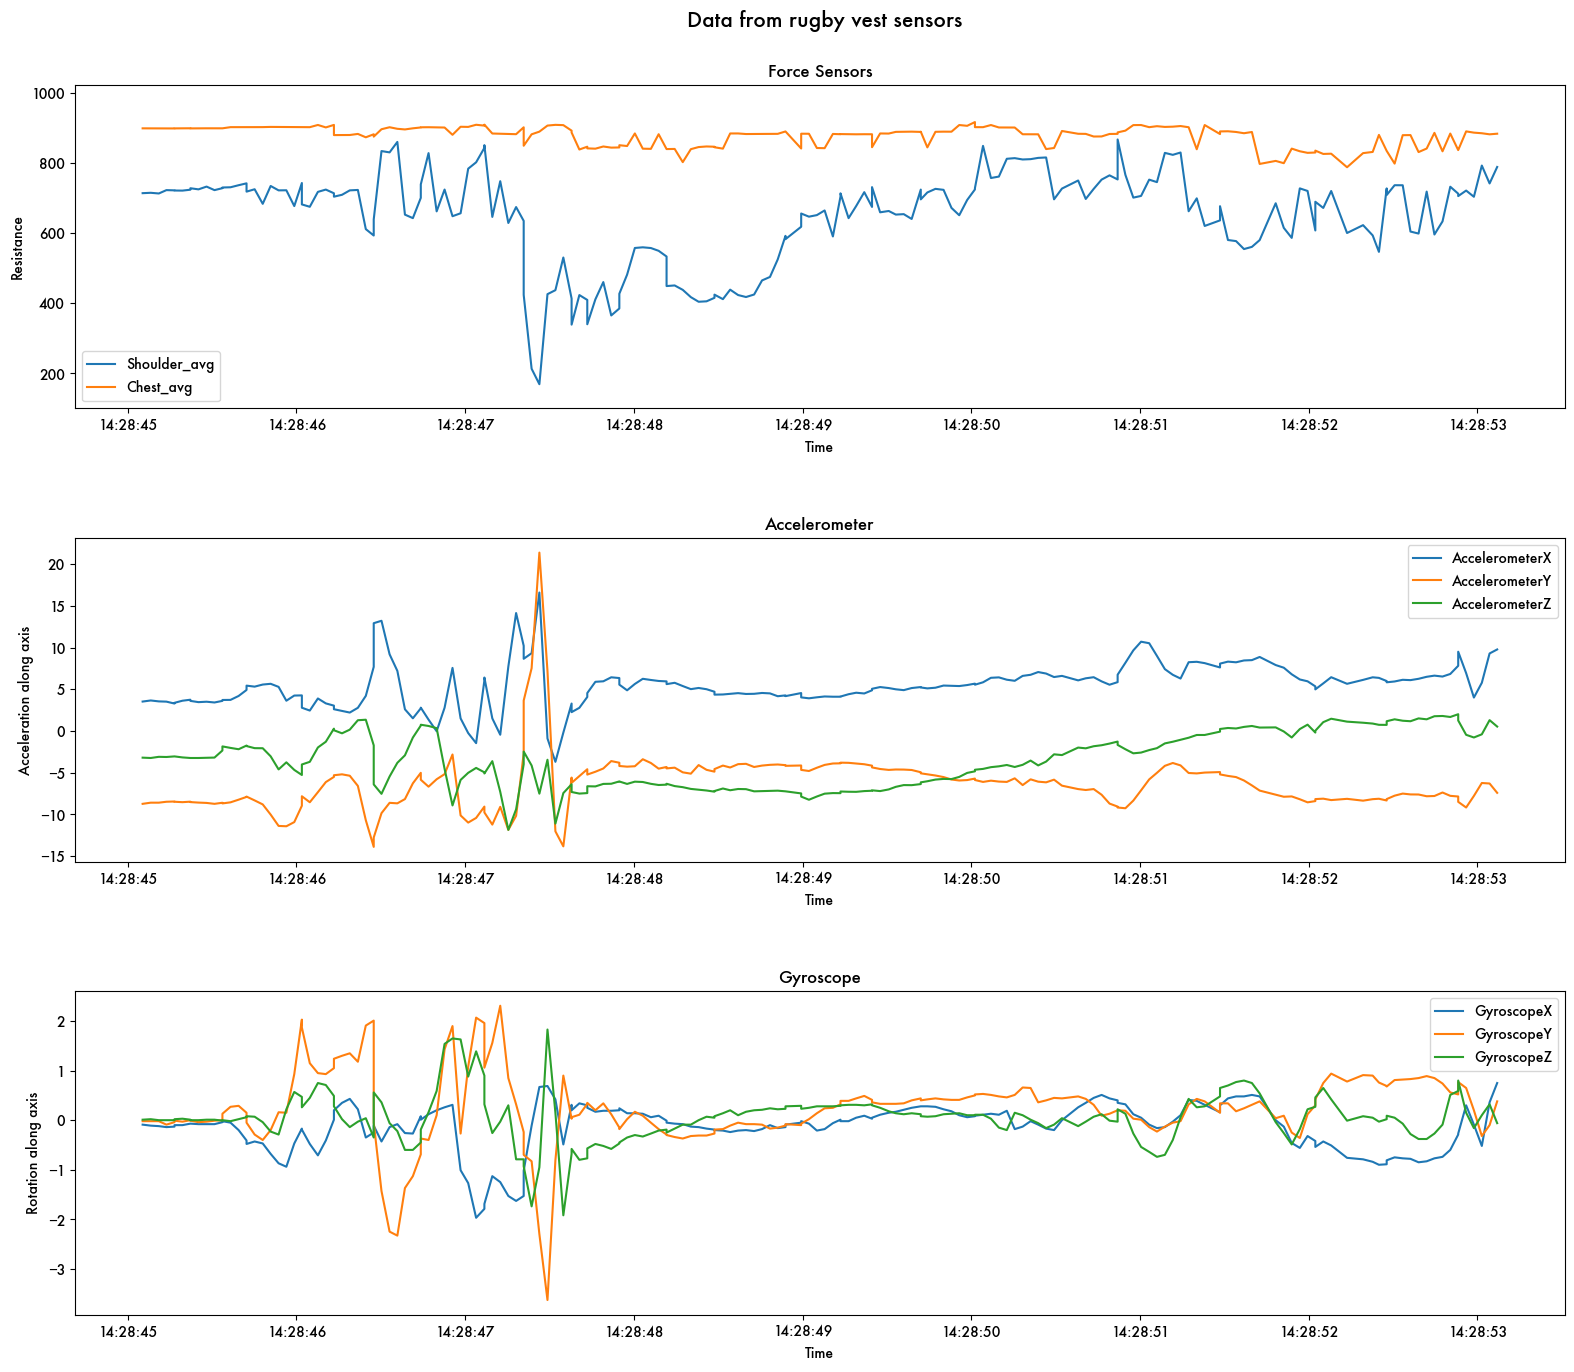

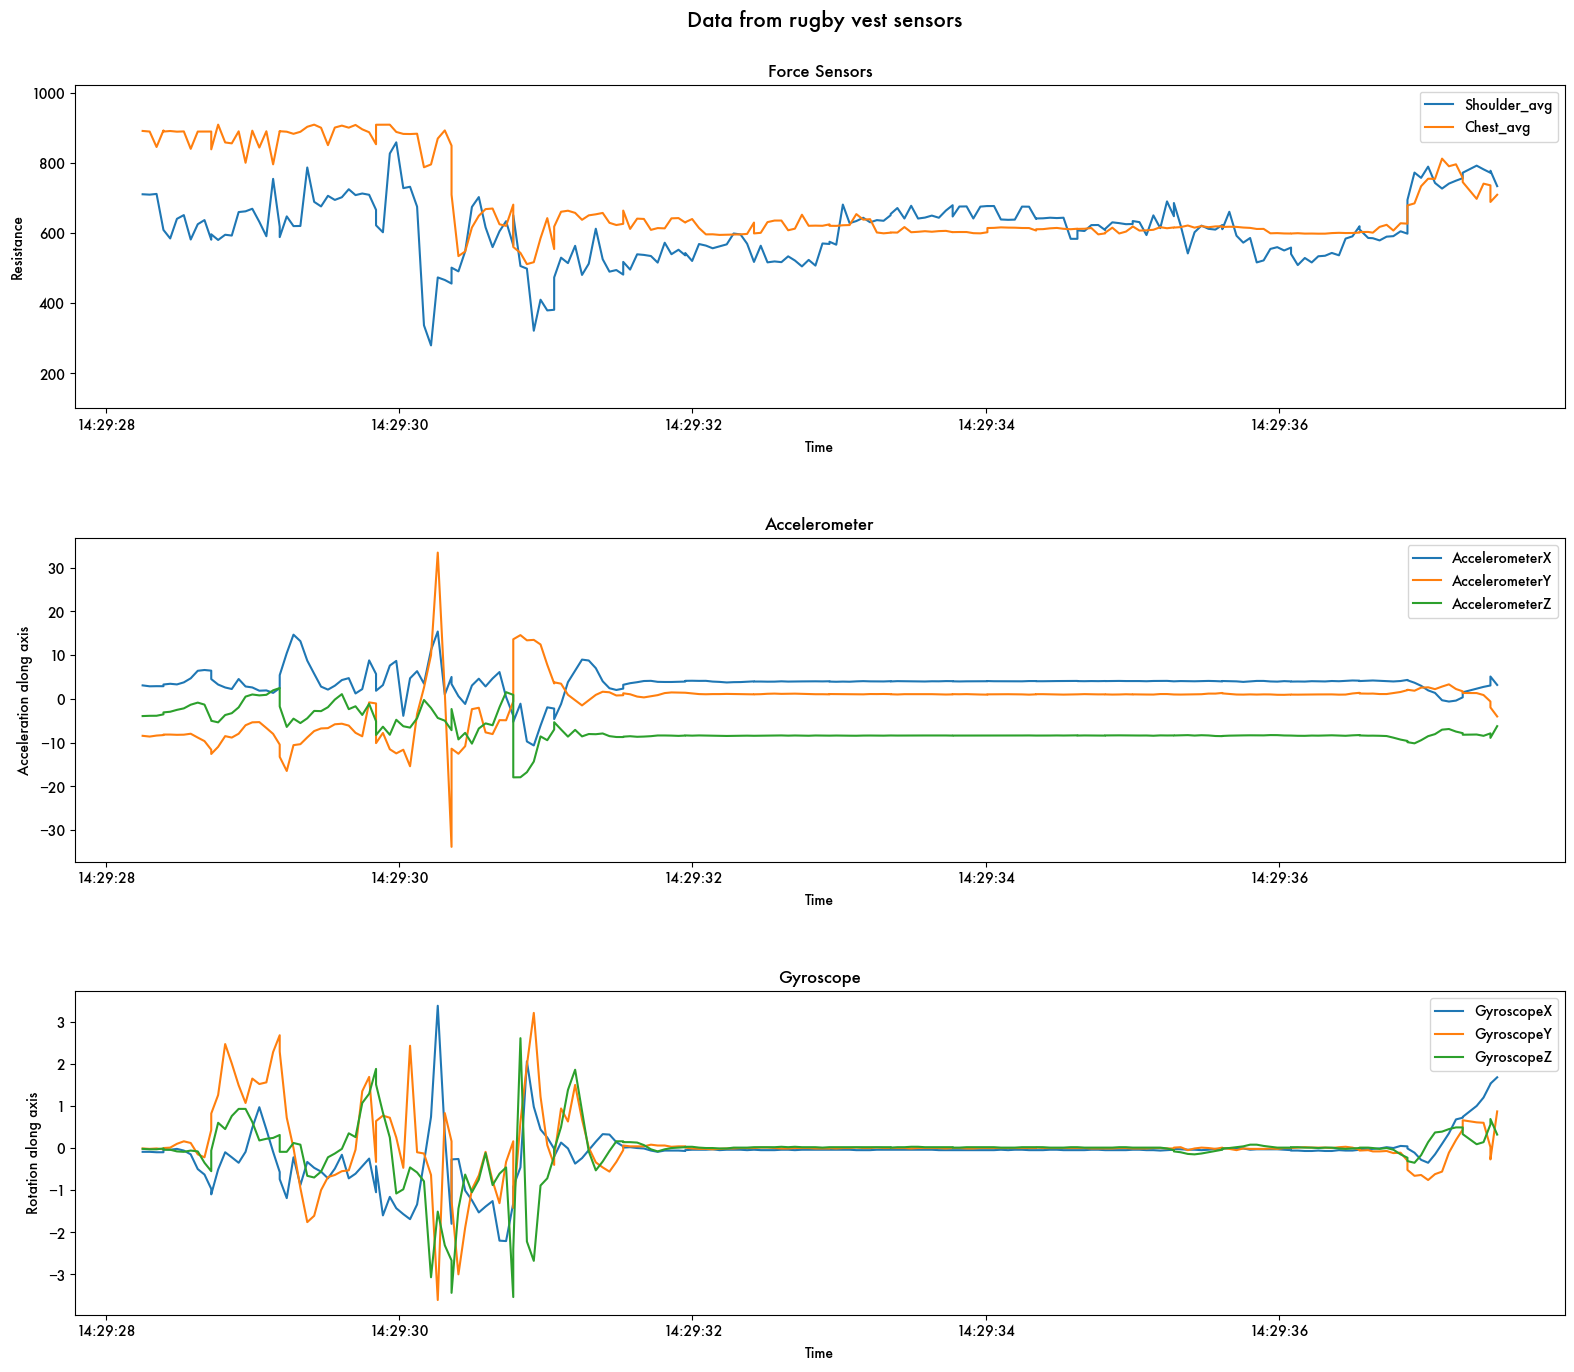

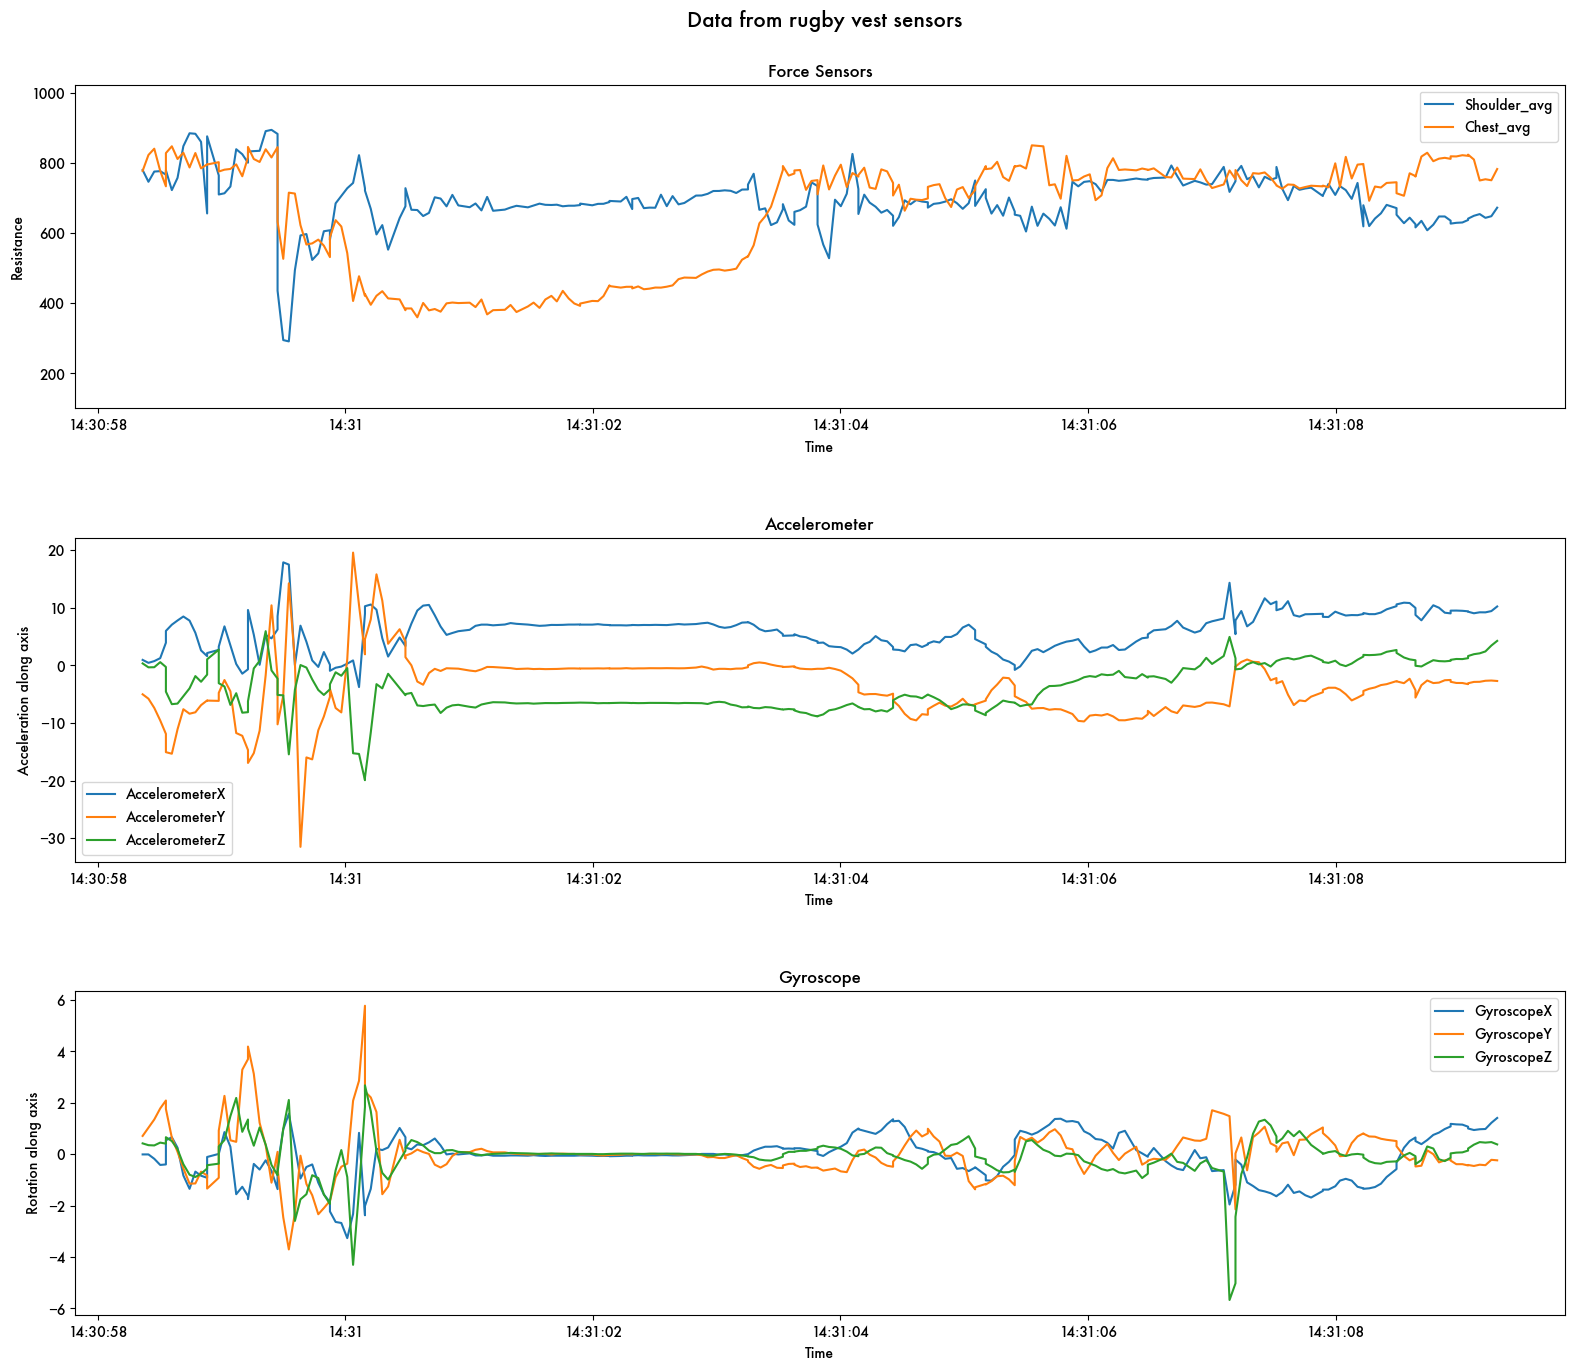

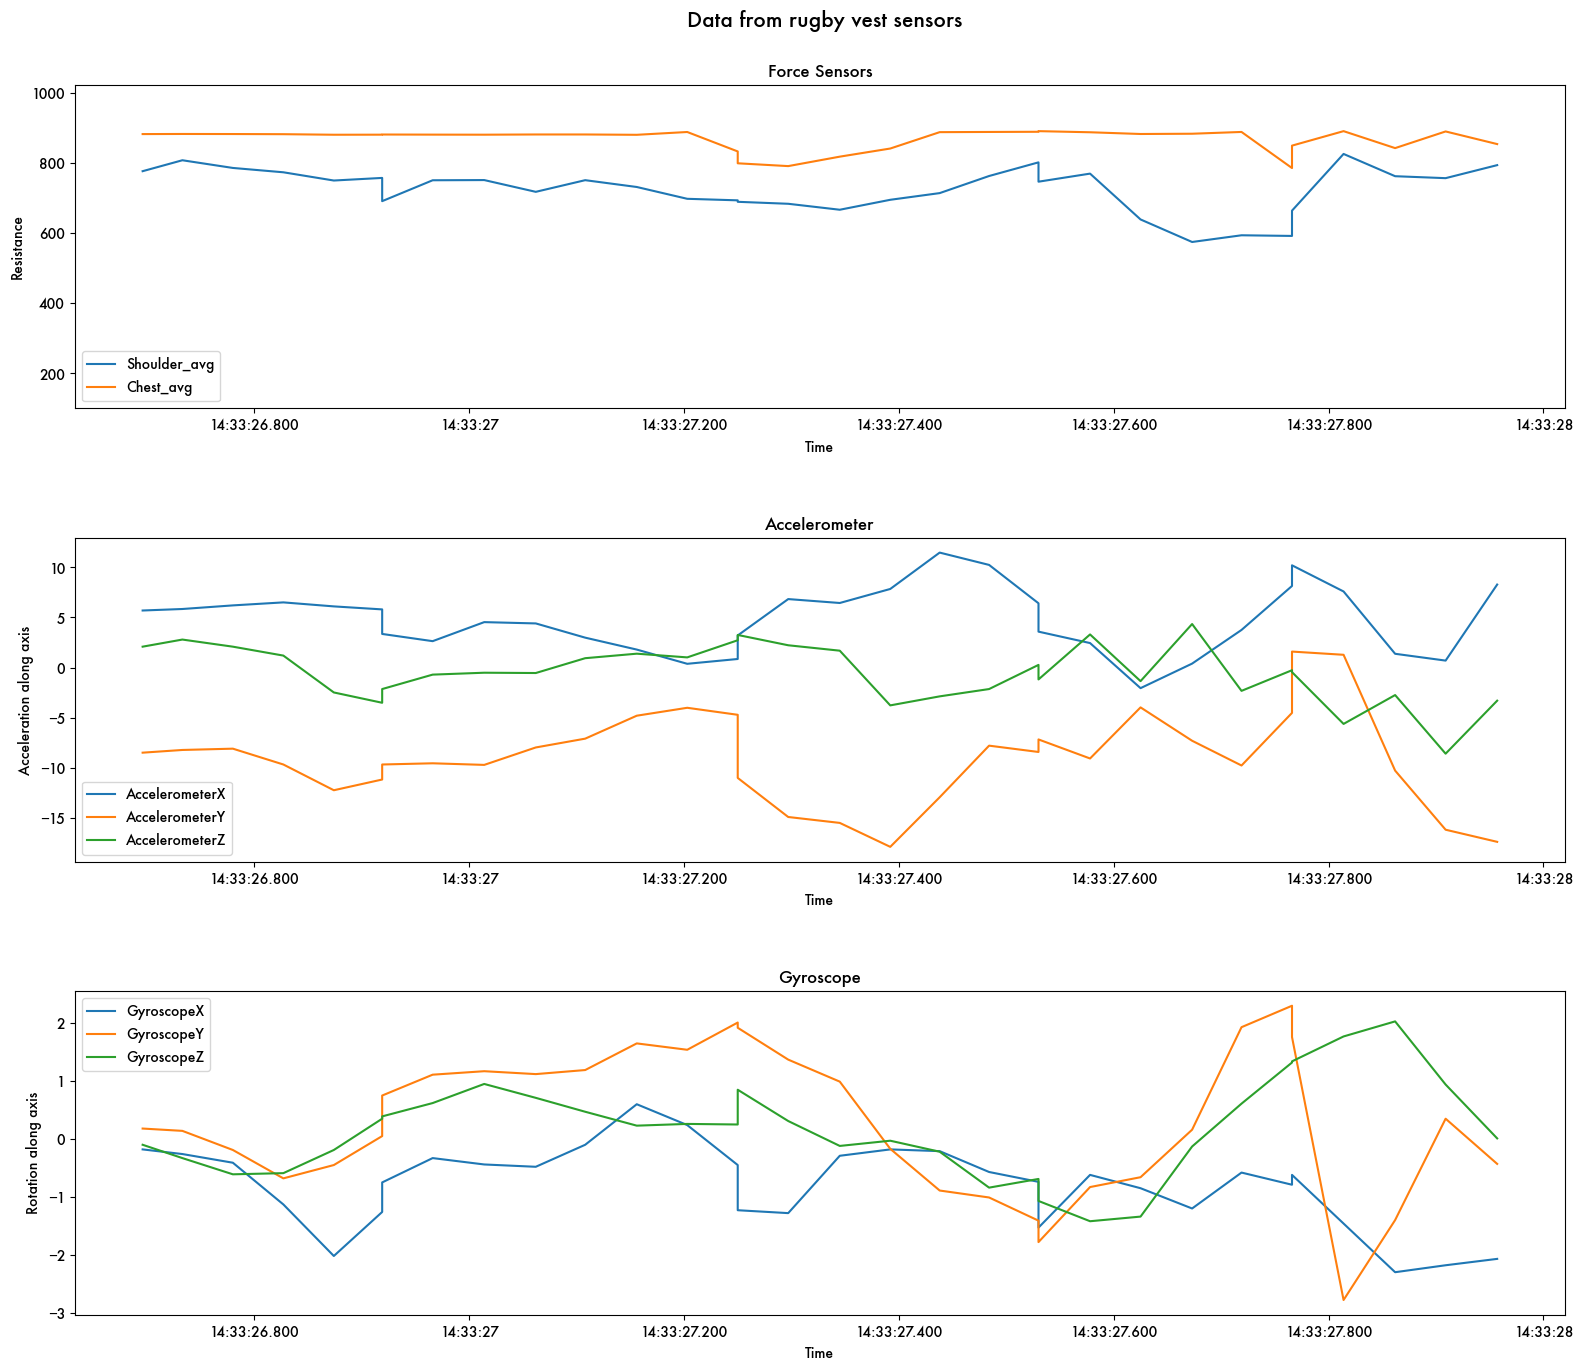

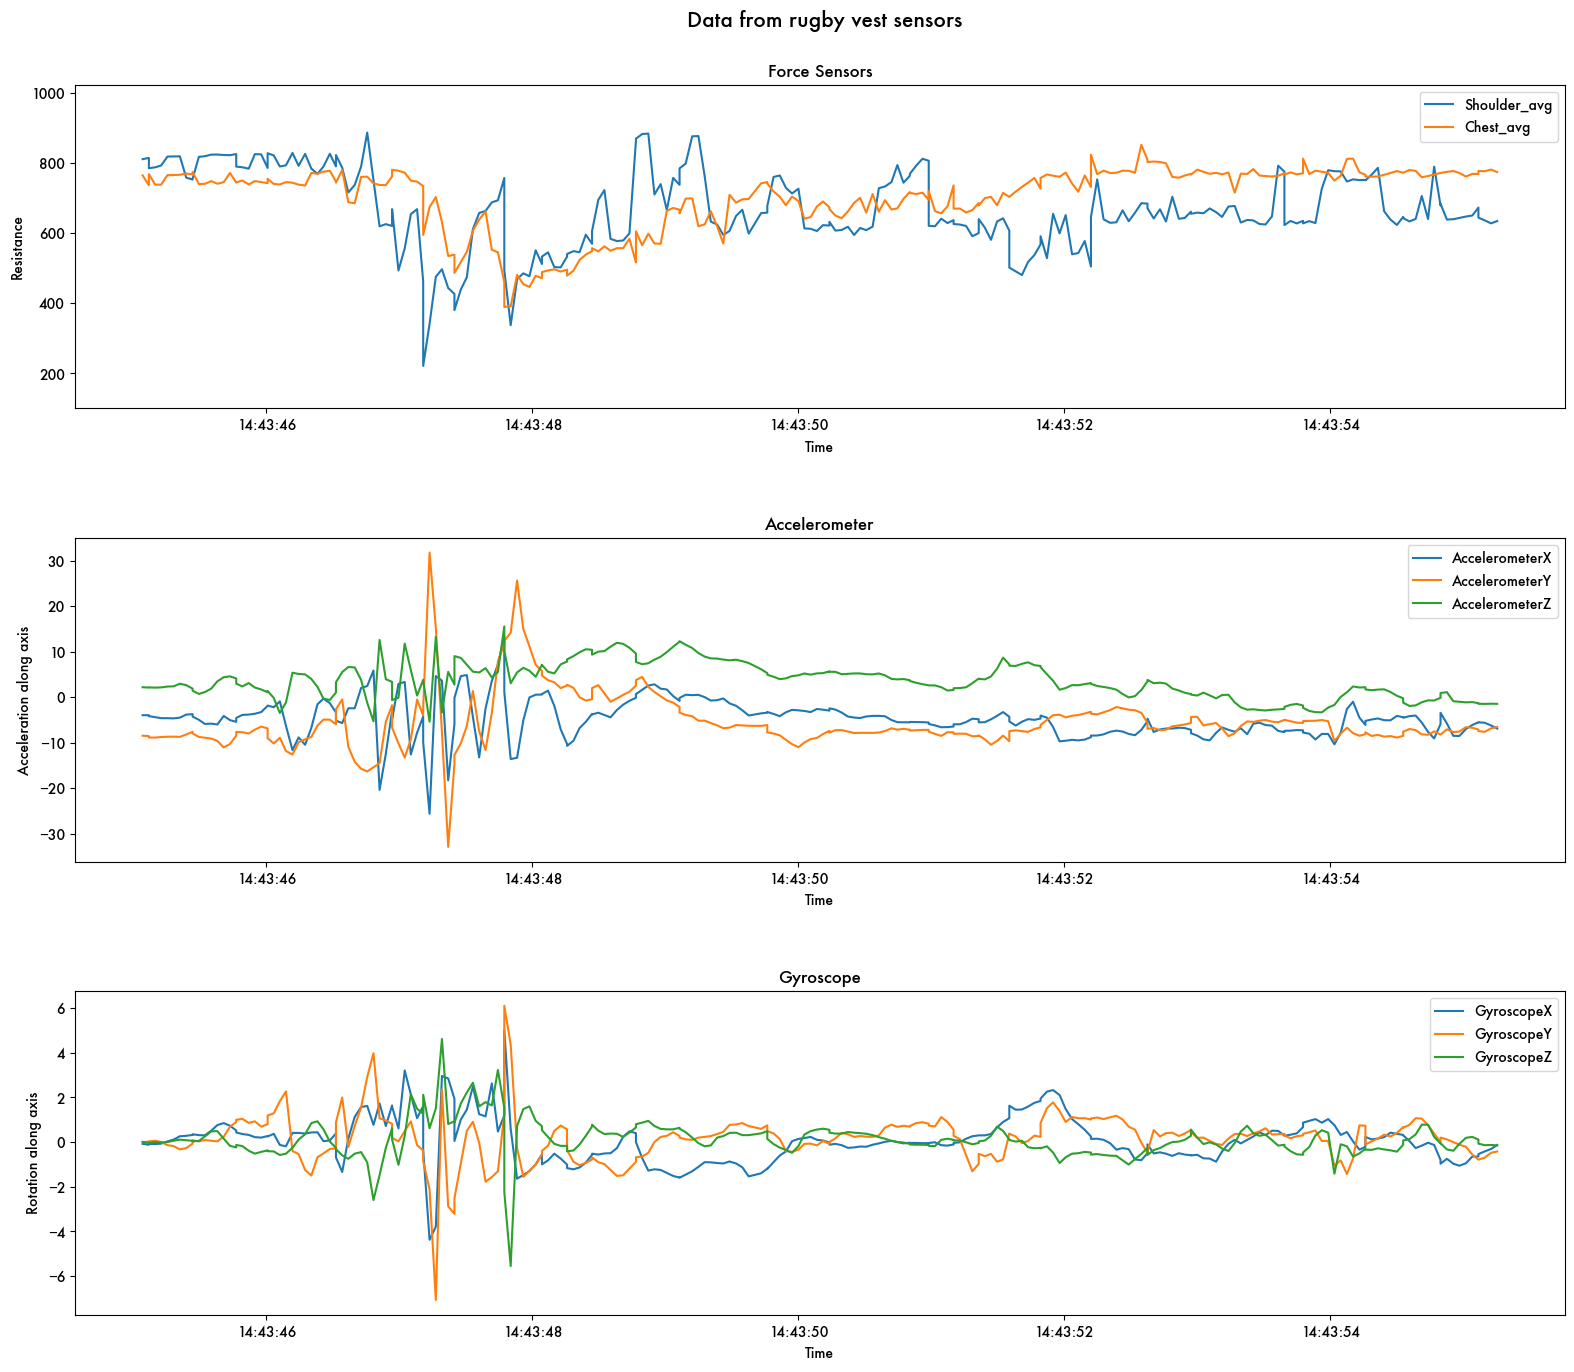

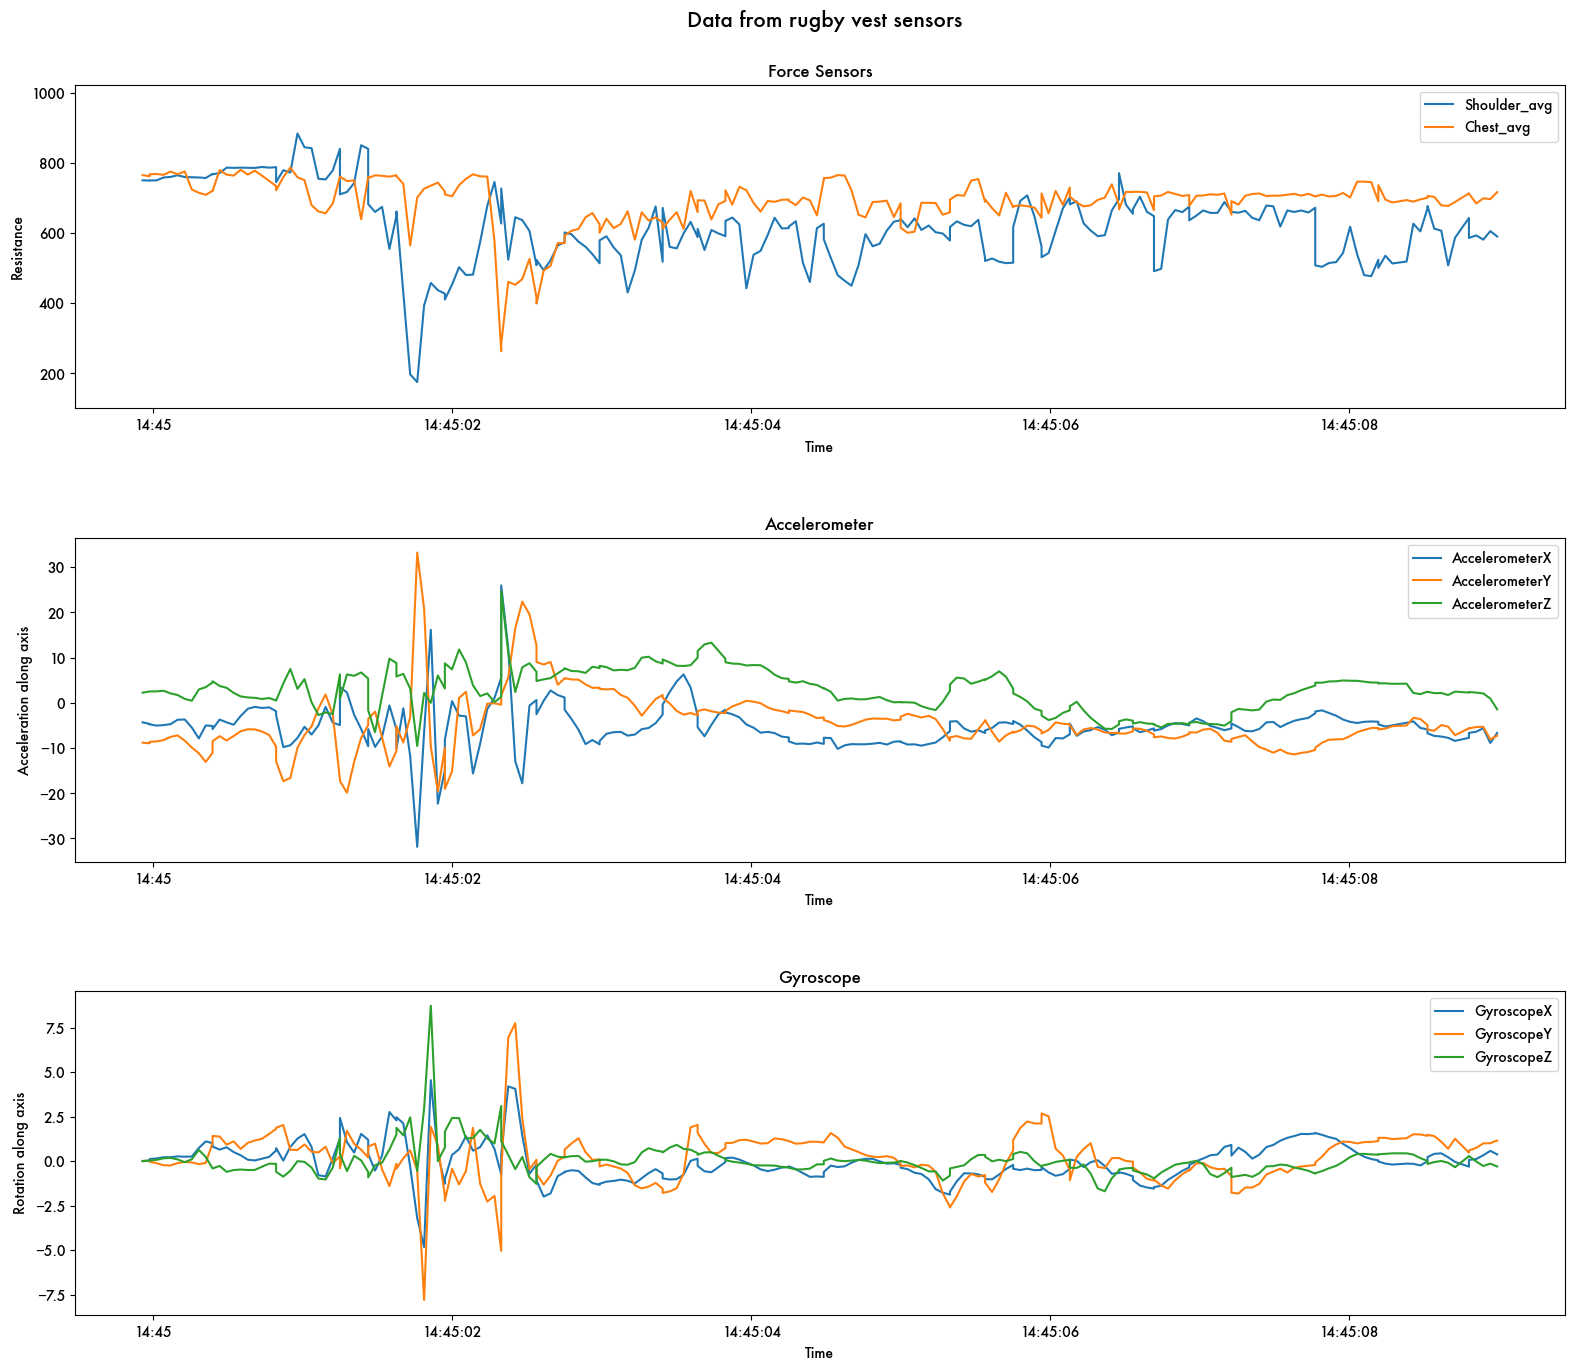

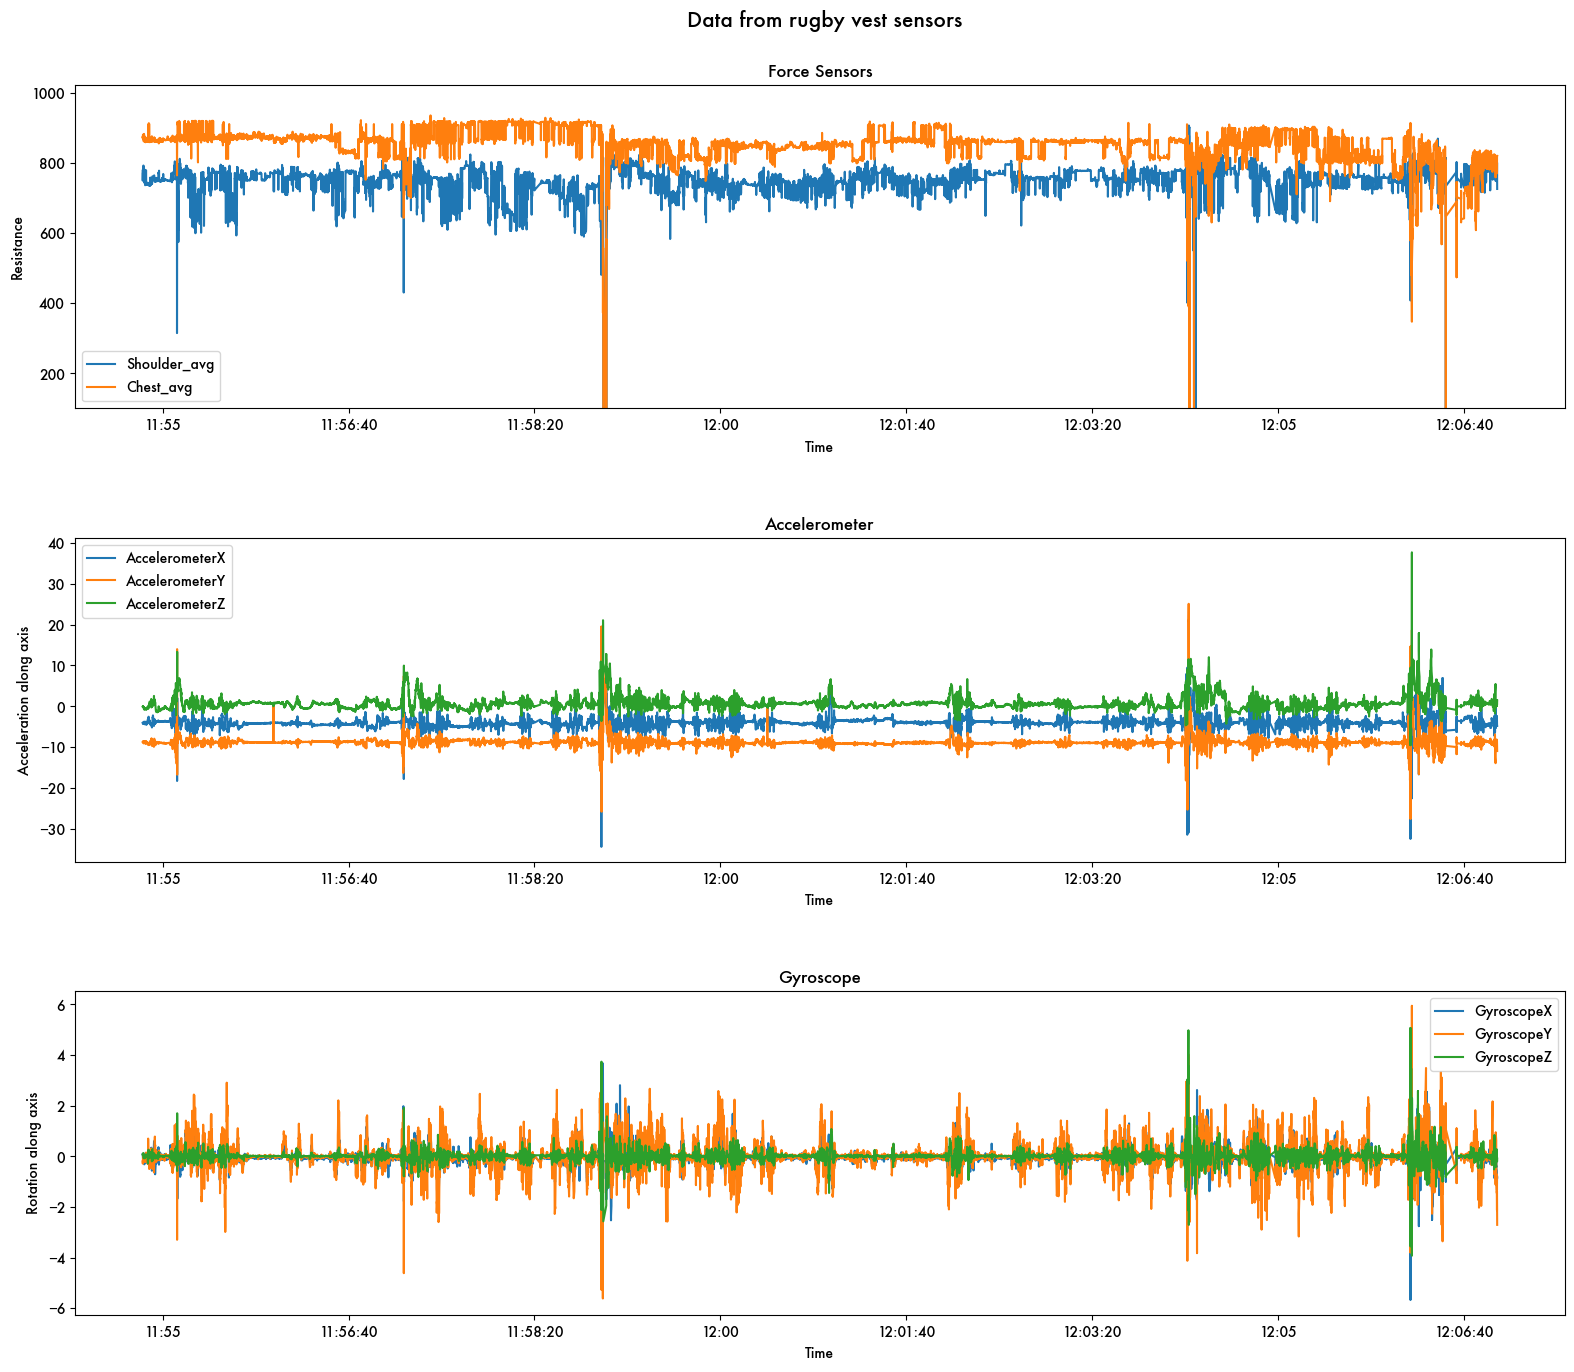

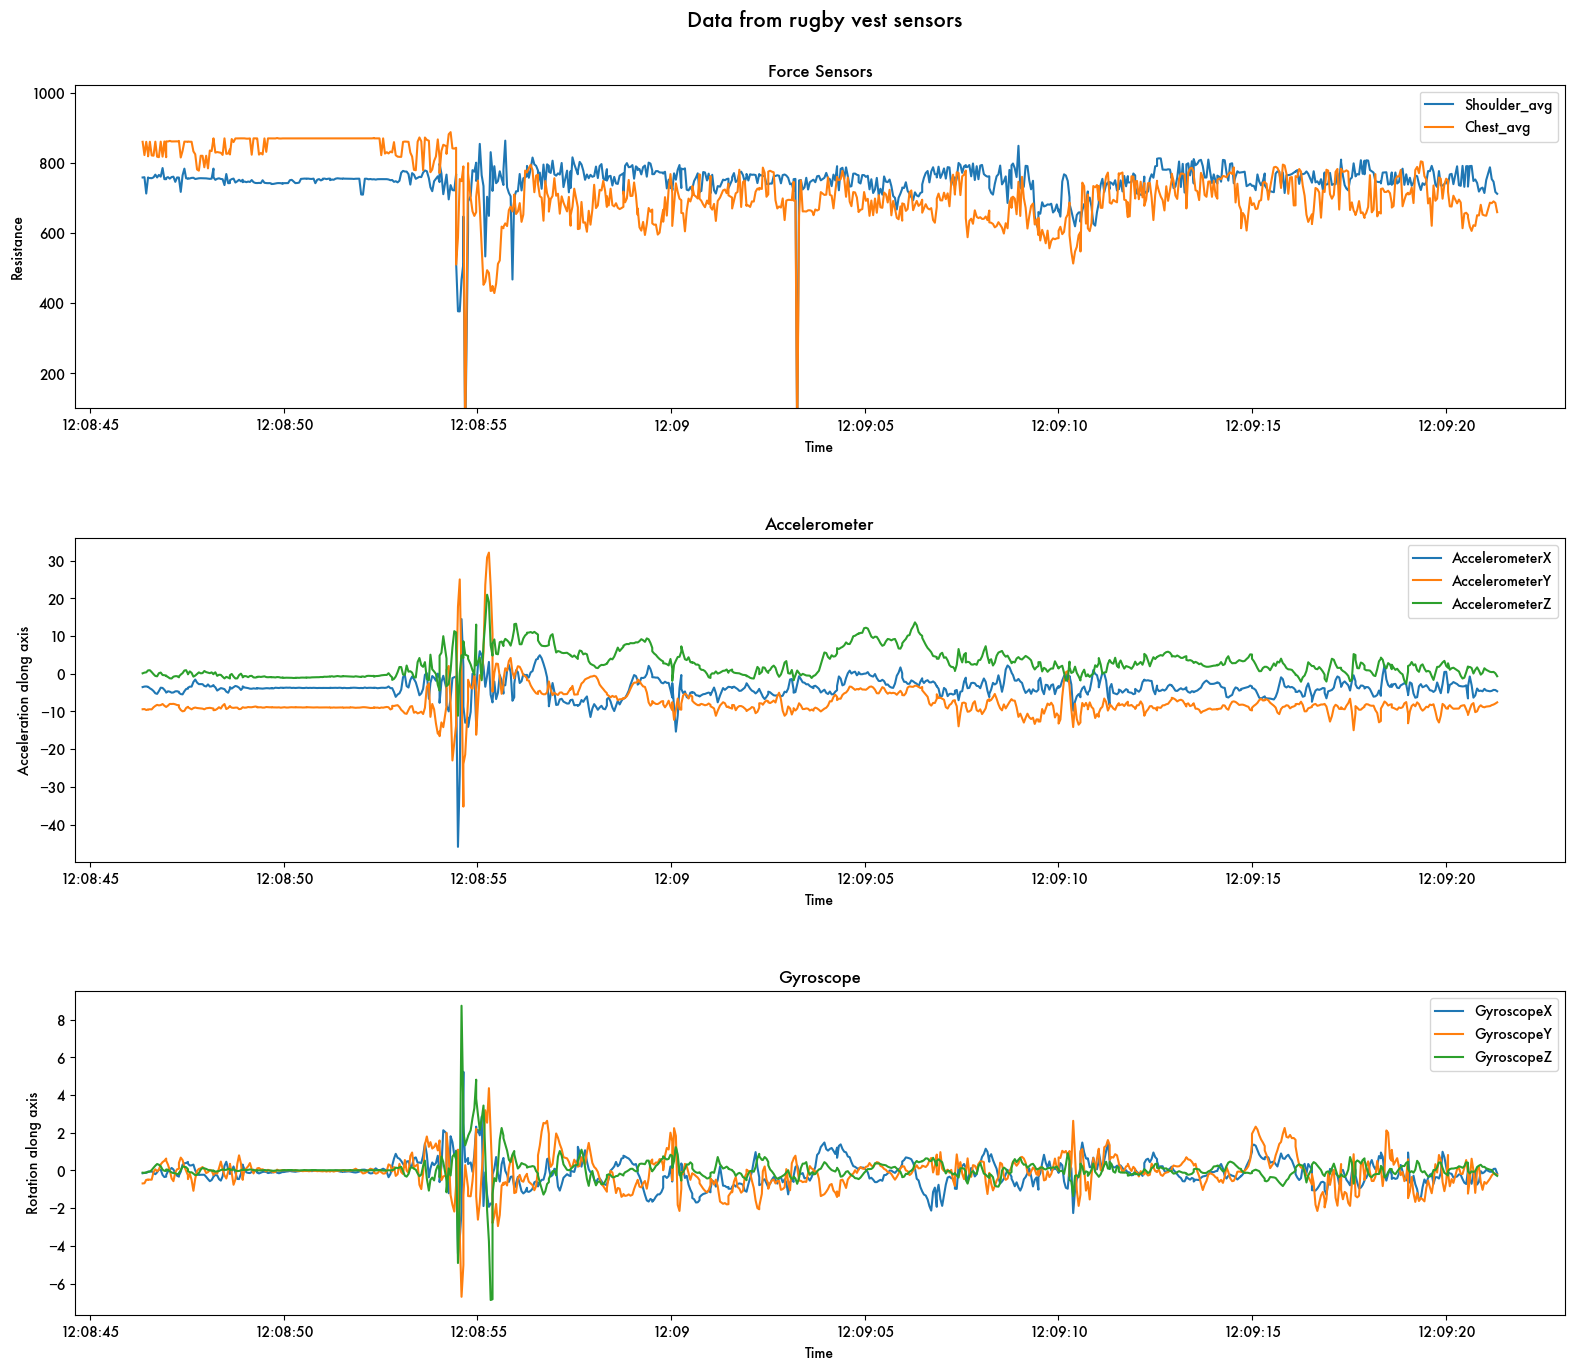

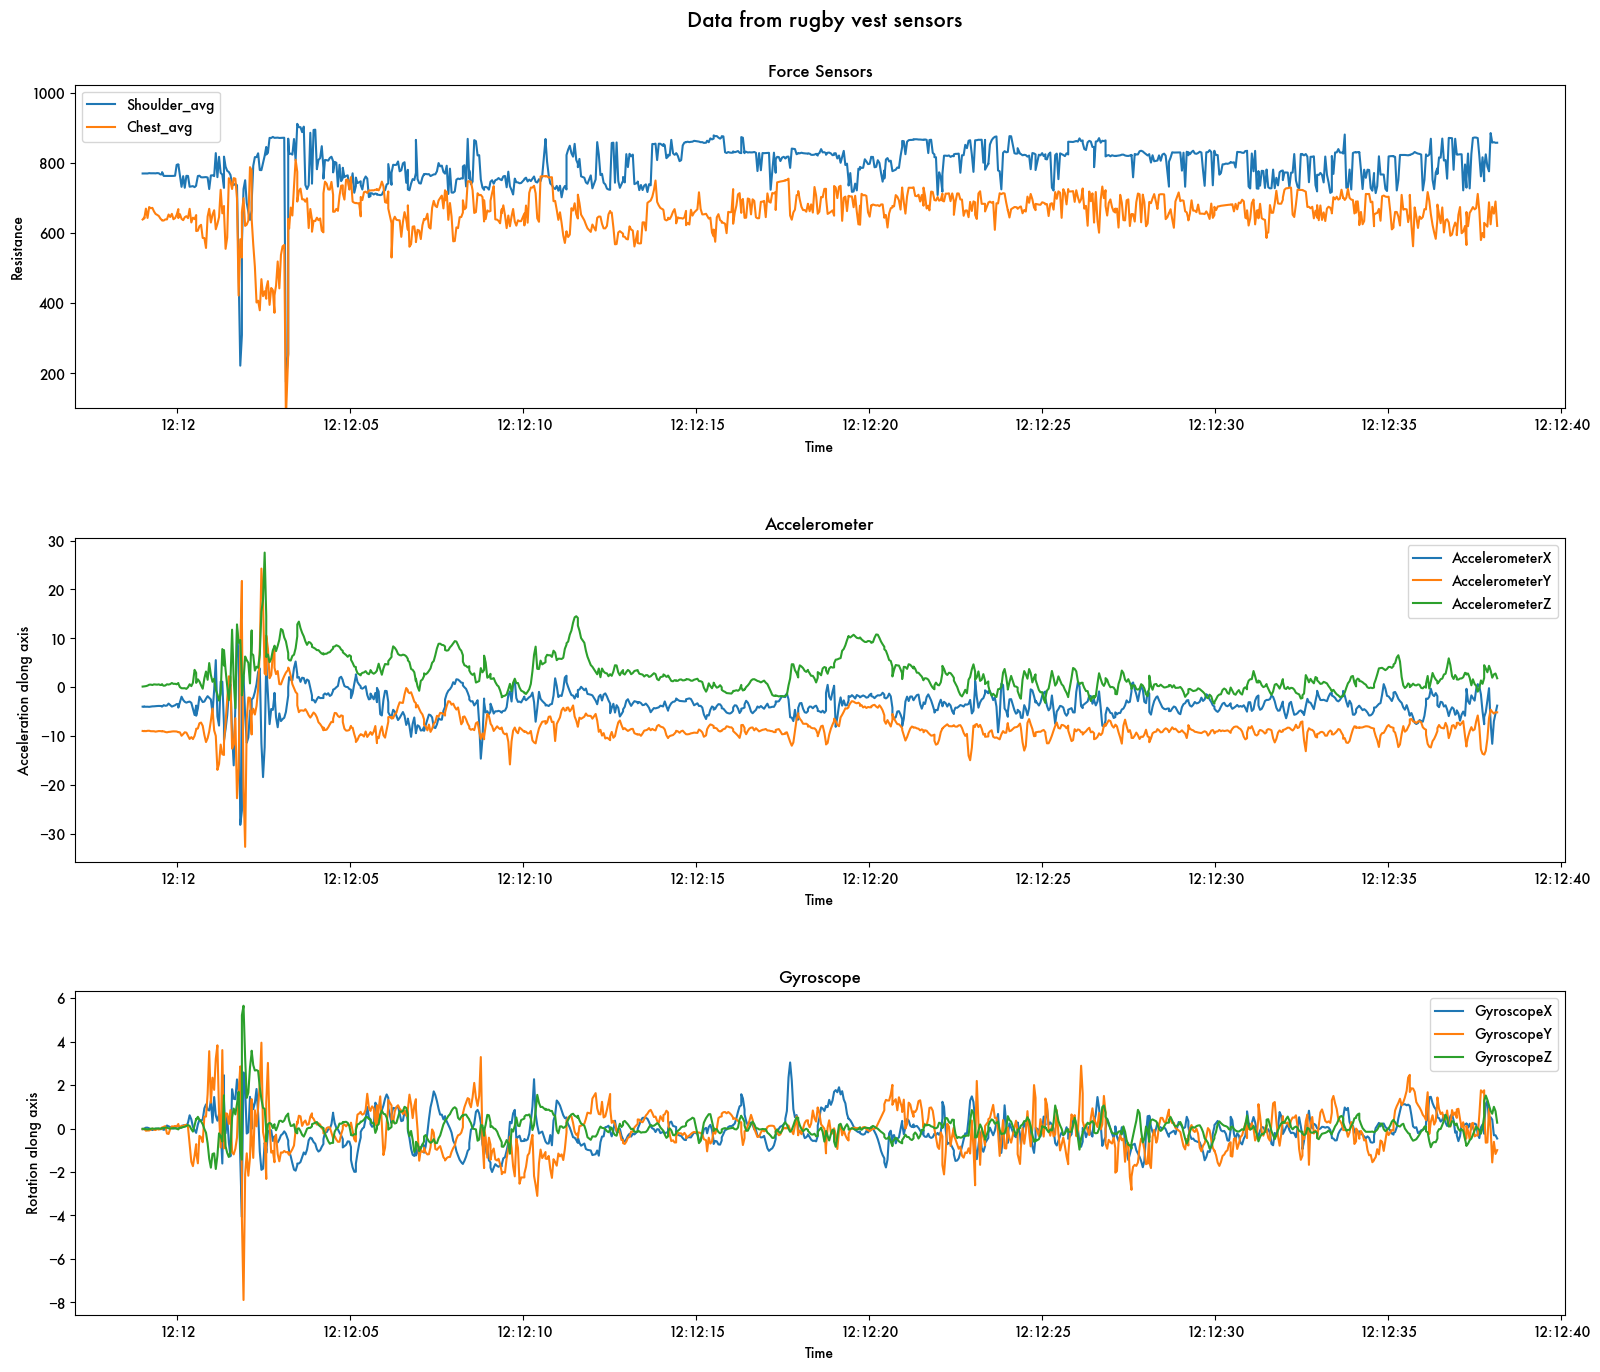

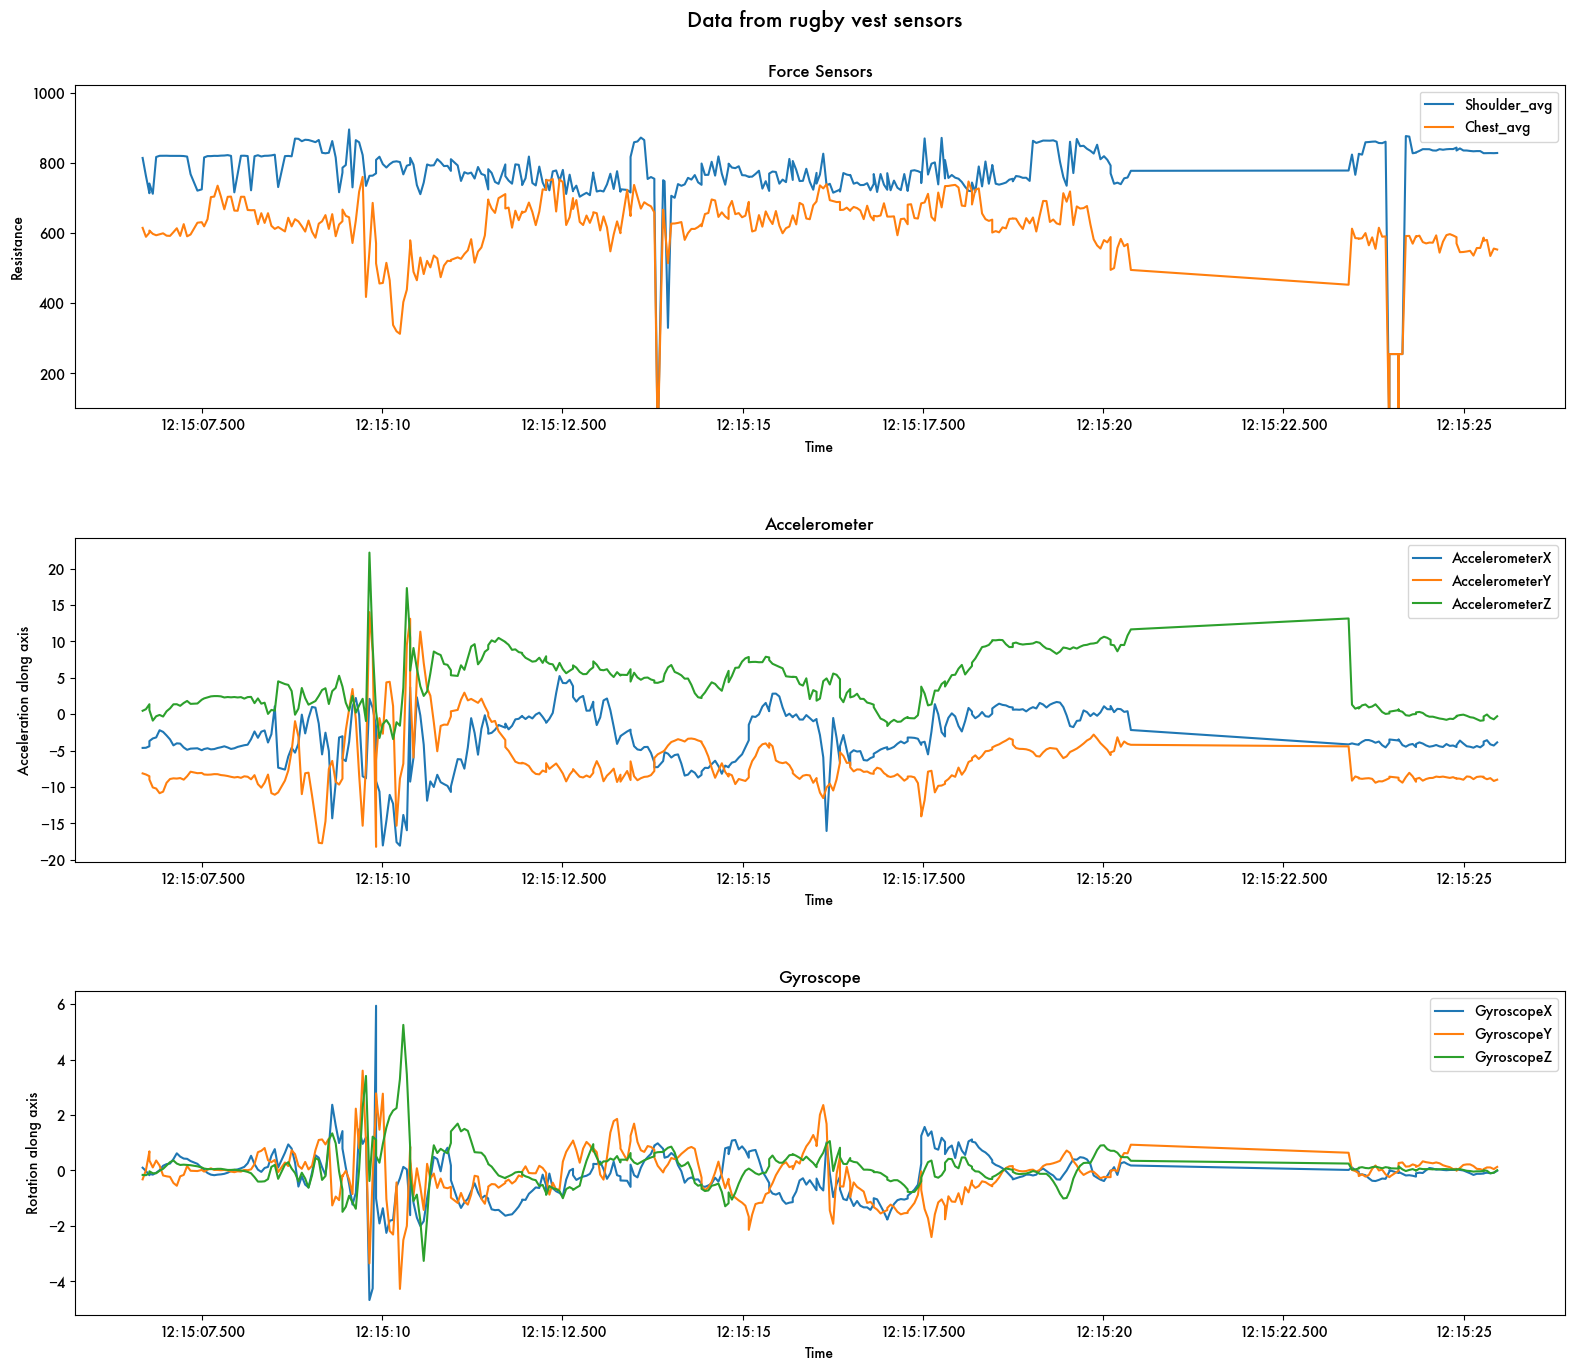

In [5]:
for i, data_table in enumerate(data_table_list_rugbyvest):
    
    # Calculate average of each sensor area for plotting graph and labelling
    data_table['Shoulder_avg'] = data_table.loc[:,[*shoulder1_colnames, *shoulder2_colnames]].mean(axis = 1)
    data_table['Chest_avg'] = data_table.loc[:,[*chest1_colnames, *chest2_colnames]].mean(axis = 1)

    # Define font family for the visulation
    plt.rcParams["font.family"] = "Futura"
    
    # Plot multiple graphs based on each type of sensors and time
    fig, axis = plt.subplots(figsize = (20, 15), nrows = 3, ncols = 1)
    plt.subplots_adjust(hspace = 0.4)
    fig.suptitle('Data from rugby vest sensors', fontsize = 15, fontweight = 800)
    fig.subplots_adjust(top = 0.93, right = 0.87)
    data_table.plot(x = 'Time', y = 'Shoulder_avg', ax = axis[0], kind = 'line', title = 'Force Sensors', ylim = (100, 1023), xlabel = 'Time', ylabel = 'Resistance')
    data_table.plot(x = 'Time', y = 'Chest_avg', ax = axis[0], kind = 'line', title = 'Force Sensors', ylim = (100, 1023), xlabel = 'Time', ylabel = 'Resistance')
    data_table.plot(x = 'Time', y = ['AccelerometerX','AccelerometerY','AccelerometerZ'], ax = axis[1], kind = 'line', title = 'Accelerometer', xlabel = 'Time', ylabel = 'Acceleration along axis')
    data_table.plot(x = 'Time', y = ['GyroscopeX','GyroscopeY','GyroscopeZ'], ax = axis[2], kind = 'line', title = 'Gyroscope', xlabel = 'Time', ylabel = 'Rotation along axis')
    plt.show()
    
    # Apply changes back to list
    data_table_list_rugbyvest[i] = data_table
    

Once the graph has been drawn, the thresholds are determined based on the peak of the graph. The data is then labelled based on those thresholds.

In [6]:
# Group the data in the same microseconds together to reduce the data complexity due to the sensor sensitivity (For labelling only)
def simplify_sensitive_data(input_table, input_column, output_column):
    
    simplify_window_size = impact_rows_avg
    min_values_list = []
    output_table = input_table.copy()
    
    for i in range(len(input_table)):
        
        # Select min value as the min value shows reflect the impact on sensors
        min_value = input_table.loc[i : i + simplify_window_size, input_column][input_table.loc[i : i + simplify_window_size, input_column] != 0].min()
        min_values_list.append(min_value)
        
    output_table[output_column] = min_values_list
        
    return output_table

# Combine activities to be single activity if they happened within less than 10 second after the previous one
def combine_activities(input_table, activity_name):
    
    output_table = input_table.copy()
    
    # Check if the variable is passed for impacts, consider both shoulder impacts and chest impacts
    if activity_name == 'Impact':
        related_col_list = ['Shoulder Impact', 'Chest Impact', activity_name]
        # Loop to check each impact area first and combine the close one, then loop the whole impact
        for related_col in related_col_list:
            i = 0
            while i < len(output_table) - 1:
                if ((output_table[related_col][i] == 1) and (output_table[related_col][i + 1] != 1)):
                    # Loop to find next impact in each impact area to compare time before combine
                    for j in range(i + 2, len(output_table)): 
                        if (output_table[related_col][j] == 1):
                            validating_time = output_table['Time_in_sec'][i]
                            found_time = output_table['Time_in_sec'][j]
                            diff_in_secs = calculate_duration(validating_time, found_time)
                            if diff_in_secs < contact_events_avg and related_col == activity_name:
                                output_table.loc[i:j, activity_name] = 1
                            elif diff_in_secs < contact_events_avg and related_col != activity_name:
                                output_table.loc[i:j, related_col] = 1
                                output_table.loc[i:j, activity_name] = 1
                            break
                    i = j
                else:
                    i += 1
                
    
    # Check if the variable is passed for falls only
    elif activity_name == 'Fall':
        i = 0
        while i < len(output_table) - 1:
            if ((output_table[activity_name][i] == 1) and (output_table[activity_name][i + 1] != 1)):
                for j in range(i + 2, len(output_table)):
                    if (output_table[activity_name][j] == 1):
                        validating_time = output_table['Time_in_sec'][i]
                        found_time = output_table['Time_in_sec'][j]
                        diff_in_secs = calculate_duration(validating_time, found_time)
                        if diff_in_secs < fall_events_avg:
                            output_table.loc[i:j, activity_name] = 1
                        break
                i = j
            else:
                i += 1
        output_table = remove_error_label(output_table, 'Fall') # Bend not fall

    return output_table

# Label impacted area whether there is any shoulder or chest impacts from falls or main impacts
# Head impact will be combined in the end as the data from mouthguard has been already processed by company's application
def label_activity(input_table):
    
    output_table = input_table.copy()
    output_table['Impact'] = 0 
    output_table['Fall'] = 0
    output_table['Shoulder Impact'] = 0
    output_table['Chest Impact'] = 0 
    
    # Label shoulder impact
    output_table.loc[(output_table['Shoulder_avg_simplify'] < shoulder_impact_threshold), ['Impact', 'Shoulder Impact']] = 1
    
    # Label chest impact
    output_table.loc[(output_table['Chest_avg_simplify'] < chest_impact_threshold), ['Impact', 'Chest Impact']] = 1
    
    # Label fall
    output_table['Magnitude'] = np.sqrt(output_table['AccelerometerX']**2 + output_table['AccelerometerY']**2 + output_table['AccelerometerZ']**2)
    output_table.loc[output_table['Magnitude'] > magnitude_fall_threshold, 'Fall'] = 1
     
    return output_table

def remove_error_label(input_table, related_col):
    
    output_table = input_table.copy()
    i = 0
    while i < len(output_table) - 1:
        if (output_table[related_col][i] == 1):
            # Loop to find the end of event to find the total time and unflag if shorter than threshold
            for j in range(i + 1, len(output_table)): 
                if (output_table[related_col][j] != 1):
                    validating_time = output_table['Time_in_sec'][i]
                    found_time = output_table['Time_in_sec'][j]
                    diff_in_secs = calculate_duration(validating_time, found_time)
                    if diff_in_secs < 0.1:
                        output_table.loc[i:j, related_col] = 0
                    break
            i = j
        else:
            i += 1
    
    return output_table

# Calculate time difference in seconds
def calculate_duration(start_time, end_time):
    
    duration_in_secs = end_time - start_time
    
    return duration_in_secs

# Split dataset into 3 datasets for training machine learning models and and evaluating models' performance
def split_dataset(input_table, column_list, set_name):

    # Calculate split points
    train_split_point = int(train_split_size * len(input_table))
    validation_split_point = train_split_point + (int((len(input_table) - train_split_point) / 2))
    
    # Split into 3 datasets based on proportion
    if set_name == 'train':
        splitted_data_table = input_table[column_list][:train_split_point]
    elif set_name == 'validation':
        splitted_data_table = input_table[column_list][train_split_point:validation_split_point]
    elif set_name == 'test':
        splitted_data_table = input_table[column_list][validation_split_point:]

    return splitted_data_table

# Split segment into fixed length with non-overlapping and padding in the last segment
def split_segment(input_table, window_size, is_y = False):
    
    segments = []
    start = 0
    end = window_size
    
    while start <= len(input_table):
        
        if end < len(input_table):
            segment = input_table.iloc[start:end]
        elif end == len(input_table):
            segment = input_table.iloc[start:]
        elif end > len(input_table):
            segment = input_table.iloc[start:]
            missing_rows_count = window_size - len(segment)
            if is_y == True:
                for i in range(missing_rows_count):
                    segment = segment.append(pd.Series([0]))
            else:
                padding_rows = pd.DataFrame([[0] * len(input_table.columns)] * missing_rows_count, columns=input_table.columns)
                segment = pd.concat([segment, padding_rows], ignore_index=True)
            
        if is_y == True:
            if segment.sum() > 0:
                segment = 1
            else:
                segment = 0
            
        segments.append(segment)
        start += window_size
        end += window_size
                
    return segments

# Prepare input shape for machine learning models
def reshape_input(input_list, is_y = False):
    
    output_list = [[],[],[]]
    object_model_1 = pd.DataFrame()
    object_model_2 = []
    object_model_3 = []
    
    for input_item in input_list:
        
        # Train row by row
        object_model_1 = pd.concat([object_model_1, input_item], ignore_index=True)
        # Train segment by segment
        object_model_2.extend(split_segment(input_item, 12, is_y))
        object_model_3.extend(split_segment(input_item, 24, is_y))
        
    output_list[0] = object_model_1.values.reshape(object_model_1.shape[0], 1, object_model_1.shape[1])
    output_list[1] = np.array(object_model_2)
    output_list[2] = np.array(object_model_3)
       
    return output_list
    
    

In [7]:
for i, data_table in enumerate(data_table_list_rugbyvest):
    
    # Find lowest average in window of rows to simplify sensor sensitivity
    data_table = simplify_sensitive_data(data_table, 'Shoulder_avg', 'Shoulder_avg_simplify')
    data_table = simplify_sensitive_data(data_table, 'Chest_avg', 'Chest_avg_simplify')
    
    # Convert time column to seconds for calculating duration or time difference
    data_table['Time_in_sec'] = data_table.apply(lambda x: (x['Time'].hour * 3600 + x['Time'].minute * 60 + x['Time'].second + x['Time'].microsecond / 1e6), axis=1)
    
    # Add labels (impact, fall, impacted area)
    data_table = label_activity(data_table)
    
    # Combine multiple impacts and falls in the same time range into single activity
    data_table = combine_activities(data_table, 'Impact')
    data_table = combine_activities(data_table, 'Fall')
    
    # Apply changes back to list
    data_table_list_rugbyvest[i] = data_table
    
    # Export data
    file_export = 'labelled_' + str(i + 1) + '.csv'
    data_table.to_csv(folder_path + folder_output + file_export, index = False)
    
    # Display the first 5 rows of each data table
    print('Data from:', file_list_rugbyvest[i])
    print('Total table rows:', data_table.shape[0])
    print('Exported as:', file_export)
    display(data_table[:5])
    

Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test1.txt
Total table rows: 192
Exported as: labelled_1.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Shoulder_avg,Chest_avg,Shoulder_avg_simplify,Chest_avg_simplify,Time_in_sec,Impact,Fall,Shoulder Impact,Chest Impact,Magnitude
0,14:28:45.088000,909,946,200,777,907,892,956,892,908,...,713.7500,898.6250,712.8750,898.1875,52125.088,0,0,0,0,9.962781
1,14:28:45.136000,909,946,198,775,907,893,956,883,914,...,714.8125,898.5000,712.8750,898.1875,52125.136,0,0,0,0,9.900359
2,14:28:45.184000,909,946,197,777,907,894,956,891,908,...,712.8750,898.1875,712.8750,898.1875,52125.184,0,0,0,0,9.815080
3,14:28:45.229000,909,946,247,787,907,894,956,892,913,...,722.4375,898.4375,721.0625,898.3125,52125.229,0,0,0,0,9.714268
4,14:28:45.277000,909,946,244,786,907,894,956,892,911,...,721.8125,898.3125,721.0625,898.3125,52125.277,0,0,0,0,9.584514


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test2.txt
Total table rows: 222
Exported as: labelled_2.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Shoulder_avg,Chest_avg,Shoulder_avg_simplify,Chest_avg_simplify,Time_in_sec,Impact,Fall,Shoulder Impact,Chest Impact,Magnitude
0,14:29:28.250000,833,896,175,763,906,895,965,883,908,...,710.6250,891.1875,584.625,845.4375,52168.250,0,0,0,0,9.827594
1,14:29:28.298000,828,891,171,761,906,896,964,882,909,...,709.5625,889.4375,584.625,845.4375,52168.298,0,0,0,0,9.887780
2,14:29:28.345000,830,890,177,762,906,896,964,882,910,...,711.6250,845.4375,581.625,840.1875,52168.345,0,0,0,0,9.692621
3,14:29:28.392000,840,890,181,763,904,895,964,883,222,...,610.1250,892.6875,581.625,840.1875,52168.392,0,0,0,0,9.469884
4,14:29:28.392000,907,894,129,753,904,896,964,883,236,...,608.9375,889.4375,581.625,840.1875,52168.392,0,0,0,0,9.333665


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/20230804Test3.txt
Total table rows: 249
Exported as: labelled_3.csv


...

,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Shoulder_avg,Chest_avg,Shoulder_avg_simplify,Chest_avg_simplify,Time_in_sec,Impact,Fall,Shoulder Impact,Chest Impact,Magnitude
0,12:08:46.361000,902,875,901,874,901,708,901,874,420,...,758.5000,860.2500,712.7500,818.875,43726.361,0,0,0,0,10.054442
1,12:08:46.408000,902,875,901,874,901,708,901,874,422,...,759.2500,822.3750,712.7500,818.875,43726.408,0,0,0,0,9.972307
2,12:08:46.454000,902,875,900,880,901,114,901,874,301,...,712.7500,860.1875,712.7500,818.875,43726.454,0,0,0,0,10.190481
3,12:08:46.501000,902,875,901,874,902,708,901,874,420,...,758.5625,824.2500,756.4375,817.750,43726.501,0,0,0,0,10.174242
4,12:08:46.501000,902,875,901,874,901,706,901,874,417,...,757.2500,818.8750,756.4375,816.375,43726.501,0,0,0,0,10.124915


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/TestFrame03.txt
Total table rows: 922
Exported as: labelled_9.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Shoulder_avg,Chest_avg,Shoulder_avg_simplify,Chest_avg_simplify,Time_in_sec,Impact,Fall,Shoulder Impact,Chest Impact,Magnitude
0,12:11:58.992000,907,882,903,878,900,879,905,878,411,...,769.8750,638.6250,769.875,638.6250,43918.992,0,0,0,0,9.795907
1,12:11:59.040000,907,882,903,878,900,879,905,878,411,...,770.0000,644.3125,769.875,641.5625,43919.040,0,0,0,0,9.825788
2,12:11:59.040000,907,882,903,877,900,879,905,878,411,...,770.0625,641.5625,769.875,641.5625,43919.040,0,0,0,0,9.787385
3,12:11:59.087000,907,882,903,878,900,879,905,878,411,...,769.9375,669.6250,769.875,643.1875,43919.087,0,0,0,0,9.842180
4,12:11:59.134000,907,882,903,884,900,879,905,878,411,...,769.8750,643.1875,769.875,643.1875,43919.134,0,0,0,0,9.776958


Data from: /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/input files/rugby_vest/training files/TestFrame04.txt
Total table rows: 369
Exported as: labelled_10.csv


,Time,Shoulder1,Shoulder2,Shoulder3,Shoulder4,Shoulder5,Shoulder6,Shoulder7,Shoulder8,Shoulder9,...,Shoulder_avg,Chest_avg,Shoulder_avg_simplify,Chest_avg_simplify,Time_in_sec,Impact,Fall,Shoulder Impact,Chest Impact,Magnitude
0,12:15:06.678000,906,881,904,877,902,880,906,880,953,...,814.1875,614.8125,712.0,589.3750,44106.678,0,0,0,0,9.380874
1,12:15:06.724000,907,881,904,877,900,880,906,880,411,...,762.7500,589.3750,712.0,589.3750,44106.724,0,0,0,0,9.514773
2,12:15:06.772000,907,881,904,877,901,880,906,884,141,...,713.6250,601.0625,712.0,592.5625,44106.772,0,0,0,0,9.698381
3,12:15:06.772000,907,881,904,878,901,880,906,881,102,...,741.2500,607.1250,712.0,591.9375,44106.772,0,0,0,0,9.728515
4,12:15:06.819000,907,880,904,881,901,880,906,880,134,...,712.0000,597.6875,712.0,591.9375,44106.819,0,0,0,0,10.646718


Then, the simplified data was graphed again. In addition, the computed magnitude from the accelerometer is also shown as per below.

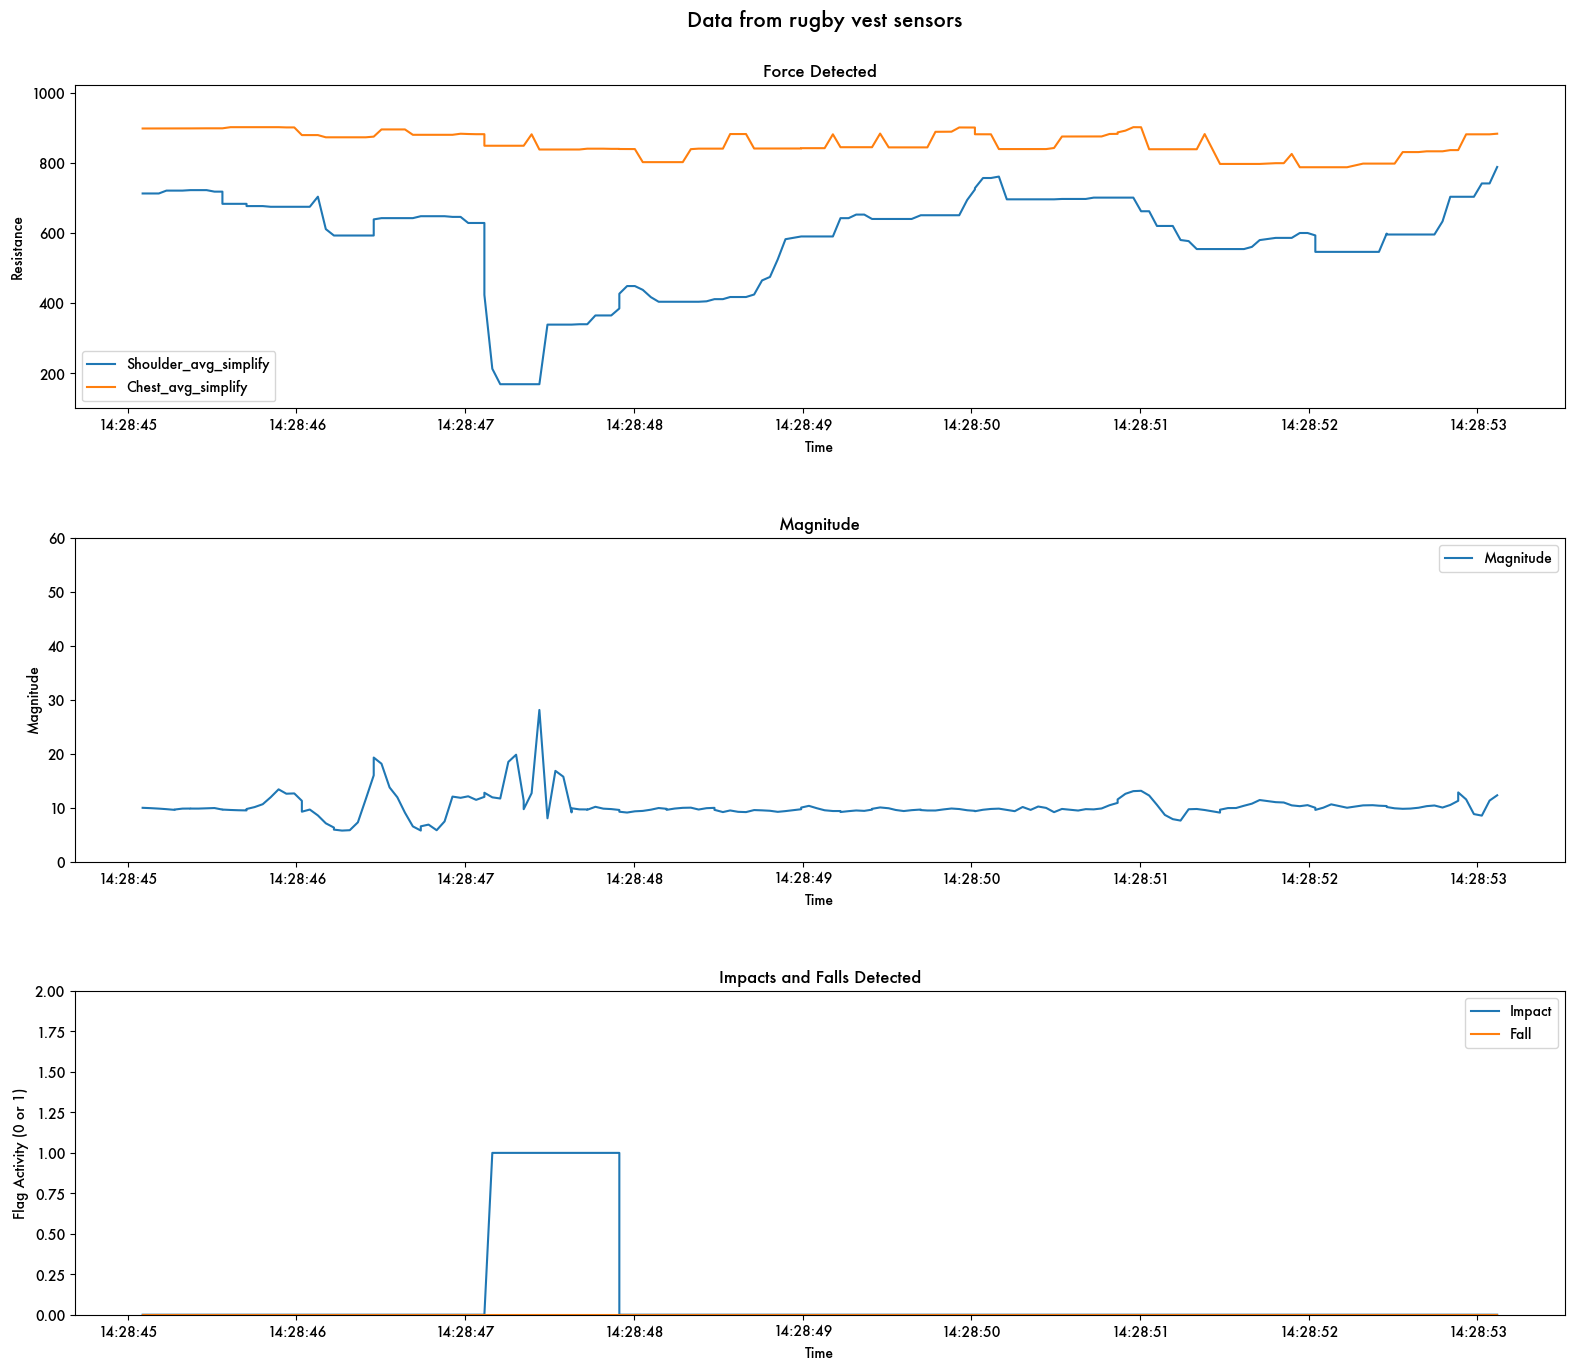

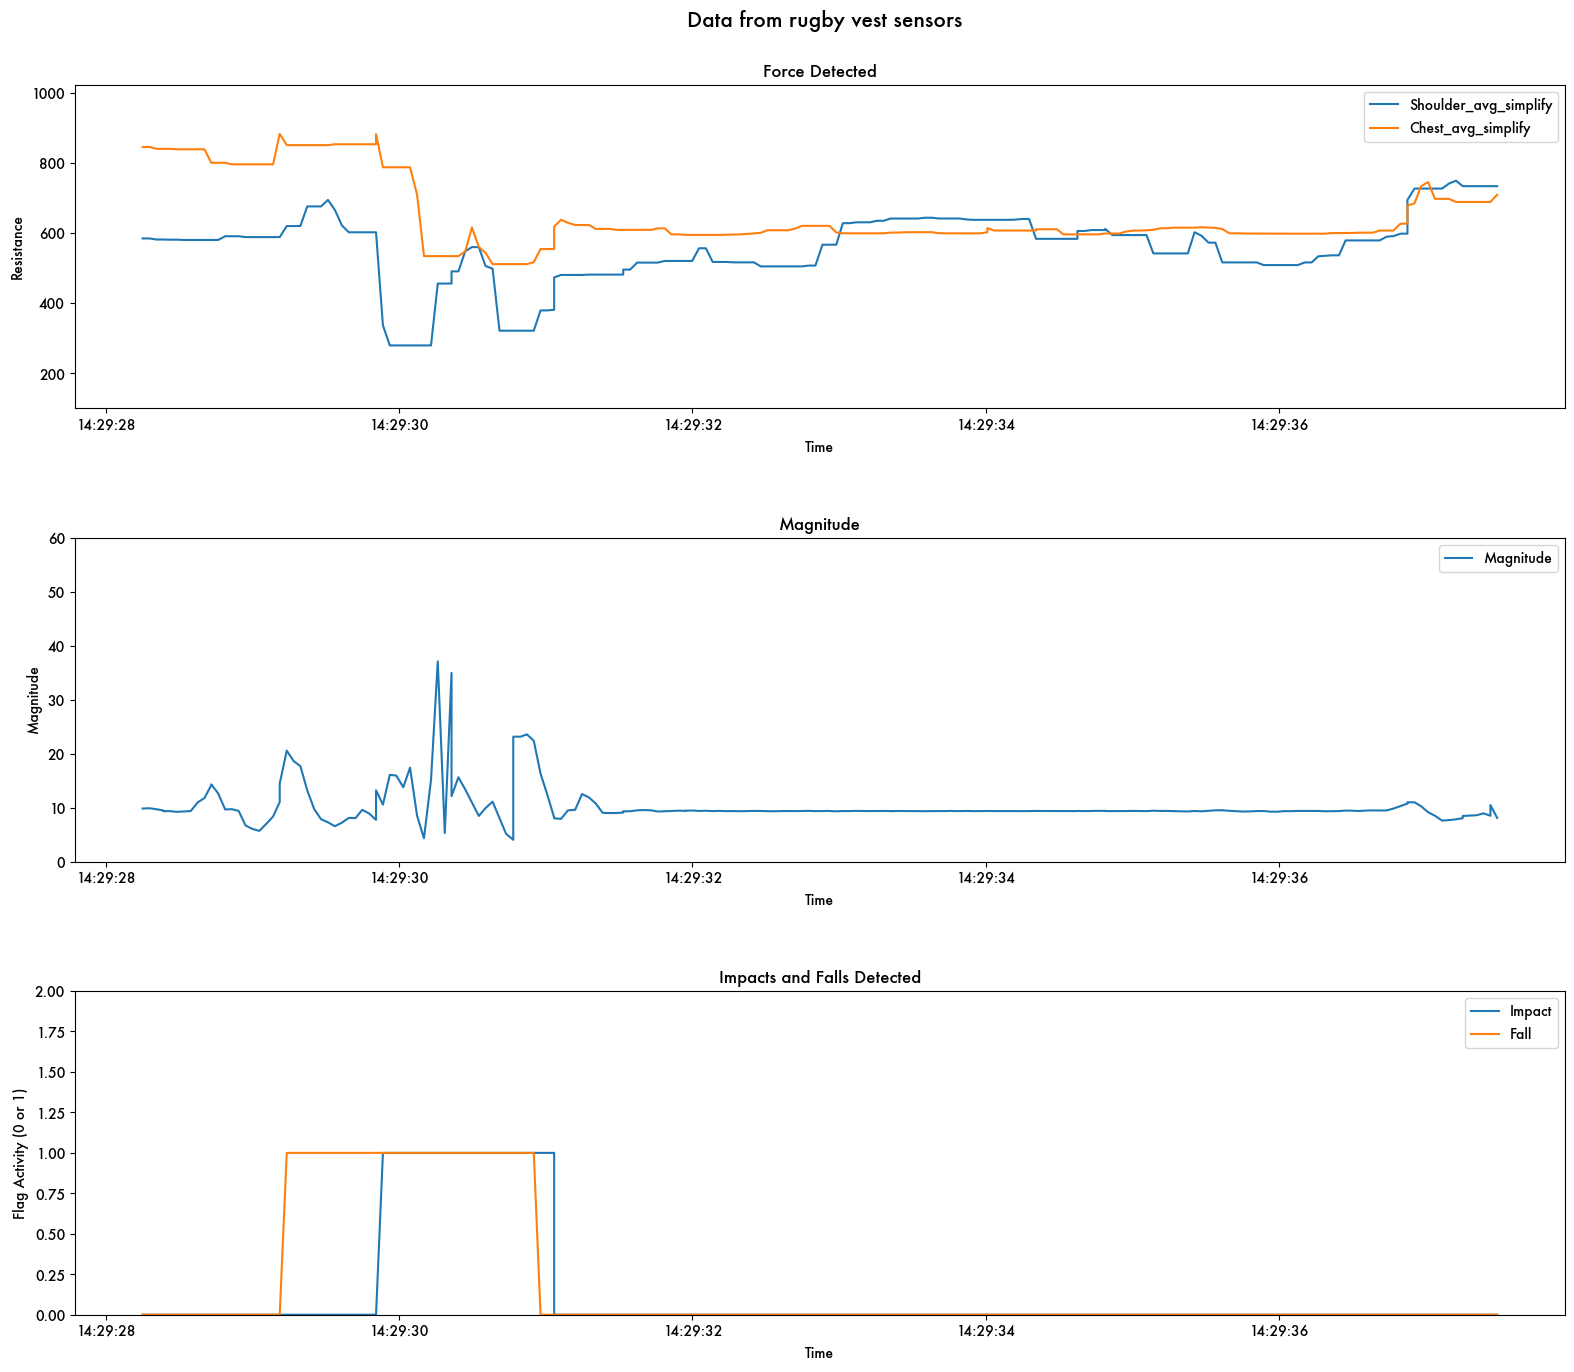

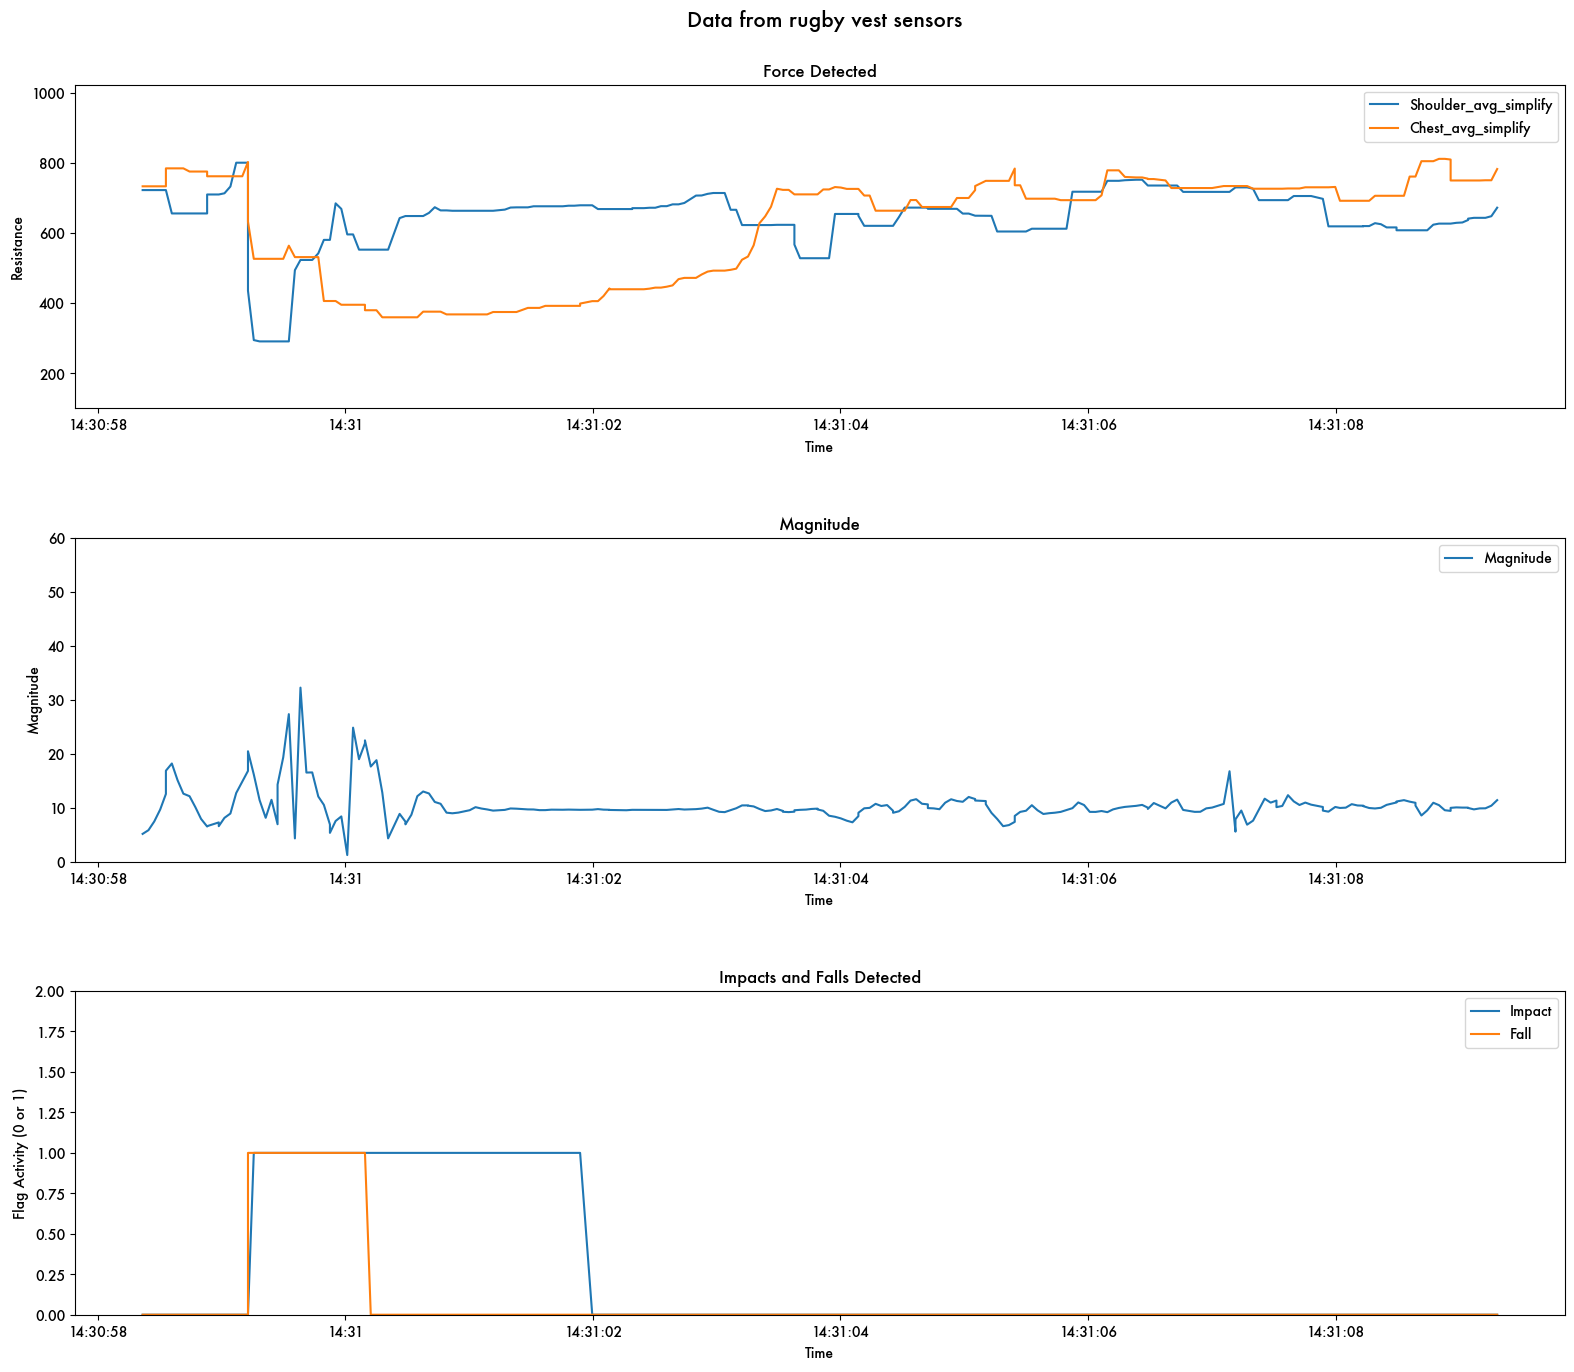

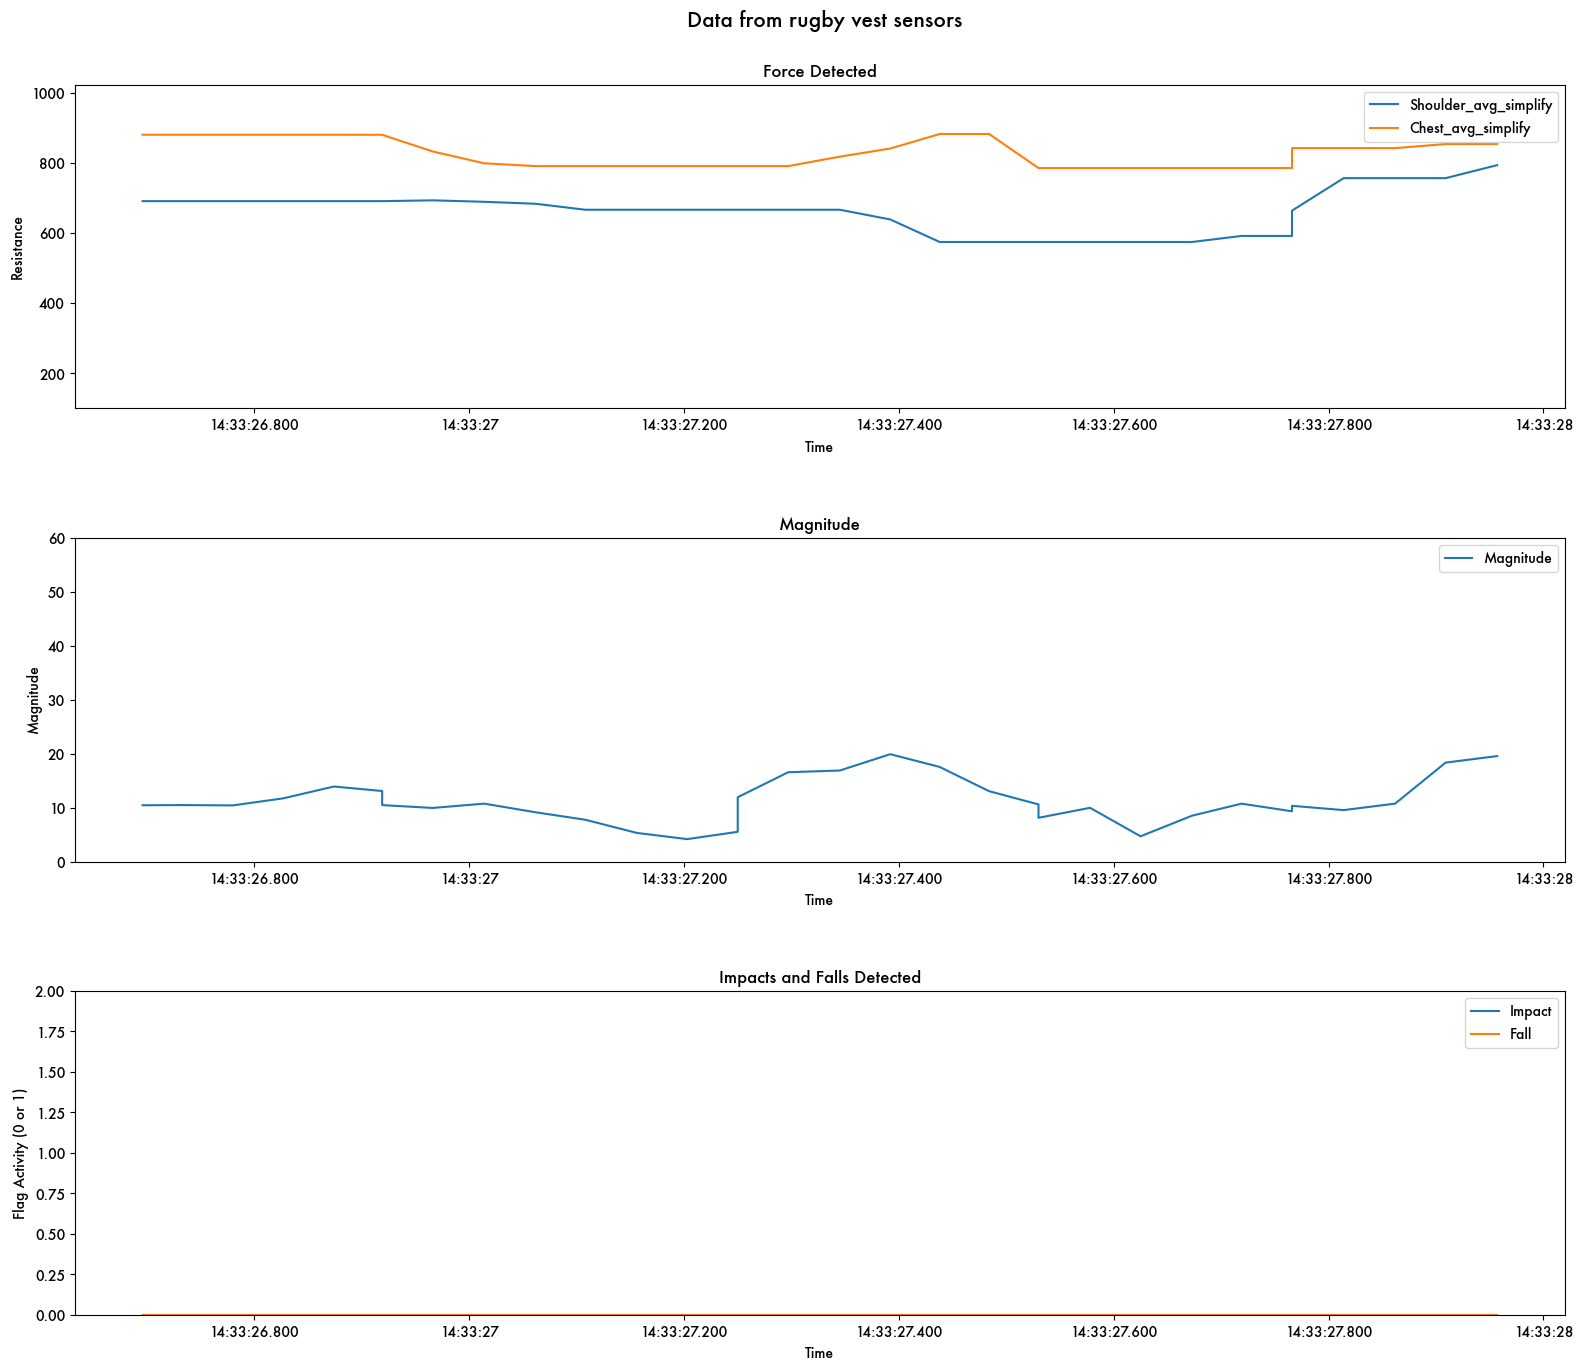

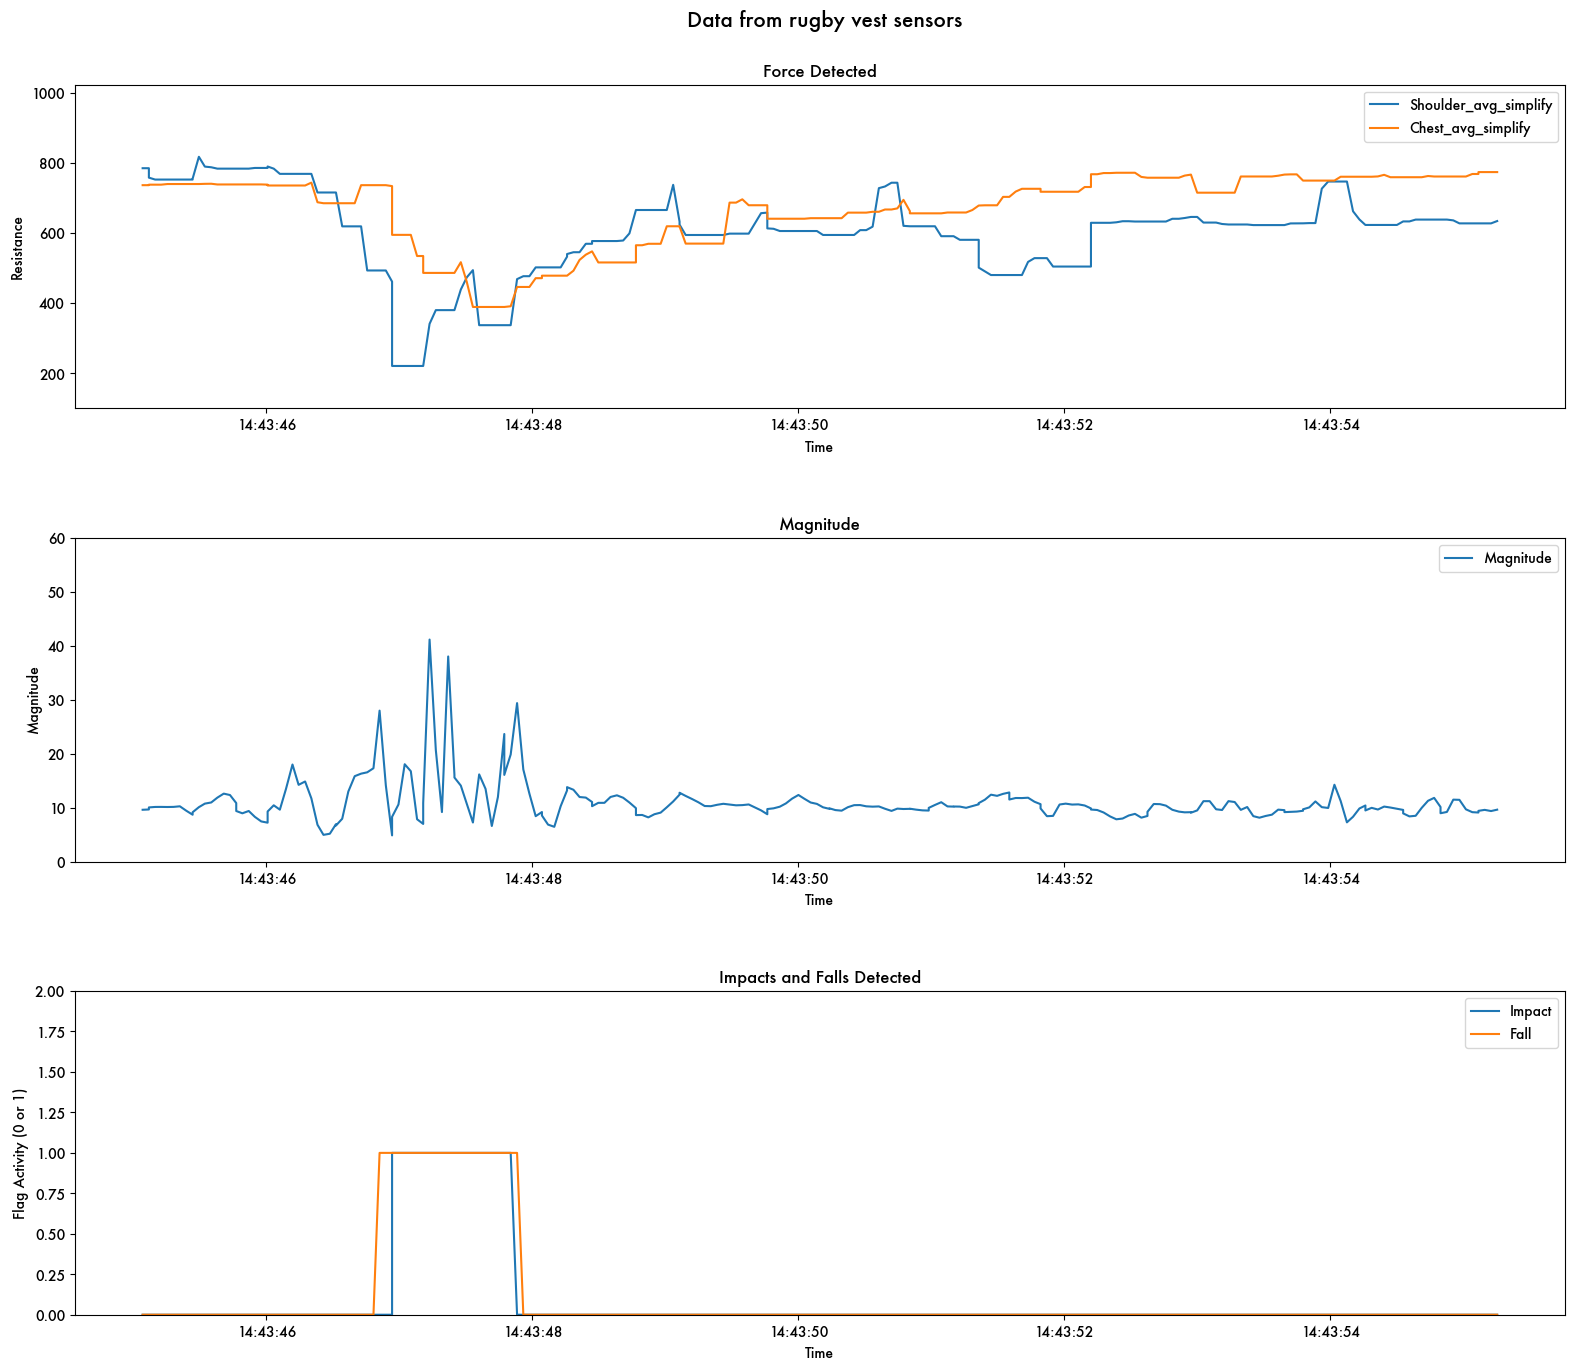

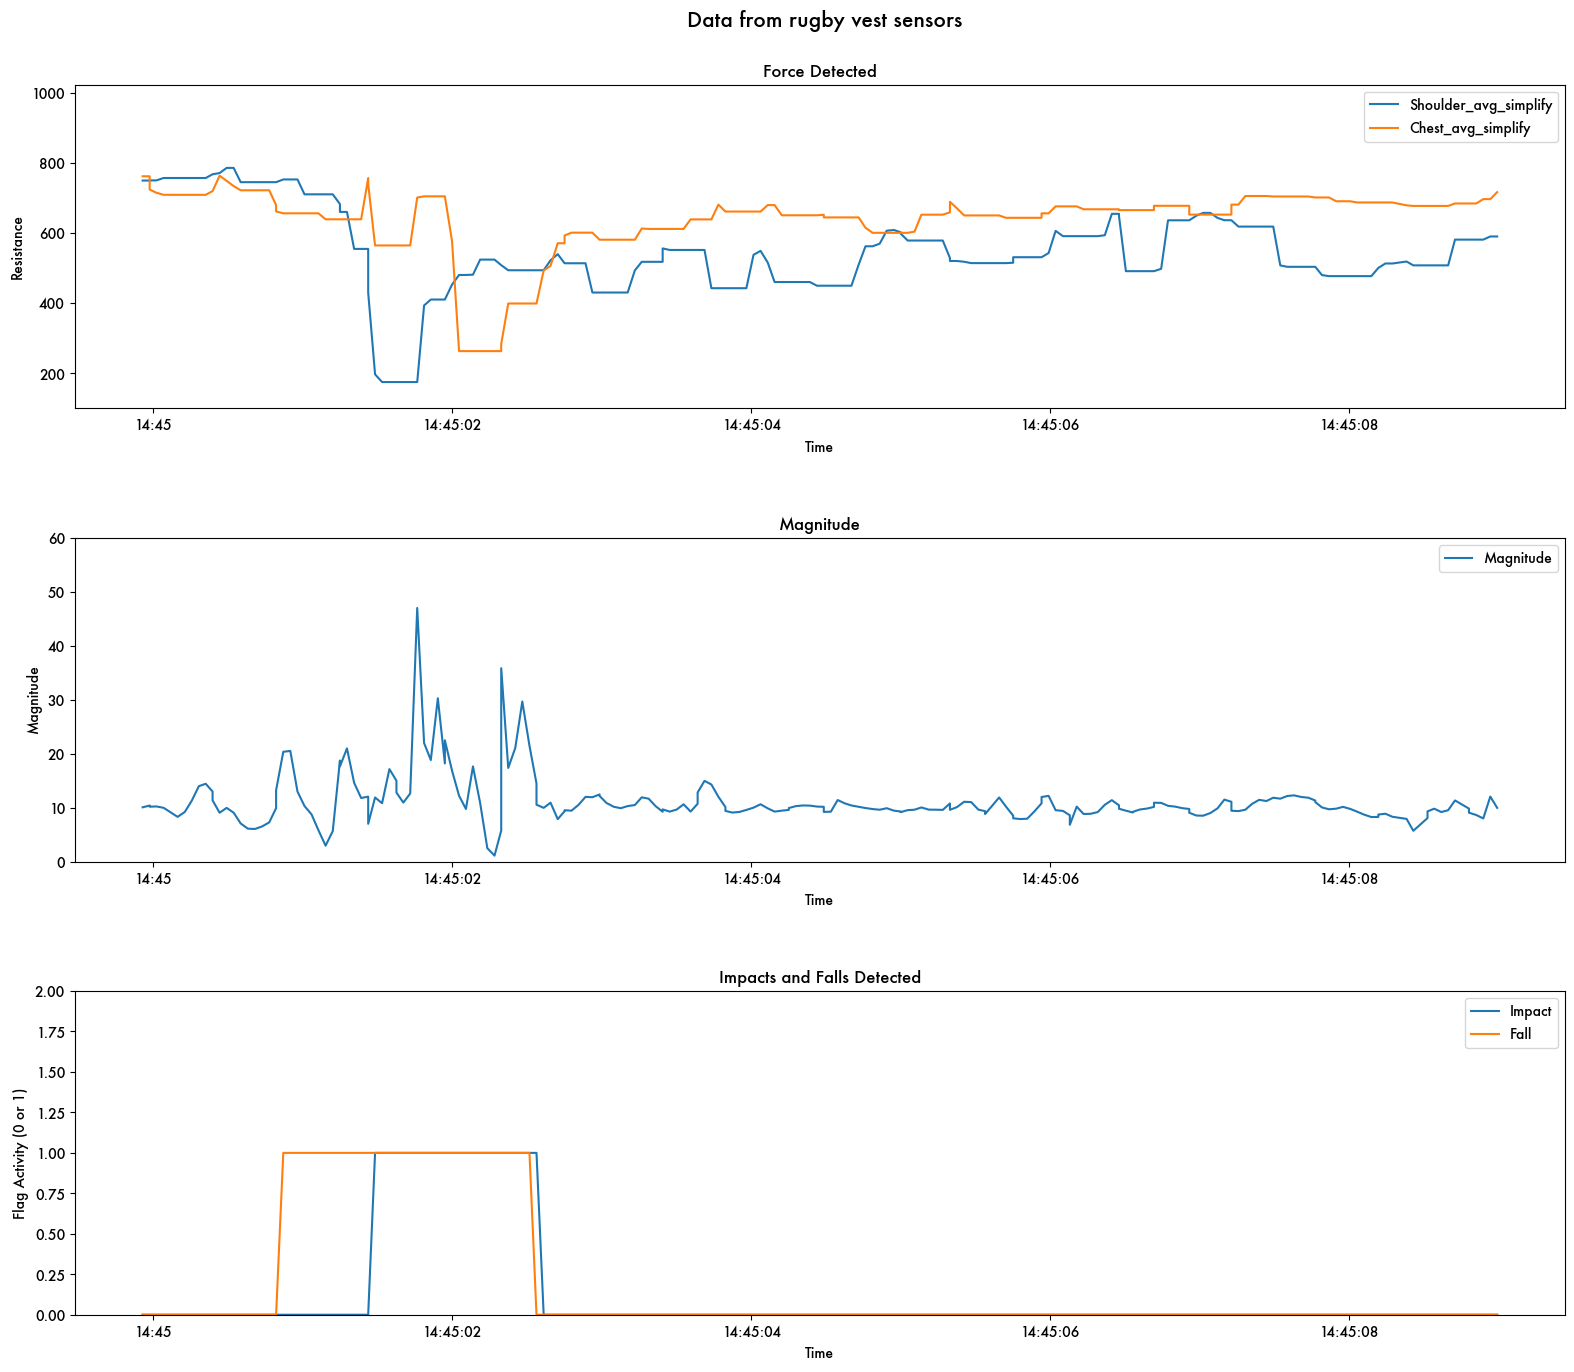

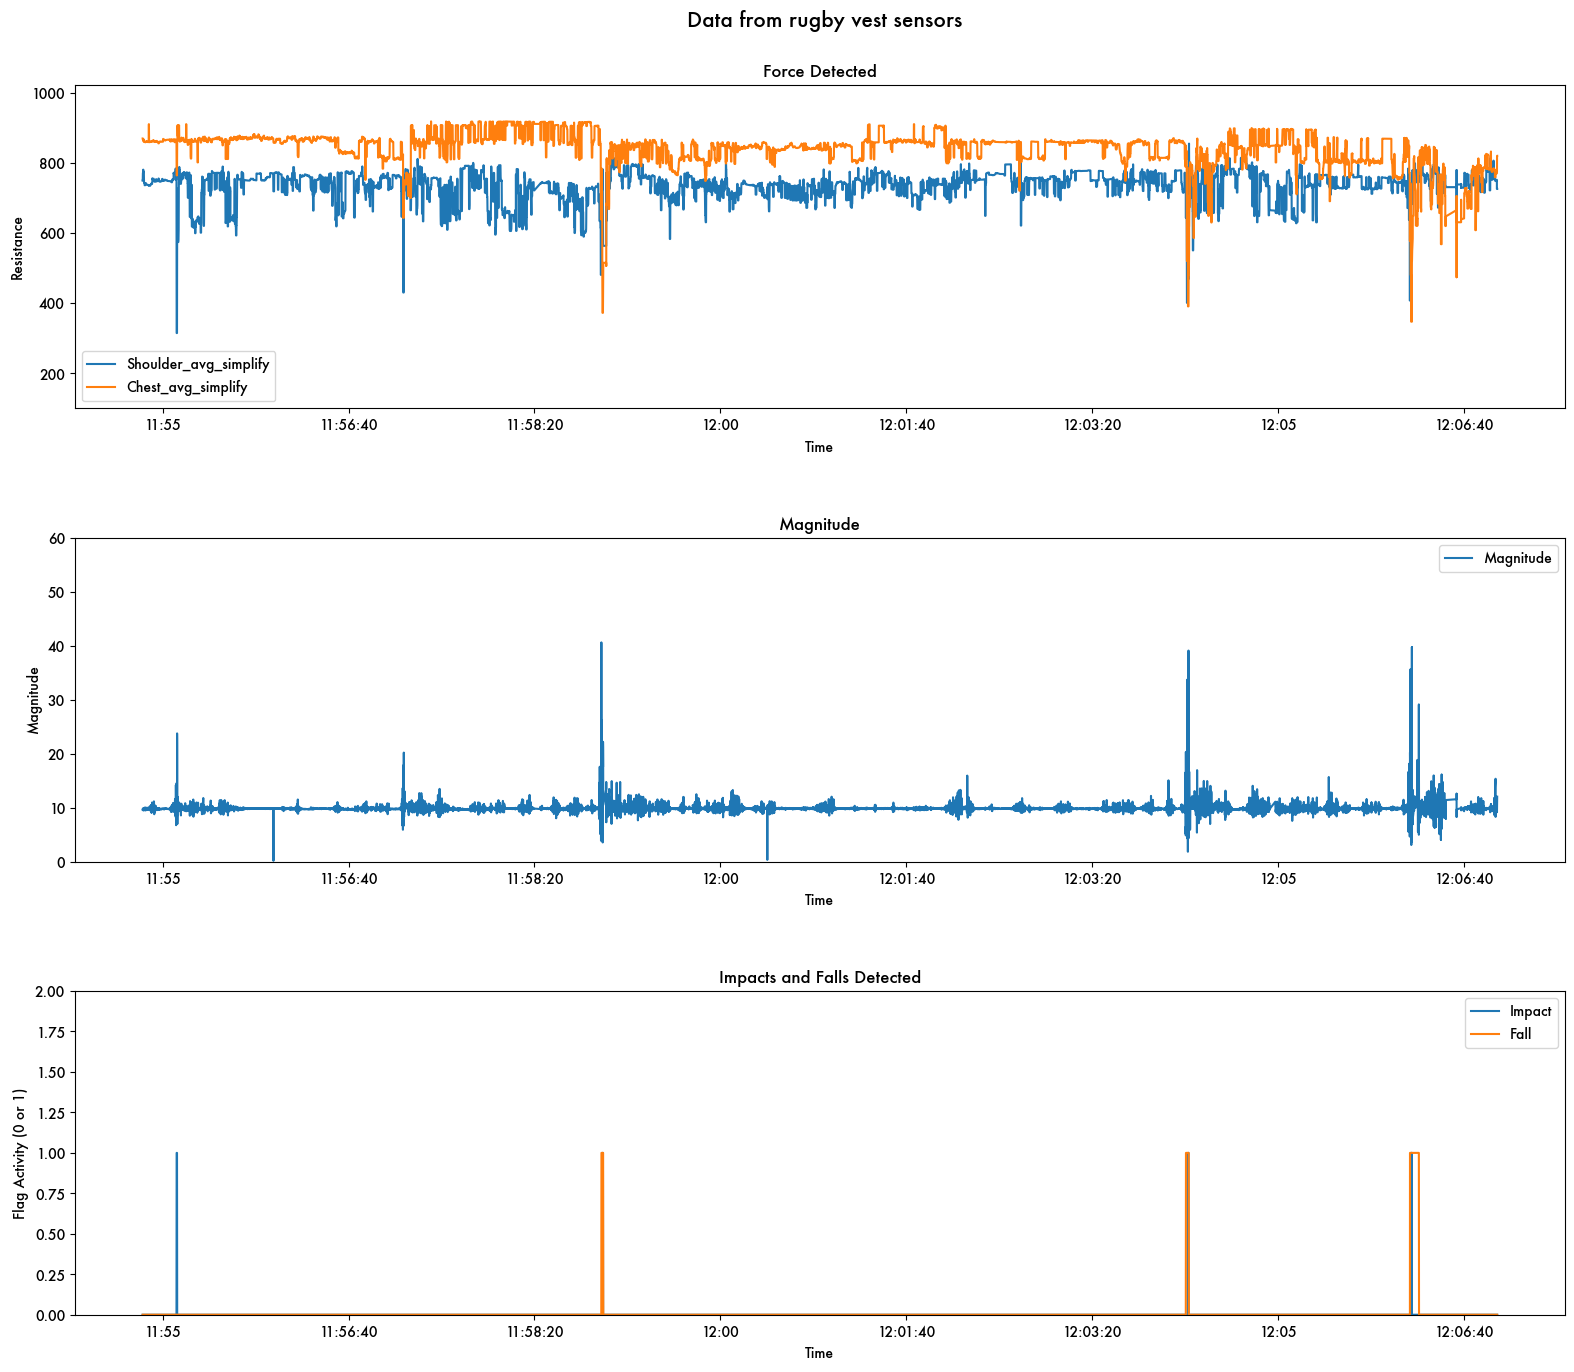

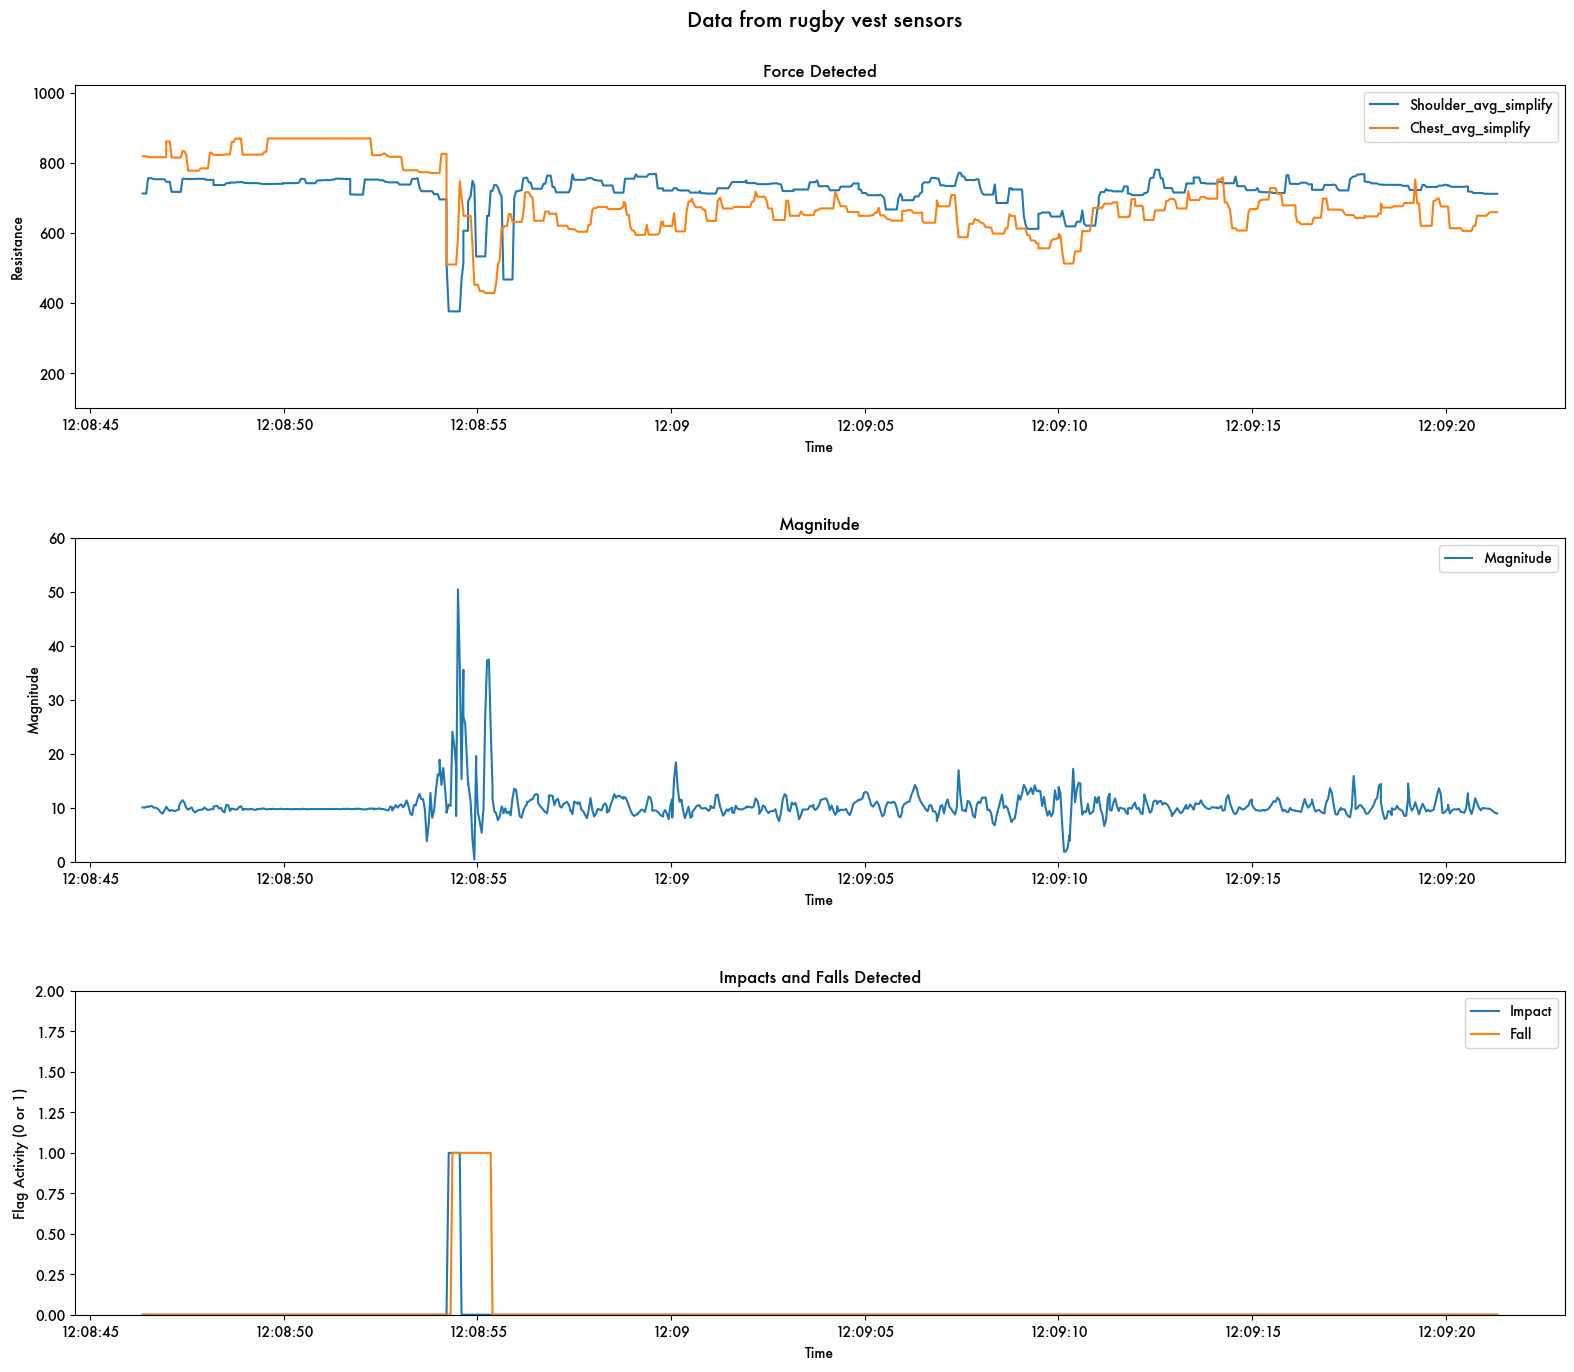

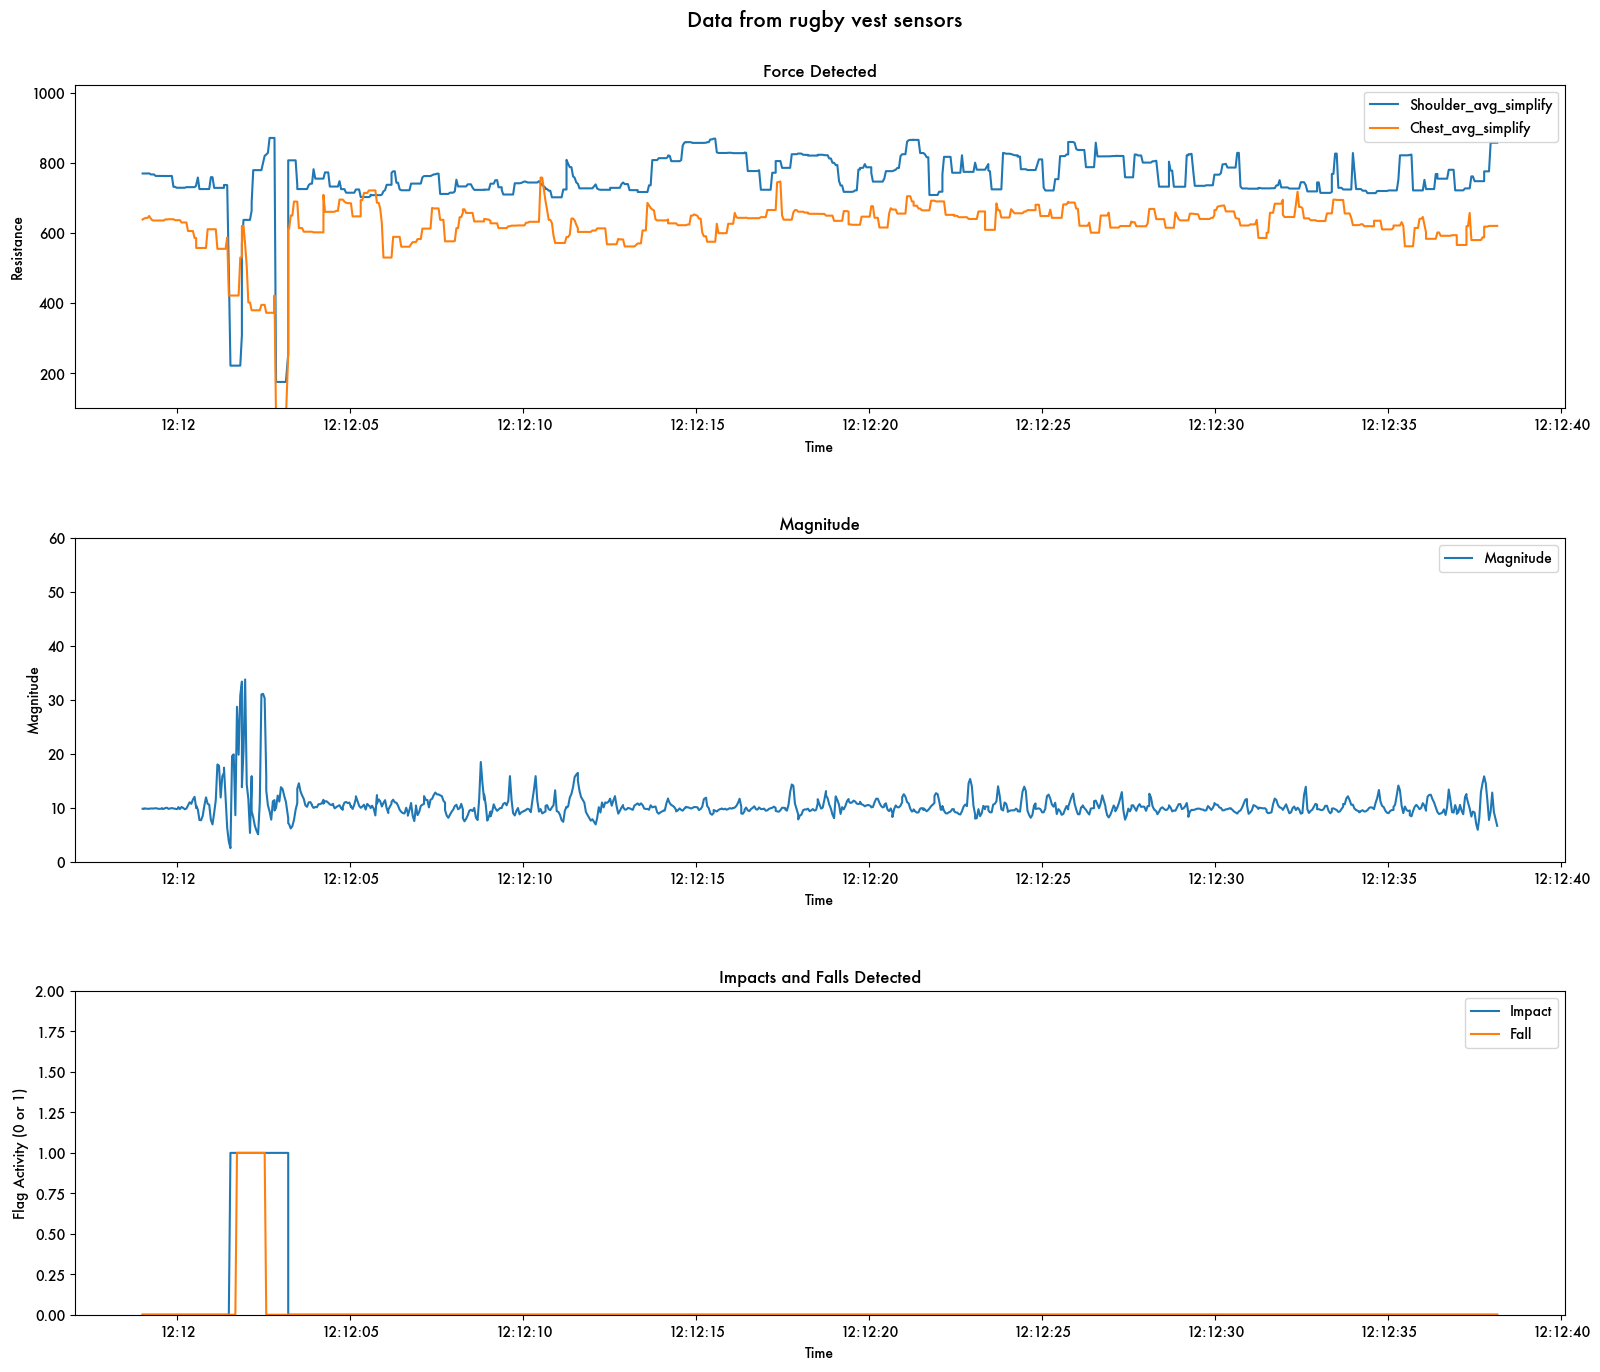

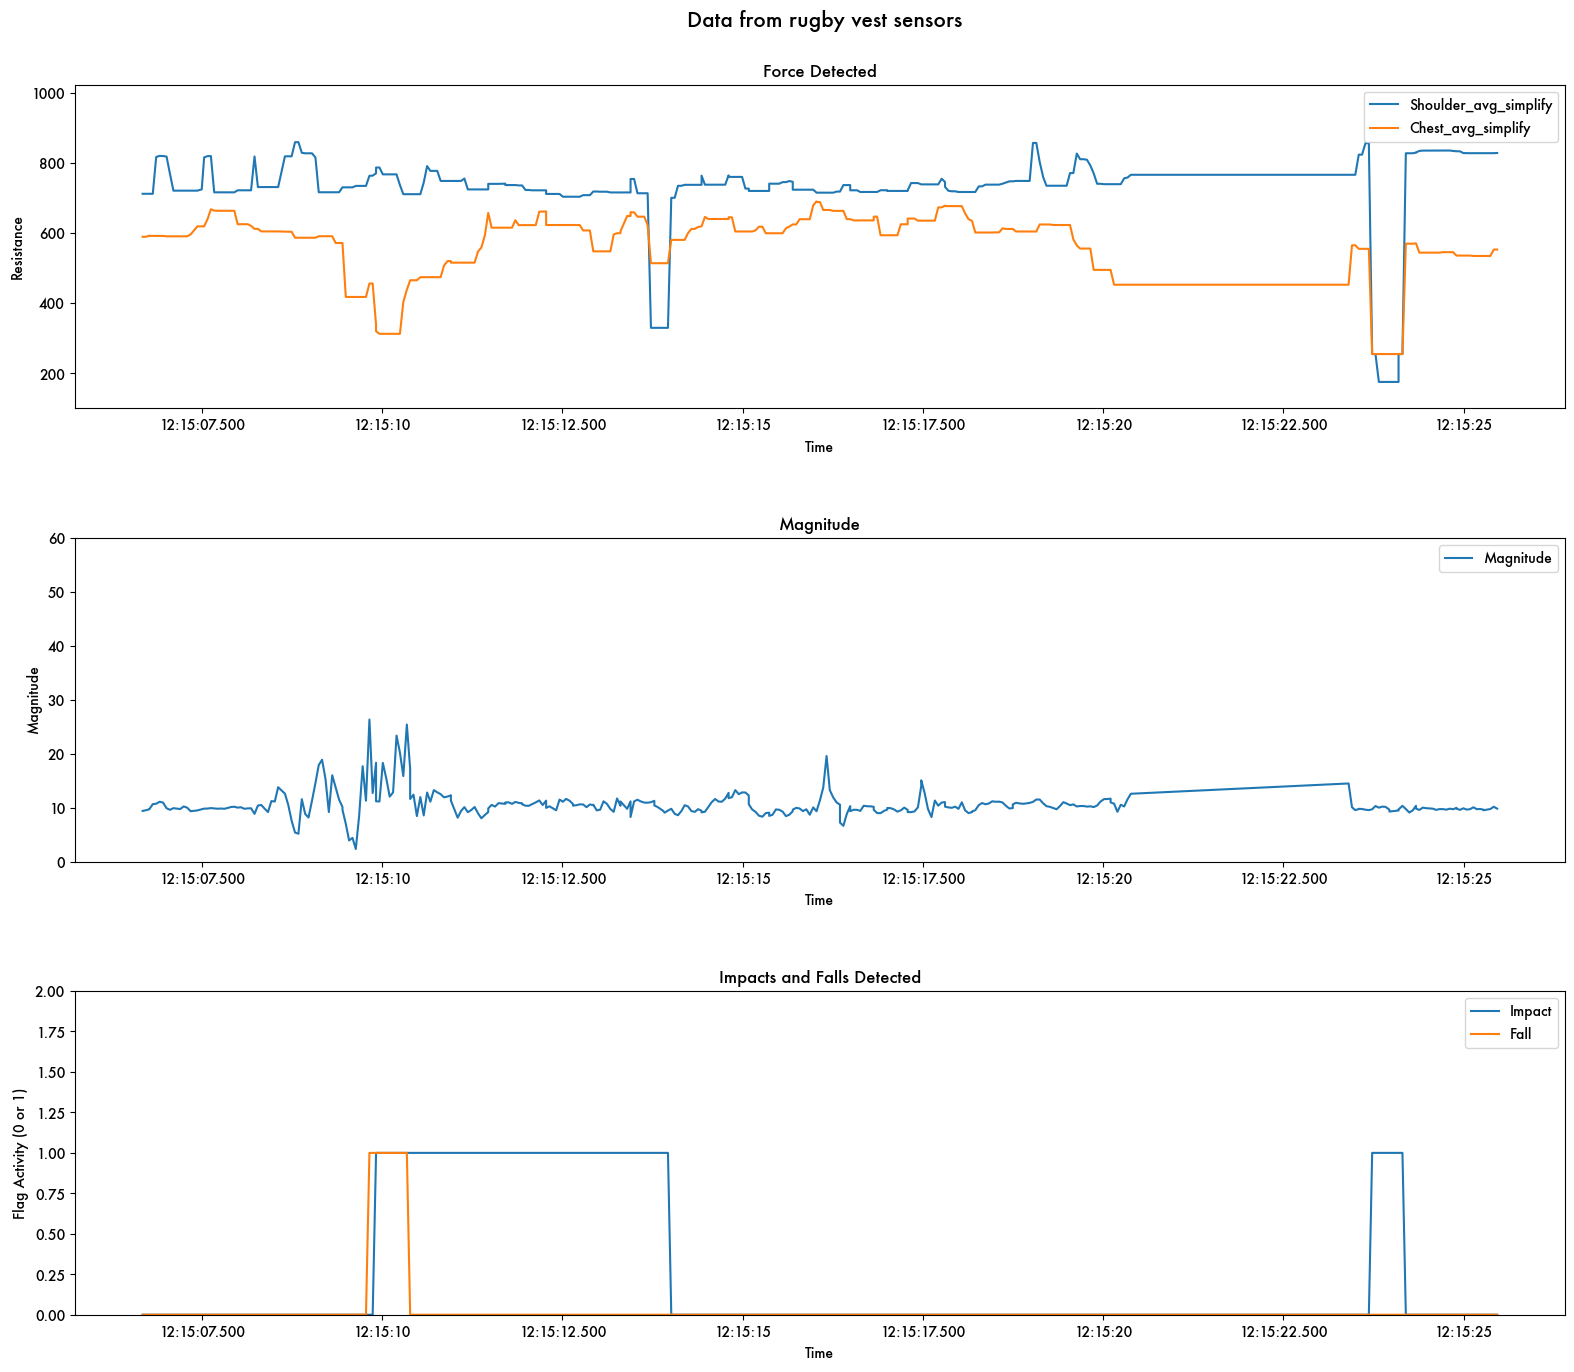

In [8]:
for i, data_table in enumerate(data_table_list_rugbyvest):
        
    # Plot multiple graphs after simplify the data
    fig, axis = plt.subplots(figsize = (20, 15), nrows = 3, ncols = 1)
    plt.subplots_adjust(hspace = 0.4)
    fig.suptitle('Data from rugby vest sensors', fontsize = 15, fontweight = 800)
    fig.subplots_adjust(top = 0.93, right = 0.87)
    data_table.plot(x = 'Time', y = 'Shoulder_avg_simplify', ax = axis[0], kind = 'line', title = 'Force Detected', ylim = (100, 1023), xlabel = 'Time', ylabel = 'Resistance')
    data_table.plot(x = 'Time', y = 'Chest_avg_simplify', ax = axis[0], kind = 'line', title = 'Force Detected', ylim = (100, 1023), xlabel = 'Time', ylabel = 'Resistance')
    data_table.plot(x = 'Time', y = 'Magnitude', ax = axis[1], kind = 'line', title = 'Magnitude', ylim = (0, 60), xlabel = 'Time', ylabel = 'Magnitude')
    data_table.plot(x = 'Time', y = 'Impact', ax = axis[2], kind = 'line', title = 'Impacts and Falls Detected', ylim = (0, 2), xlabel = 'Time', ylabel = 'Flag Activity (0 or 1)')
    data_table.plot(x = 'Time', y = 'Fall', ax = axis[2], kind = 'line', title = 'Impacts and Falls Detected', ylim = (0, 2), xlabel = 'Time', ylabel = 'Flag Activity (0 or 1)')
    plt.show()
    

Once the data and labels are prepared, they will be divided into training, validation, and testing datasets. This stage's final outputs include two input datasets (X) for the model to train for predicting impacts and falls, as well as three ground-truth label sets as outputs (Y) for detected shoulder impacts, chest impacts, and falls.

In [9]:
# Split to train-validation-test datasets
for i, data_table in enumerate(data_table_list_rugbyvest):
    
    # All - For combining results and majority voting (only validation and test)
    features = list(data_table.columns)
    x_validation = pd.concat([x_validation, split_dataset(data_table, features, 'validation')], axis = 0)
    x_test = pd.concat([x_test, split_dataset(data_table, features, 'test')], axis = 0)
    
    # Impact
    features_impact = [*shoulder1_colnames, *shoulder2_colnames, *chest1_colnames, *chest2_colnames]
    num_features_impact = len(features_impact)
    # x_impact
    x_train_impact.append(split_dataset(data_table, features_impact, 'train'))
    x_validation_impact.append(split_dataset(data_table, features_impact, 'validation'))
    x_test_impact.append(split_dataset(data_table, features_impact, 'test'))
    # y_shoulder_impact
    y_train_shoulder_impact.append(split_dataset(data_table, 'Shoulder Impact', 'train'))
    y_validation_shoulder_impact.append(split_dataset(data_table, 'Shoulder Impact', 'validation'))
    y_test_shoulder_impact.append(split_dataset(data_table, 'Shoulder Impact', 'test'))
    # y_chest_impact
    y_train_chest_impact.append(split_dataset(data_table, 'Chest Impact', 'train'))
    y_validation_chest_impact.append(split_dataset(data_table, 'Chest Impact', 'validation'))
    y_test_chest_impact.append(split_dataset(data_table, 'Chest Impact', 'test'))
    
    # Fall
    features_fall = [*acc_colnames, *gyro_colnames]
    num_features_fall = len(features_fall)
    # x_fall
    x_train_fall.append(split_dataset(data_table, features_fall, 'train'))
    x_validation_fall.append(split_dataset(data_table, features_fall, 'validation'))
    x_test_fall.append(split_dataset(data_table, features_fall, 'test'))
    # y_fall
    y_train_fall.append(split_dataset(data_table, 'Fall', 'train'))
    y_validation_fall.append(split_dataset(data_table, 'Fall', 'validation'))
    y_test_fall.append(split_dataset(data_table, 'Fall', 'test'))    
    
# Reindex for majority voting tables
x_validation = x_validation.reset_index(drop = True)
x_test = x_test.reset_index(drop = True)
    
# Impact
x_train_impact = reshape_input(x_train_impact)
x_validation_impact = reshape_input(x_validation_impact)
x_test_impact = reshape_input(x_test_impact)
y_train_shoulder_impact = reshape_input(y_train_shoulder_impact, True)
y_validation_shoulder_impact = reshape_input(y_validation_shoulder_impact, True)
y_test_shoulder_impact = reshape_input(y_test_shoulder_impact, True)
y_train_chest_impact = reshape_input(y_train_chest_impact, True)
y_validation_chest_impact = reshape_input(y_validation_chest_impact, True)
y_test_chest_impact = reshape_input(y_test_chest_impact, True)

# Fall
x_train_fall = reshape_input(x_train_fall)
x_validation_fall = reshape_input(x_validation_fall)
x_test_fall = reshape_input(x_test_fall)
y_train_fall = reshape_input(y_train_fall, True)
y_validation_fall = reshape_input(y_validation_fall, True)
y_test_fall = reshape_input(y_test_fall, True)


#### STEP 6: Develop Machine Learning Algorithms 

This project will develop 6 deep learning models with two main structures based on the Convolutional Neural Networks (CNN) architecture. One of which is to recognise impact and specify the impact region, which is either the shoulder or the chest, utilising rugby vest data, which will subsequently be merged with mouthguard data. Another one is intended to be used to detect fall movements. Two of those models are meant to examine each collision or fall at the microsecond level, line by line. However, due to the accuracy of the linking activity, another four models have been constructed to anticipate the data in chunks, also known as segments. The segments will be of constant size. The outcomes of each model will then be pooled, with the ultimate conclusion determined by majority vote.

After the models have been constructed and compiled, their performance will be evaluated. Beginning with the training, validation, and testing phases, line graphs will be generated to indicate the learning curve for loss and accuracy of each model.

#### Machine Learning Algorithm for Detecting Impacts and Area of Impacts

In [10]:
# For detecting impacts and output as the impacting areas
model_impact_list = []

# 1st Model (Process line by line)

input_shape = (1, num_features_impact)
input_data = Input(shape = input_shape)
model_impact = Conv1D(16, 3, activation = 'relu', padding = 'causal')(input_data)
model_impact = Conv1D(16, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Dropout(0.4)(model_impact)
model_impact = Conv1D(32, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Dropout(0.4)(model_impact)
model_impact = Flatten()(model_impact)

shoulder_branch = Dense(32, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_impact)
shoulder_branch = Dense(16, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(shoulder_branch)
shoulder_branch = Dense(8, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(shoulder_branch)
shoulder_branch = Dense(1, activation = 'sigmoid', name="shoulder_impact")(shoulder_branch)  # Output layer for binary classification

chest_branch = Dense(32, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_impact)
chest_branch = Dense(16, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(chest_branch)
chest_branch = Dense(1, activation = 'sigmoid', name="chest_impact")(chest_branch)  # Output layer for binary classification

# Combine the defined structure into model
final_model_impact = Model(inputs = input_data, outputs = [shoulder_branch, chest_branch])

# Compile model
optimizer = Adam(learning_rate = learning_rate)
final_model_impact.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
final_model_impact.summary() 

# Set up early stopping and learning rate fine tune process to stop when the model performance doesn't improve anymore 
early_stopping_callback = EarlyStopping(monitor = 'val_loss', min_delta = 0.0001, patience = 10, mode = 'min', restore_best_weights = True)
reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 10)
saved_checkpoint = ModelCheckpoint(filepath = folder_path + folder_output + 'ml_cnn_impact_detection_shape_1.h5' , save_best_only = True, verbose = 2)

# Model fitting and evaluate model accuracy
model_impact = final_model_impact.fit(x_train_impact[0], [y_train_shoulder_impact[0], y_train_chest_impact[0]], batch_size = 256, epochs = max_epoch, validation_data = (x_validation_impact[0], [y_validation_shoulder_impact[0], y_validation_chest_impact[0]]), callbacks = [early_stopping_callback, reduce_learning_rate, saved_checkpoint])
model_impact_train_evaluation = final_model_impact.evaluate(x_validation_impact[0], [y_validation_shoulder_impact[0], y_validation_chest_impact[0]])
model_impact_list.append(model_impact)

print("Validation Loss:", model_impact_train_evaluation[0])
print("Validation Loss (Shoulder Impact):", model_impact_train_evaluation[1])
print("Validation Loss (Chest Impact):", model_impact_train_evaluation[2])
print("Validation Accuracy (Shoulder Impact):", model_impact_train_evaluation[3])
print("Validation Accuracy (Chest Impact):", model_impact_train_evaluation[4])


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1, 32)]      0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 1, 16)        1552        ['input_1[0][0]']                
                                                                                                  
 conv1d_1 (Conv1D)              (None, 1, 16)        784         ['conv1d[0][0]']                 
                                                                                                  
 dropout (Dropout)              (None, 1, 16)        0           ['conv1d_1[0][0]']               
                                                                                              

2023-09-07 08:34:19.564711: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


30/55 [===============>..............] - ETA: 0s - loss: 2.4766 - shoulder_impact_loss: 0.1988 - chest_impact_loss: 0.9275 - shoulder_impact_accuracy: 0.9374 - chest_impact_accuracy: 0.8841  
Epoch 1: val_loss improved from inf to 1.26725, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_1.h5
55/55 [==============================] - 1s 6ms/step - loss: 1.9931 - shoulder_impact_loss: 0.1458 - chest_impact_loss: 0.5436 - shoulder_impact_accuracy: 0.9606 - chest_impact_accuracy: 0.9336 - val_loss: 1.2673 - val_shoulder_impact_loss: 0.0436 - val_chest_impact_loss: 0.0274 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9970 - lr: 0.0010
Epoch 2/200
51/55 [==========================>...] - ETA: 0s - loss: 1.2564 - shoulder_impact_loss: 0.0754 - chest_impact_loss: 0.0764 - shoulder_impact_accuracy: 0.9891 - chest_impact_accuracy: 0.9916
Epoch 2: val_loss improved

55/55 [==============================] - 0s 6ms/step - loss: 0.3970 - shoulder_impact_loss: 0.0444 - chest_impact_loss: 0.0235 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9929 - val_loss: 0.3500 - val_shoulder_impact_loss: 0.0222 - val_chest_impact_loss: 0.0152 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9950 - lr: 0.0010
Epoch 12/200
44/55 [=======================>......] - ETA: 0s - loss: 0.3684 - shoulder_impact_loss: 0.0434 - chest_impact_loss: 0.0238 - shoulder_impact_accuracy: 0.9899 - chest_impact_accuracy: 0.9928
Epoch 12: val_loss improved from 0.35001 to 0.32420, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_1.h5
55/55 [==============================] - 0s 6ms/step - loss: 0.3676 - shoulder_impact_loss: 0.0450 - chest_impact_loss: 0.0241 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9927 - val_loss: 0.3242

Epoch 22/200
55/55 [==============================] - ETA: 0s - loss: 0.1922 - shoulder_impact_loss: 0.0410 - chest_impact_loss: 0.0196 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9935
Epoch 22: val_loss improved from 0.16939 to 0.16148, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_1.h5
55/55 [==============================] - 0s 5ms/step - loss: 0.1922 - shoulder_impact_loss: 0.0410 - chest_impact_loss: 0.0196 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9935 - val_loss: 0.1615 - val_shoulder_impact_loss: 0.0196 - val_chest_impact_loss: 0.0152 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9950 - lr: 0.0010
Epoch 23/200
49/55 [=========================>....] - ETA: 0s - loss: 0.1865 - shoulder_impact_loss: 0.0428 - chest_impact_loss: 0.0211 - shoulder_impact_accuracy: 0.9890 - chest_impact_accuracy: 0.9933
Epoch 23:

55/55 [==============================] - ETA: 0s - loss: 0.1164 - shoulder_impact_loss: 0.0378 - chest_impact_loss: 0.0176 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9942
Epoch 33: val_loss did not improve from 0.10290
55/55 [==============================] - 0s 3ms/step - loss: 0.1164 - shoulder_impact_loss: 0.0378 - chest_impact_loss: 0.0176 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9942 - val_loss: 0.1036 - val_shoulder_impact_loss: 0.0297 - val_chest_impact_loss: 0.0151 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9950 - lr: 0.0010
Epoch 34/200
52/55 [===========================>..] - ETA: 0s - loss: 0.1122 - shoulder_impact_loss: 0.0383 - chest_impact_loss: 0.0168 - shoulder_impact_accuracy: 0.9896 - chest_impact_accuracy: 0.9942
Epoch 34: val_loss improved from 0.10290 to 0.09296, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_im

53/55 [===========================>..] - ETA: 0s - loss: 0.0817 - shoulder_impact_loss: 0.0376 - chest_impact_loss: 0.0163 - shoulder_impact_accuracy: 0.9892 - chest_impact_accuracy: 0.9955
Epoch 45: val_loss did not improve from 0.06239
55/55 [==============================] - 0s 4ms/step - loss: 0.0813 - shoulder_impact_loss: 0.0374 - chest_impact_loss: 0.0162 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9955 - val_loss: 0.0762 - val_shoulder_impact_loss: 0.0353 - val_chest_impact_loss: 0.0143 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9947 - lr: 0.0010
Epoch 46/200
54/55 [============================>.] - ETA: 0s - loss: 0.0787 - shoulder_impact_loss: 0.0366 - chest_impact_loss: 0.0161 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9949
Epoch 46: val_loss improved from 0.06239 to 0.05726, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_im

Epoch 58/200
53/55 [===========================>..] - ETA: 0s - loss: 0.0628 - shoulder_impact_loss: 0.0365 - chest_impact_loss: 0.0139 - shoulder_impact_accuracy: 0.9891 - chest_impact_accuracy: 0.9960
Epoch 58: val_loss did not improve from 0.04273
55/55 [==============================] - 0s 6ms/step - loss: 0.0621 - shoulder_impact_loss: 0.0358 - chest_impact_loss: 0.0139 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9960 - val_loss: 0.0625 - val_shoulder_impact_loss: 0.0352 - val_chest_impact_loss: 0.0151 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9953 - lr: 0.0010
Epoch 59/200
51/55 [==========================>...] - ETA: 0s - loss: 0.0642 - shoulder_impact_loss: 0.0364 - chest_impact_loss: 0.0161 - shoulder_impact_accuracy: 0.9890 - chest_impact_accuracy: 0.9956
Epoch 59: val_loss did not improve from 0.04273
55/55 [==============================] - 0s 7ms/step - loss: 0.0630 - shoulder_impact_loss: 0.0353 - chest_impact_loss: 0.0160 - s

In [11]:
# 2nd Model (Process by fixed-size segment) - 12 rows

input_shape = (12, num_features_impact)
input_data = Input(shape = input_shape)
model_impact = Conv1D(16, 3, activation = 'relu', padding = 'causal')(input_data)
model_impact = Conv1D(16, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Dropout(0.3)(model_impact)
model_impact = AveragePooling1D(2, strides = 1)(model_impact)
model_impact = Conv1D(32, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Dropout(0.3)(model_impact)
model_impact = AveragePooling1D(2, strides = 1)(model_impact)
model_impact = Conv1D(128, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Dropout(0.3)(model_impact)
model_impact = AveragePooling1D(2, strides = 1)(model_impact)
model_impact = Flatten()(model_impact)

shoulder_branch = Dense(16, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_impact)
shoulder_branch = Dense(8, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(shoulder_branch)
shoulder_branch = Dense(1, activation = 'sigmoid', name="shoulder_impact")(shoulder_branch)  # Output layer for binary classification

chest_branch = Dense(64, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_impact)
chest_branch = Dense(32, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(chest_branch)
chest_branch = Dense(1, activation = 'sigmoid', name="chest_impact")(chest_branch)  # Output layer for binary classification

# Combine the defined structure into model
final_model_impact = Model(inputs = input_data, outputs = [shoulder_branch, chest_branch])

# Compile model
optimizer = Adam(learning_rate = learning_rate)
final_model_impact.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
final_model_impact.summary() 

# Set up early stopping and learning rate fine tune process to stop when the model performance doesn't improve anymore 
early_stopping_callback = EarlyStopping(monitor = 'val_loss', min_delta = 0.0001, patience = 10, mode = 'min', restore_best_weights = True)
reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 10)
saved_checkpoint = ModelCheckpoint(filepath = folder_path + folder_output + 'ml_cnn_impact_detection_shape_2.h5' , save_best_only = True, verbose = 2)

# Model fitting and evaluate model accuracy
model_impact = final_model_impact.fit(x_train_impact[1], [y_train_shoulder_impact[1], y_train_chest_impact[1]], batch_size = 64, epochs = max_epoch, validation_data = (x_validation_impact[1], [y_validation_shoulder_impact[1], y_validation_chest_impact[1]]), callbacks = [early_stopping_callback, reduce_learning_rate, saved_checkpoint])
model_impact_train_evaluation = final_model_impact.evaluate(x_validation_impact[1], [y_validation_shoulder_impact[1], y_validation_chest_impact[1]])
model_impact_list.append(model_impact)

print("Validation Loss:", model_impact_train_evaluation[0])
print("Validation Loss (Shoulder Impact):", model_impact_train_evaluation[1])
print("Validation Loss (Chest Impact):", model_impact_train_evaluation[2])
print("Validation Accuracy (Shoulder Impact):", model_impact_train_evaluation[3])
print("Validation Accuracy (Chest Impact):", model_impact_train_evaluation[4])


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 12, 32)]     0           []                               
                                                                                                  
 conv1d_4 (Conv1D)              (None, 12, 16)       1552        ['input_2[0][0]']                
                                                                                                  
 conv1d_5 (Conv1D)              (None, 12, 16)       784         ['conv1d_4[0][0]']               
                                                                                                  
 dropout_2 (Dropout)            (None, 12, 16)       0           ['conv1d_5[0][0]']               
                                                                                            

19/19 [==============================] - 0s 12ms/step - loss: 1.4470 - shoulder_impact_loss: 0.0994 - chest_impact_loss: 0.0742 - shoulder_impact_accuracy: 0.9813 - chest_impact_accuracy: 0.9881 - val_loss: 1.2818 - val_shoulder_impact_loss: 0.0146 - val_chest_impact_loss: 0.0294 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9922 - lr: 0.0010
Epoch 6/200
15/19 [======================>.......] - ETA: 0s - loss: 1.3938 - shoulder_impact_loss: 0.1110 - chest_impact_loss: 0.0678 - shoulder_impact_accuracy: 0.9771 - chest_impact_accuracy: 0.9875
Epoch 6: val_loss improved from 1.28182 to 1.22050, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_2.h5
19/19 [==============================] - 0s 15ms/step - loss: 1.3714 - shoulder_impact_loss: 0.1028 - chest_impact_loss: 0.0589 - shoulder_impact_accuracy: 0.9796 - chest_impact_accuracy: 0.9889 - val_loss: 1.2205

Epoch 16/200
14/19 [=====================>........] - ETA: 0s - loss: 0.9054 - shoulder_impact_loss: 0.0670 - chest_impact_loss: 0.0398 - shoulder_impact_accuracy: 0.9810 - chest_impact_accuracy: 0.9900
Epoch 16: val_loss improved from 0.85219 to 0.83895, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_2.h5
19/19 [==============================] - 0s 11ms/step - loss: 0.9129 - shoulder_impact_loss: 0.0777 - chest_impact_loss: 0.0400 - shoulder_impact_accuracy: 0.9813 - chest_impact_accuracy: 0.9898 - val_loss: 0.8389 - val_shoulder_impact_loss: 0.0350 - val_chest_impact_loss: 0.0243 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9922 - lr: 0.0010
Epoch 17/200
15/19 [======================>.......] - ETA: 0s - loss: 0.8924 - shoulder_impact_loss: 0.0780 - chest_impact_loss: 0.0448 - shoulder_impact_accuracy: 0.9812 - chest_impact_accuracy: 0.9885
Epoch 17

Epoch 27/200
13/19 [===================>..........] - ETA: 0s - loss: 0.6491 - shoulder_impact_loss: 0.0512 - chest_impact_loss: 0.0425 - shoulder_impact_accuracy: 0.9916 - chest_impact_accuracy: 0.9916
Epoch 27: val_loss did not improve from 0.60128
19/19 [==============================] - 0s 10ms/step - loss: 0.6617 - shoulder_impact_loss: 0.0701 - chest_impact_loss: 0.0386 - shoulder_impact_accuracy: 0.9847 - chest_impact_accuracy: 0.9932 - val_loss: 0.6324 - val_shoulder_impact_loss: 0.0564 - val_chest_impact_loss: 0.0319 - val_shoulder_impact_accuracy: 0.9961 - val_chest_impact_accuracy: 0.9961 - lr: 0.0010
Epoch 28/200
14/19 [=====================>........] - ETA: 0s - loss: 0.6328 - shoulder_impact_loss: 0.0650 - chest_impact_loss: 0.0286 - shoulder_impact_accuracy: 0.9866 - chest_impact_accuracy: 0.9911
Epoch 28: val_loss improved from 0.60128 to 0.56546, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output f

Epoch 38/200
16/19 [========================>.....] - ETA: 0s - loss: 0.4746 - shoulder_impact_loss: 0.0522 - chest_impact_loss: 0.0169 - shoulder_impact_accuracy: 0.9893 - chest_impact_accuracy: 0.9951
Epoch 38: val_loss improved from 0.45909 to 0.44011, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_2.h5
19/19 [==============================] - 0s 16ms/step - loss: 0.4818 - shoulder_impact_loss: 0.0507 - chest_impact_loss: 0.0263 - shoulder_impact_accuracy: 0.9889 - chest_impact_accuracy: 0.9932 - val_loss: 0.4401 - val_shoulder_impact_loss: 0.0252 - val_chest_impact_loss: 0.0165 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9961 - lr: 0.0010
Epoch 39/200
16/19 [========================>.....] - ETA: 0s - loss: 0.4694 - shoulder_impact_loss: 0.0517 - chest_impact_loss: 0.0234 - shoulder_impact_accuracy: 0.9844 - chest_impact_accuracy: 0.9893
Epoch 39

...

Epoch 95/200
18/19 [===========================>..] - ETA: 0s - loss: 0.1401 - shoulder_impact_loss: 0.0260 - chest_impact_loss: 0.0030 - shoulder_impact_accuracy: 0.9931 - chest_impact_accuracy: 0.9991  
Epoch 95: val_loss improved from 0.15187 to 0.14421, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_2.h5
19/19 [==============================] - 0s 13ms/step - loss: 0.1466 - shoulder_impact_loss: 0.0293 - chest_impact_loss: 0.0063 - shoulder_impact_accuracy: 0.9923 - chest_impact_accuracy: 0.9983 - val_loss: 0.1442 - val_shoulder_impact_loss: 0.0132 - val_chest_impact_loss: 0.0215 - val_shoulder_impact_accuracy: 0.9961 - val_chest_impact_accuracy: 0.9961 - lr: 0.0010
Epoch 96/200
19/19 [==============================] - ETA: 0s - loss: 0.1939 - shoulder_impact_loss: 0.0455 - chest_impact_loss: 0.0395 - shoulder_impact_accuracy: 0.9872 - chest_impact_accuracy: 0.9906  
Epoc

Epoch 108/200
18/19 [===========================>..] - ETA: 0s - loss: 0.1137 - shoulder_impact_loss: 0.0187 - chest_impact_loss: 0.0081 - shoulder_impact_accuracy: 0.9931 - chest_impact_accuracy: 0.9974
Epoch 108: val_loss improved from 0.13692 to 0.12023, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_2.h5
19/19 [==============================] - 0s 17ms/step - loss: 0.1137 - shoulder_impact_loss: 0.0187 - chest_impact_loss: 0.0080 - shoulder_impact_accuracy: 0.9932 - chest_impact_accuracy: 0.9974 - val_loss: 0.1202 - val_shoulder_impact_loss: 0.0245 - val_chest_impact_loss: 0.0096 - val_shoulder_impact_accuracy: 0.9922 - val_chest_impact_accuracy: 0.9961 - lr: 0.0010
Epoch 109/200
18/19 [===========================>..] - ETA: 0s - loss: 0.1097 - shoulder_impact_loss: 0.0204 - chest_impact_loss: 0.0041 - shoulder_impact_accuracy: 0.9939 - chest_impact_accuracy: 0.9983     


19/19 [==============================] - 0s 12ms/step - loss: 0.0990 - shoulder_impact_loss: 0.0215 - chest_impact_loss: 0.0080 - shoulder_impact_accuracy: 0.9940 - chest_impact_accuracy: 0.9974 - val_loss: 0.1120 - val_shoulder_impact_loss: 0.0348 - val_chest_impact_loss: 0.0083 - val_shoulder_impact_accuracy: 0.9883 - val_chest_impact_accuracy: 0.9922 - lr: 0.0010
Epoch 121/200
14/19 [=====================>........] - ETA: 0s - loss: 0.0980 - shoulder_impact_loss: 0.0212 - chest_impact_loss: 0.0085 - shoulder_impact_accuracy: 0.9944 - chest_impact_accuracy: 0.9978
Epoch 121: val_loss did not improve from 0.10153
19/19 [==============================] - 0s 10ms/step - loss: 0.0989 - shoulder_impact_loss: 0.0209 - chest_impact_loss: 0.0098 - shoulder_impact_accuracy: 0.9940 - chest_impact_accuracy: 0.9966 - val_loss: 0.1577 - val_shoulder_impact_loss: 0.0547 - val_chest_impact_loss: 0.0357 - val_shoulder_impact_accuracy: 0.9766 - val_chest_impact_accuracy: 0.9922 - lr: 0.0010
Epoch 122

Epoch 133/200
17/19 [=========================>....] - ETA: 0s - loss: 0.0996 - shoulder_impact_loss: 0.0317 - chest_impact_loss: 0.0107 - shoulder_impact_accuracy: 0.9936 - chest_impact_accuracy: 0.9972  
Epoch 133: val_loss did not improve from 0.08968
19/19 [==============================] - 0s 12ms/step - loss: 0.0980 - shoulder_impact_loss: 0.0308 - chest_impact_loss: 0.0099 - shoulder_impact_accuracy: 0.9932 - chest_impact_accuracy: 0.9974 - val_loss: 0.1093 - val_shoulder_impact_loss: 0.0351 - val_chest_impact_loss: 0.0177 - val_shoulder_impact_accuracy: 0.9922 - val_chest_impact_accuracy: 0.9922 - lr: 0.0010
Epoch 134/200
18/19 [===========================>..] - ETA: 0s - loss: 0.0900 - shoulder_impact_loss: 0.0241 - chest_impact_loss: 0.0096 - shoulder_impact_accuracy: 0.9939 - chest_impact_accuracy: 0.9965
Epoch 134: val_loss did not improve from 0.08968
19/19 [==============================] - 0s 12ms/step - loss: 0.0893 - shoulder_impact_loss: 0.0237 - chest_impact_loss: 0.

Epoch 146/200
17/19 [=========================>....] - ETA: 0s - loss: 0.0671 - shoulder_impact_loss: 0.0181 - chest_impact_loss: 0.0037 - shoulder_impact_accuracy: 0.9963 - chest_impact_accuracy: 0.9991
Epoch 146: val_loss did not improve from 0.08353
8/8 [==============================] - 0s 2ms/step - loss: 0.0835 - shoulder_impact_loss: 0.0108 - chest_impact_loss: 0.0176 - shoulder_impact_accuracy: 0.9961 - chest_impact_accuracy: 0.9961
Validation Loss: 0.08352658152580261
Validation Loss (Shoulder Impact): 0.010821400210261345
Validation Loss (Chest Impact): 0.017585841938853264
Validation Accuracy (Shoulder Impact): 0.99609375
Validation Accuracy (Chest Impact): 0.99609375


In [12]:
# 3rd Model (Process by fixed-size segment) - 24 rows

input_shape = (24, num_features_impact)
input_data = Input(shape = input_shape)
model_impact = Conv1D(32, 3, activation = 'relu', padding = 'causal')(input_data)
model_impact = Conv1D(32, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Dropout(0.4)(model_impact)
model_impact = AveragePooling1D(2, strides = 1)(model_impact)
model_impact = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Dropout(0.4)(model_impact)
model_impact = AveragePooling1D(2, strides = 1)(model_impact)
model_impact = Conv1D(128, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Conv1D(128, 3, activation = 'relu', padding = 'causal')(model_impact)
model_impact = Dropout(0.4)(model_impact)
model_impact = AveragePooling1D(2, strides = 1)(model_impact)
model_impact = Flatten()(model_impact)

shoulder_branch = Dense(32, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_impact)
shoulder_branch = Dense(8, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(shoulder_branch)
shoulder_branch = Dense(1, activation = 'sigmoid', name="shoulder_impact")(shoulder_branch)  # Output layer for binary classification

chest_branch = Dense(32, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_impact)
chest_branch = Dense(16, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(chest_branch)
chest_branch = Dense(1, activation = 'sigmoid', name="chest_impact")(chest_branch)  # Output layer for binary classification

# Combine the defined structure into model
final_model_impact = Model(inputs = input_data, outputs = [shoulder_branch, chest_branch])

# Compile model
optimizer = Adam(learning_rate = learning_rate)
final_model_impact.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
final_model_impact.summary() 

# Set up early stopping and learning rate fine tune process to stop when the model performance doesn't improve anymore 
early_stopping_callback = EarlyStopping(monitor = 'val_loss', min_delta = 0.0001, patience = 10, mode = 'min', restore_best_weights = True)
reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 10)
saved_checkpoint = ModelCheckpoint(filepath = folder_path + folder_output + 'ml_cnn_impact_detection_shape_3.h5' , save_best_only = True, verbose = 2)

# Model fitting and evaluate model accuracy
model_impact = final_model_impact.fit(x_train_impact[2], [y_train_shoulder_impact[2], y_train_chest_impact[2]], batch_size = 64, epochs = max_epoch, validation_data = (x_validation_impact[2], [y_validation_shoulder_impact[2], y_validation_chest_impact[2]]), callbacks = [early_stopping_callback, reduce_learning_rate, saved_checkpoint])
model_impact_train_evaluation = final_model_impact.evaluate(x_validation_impact[2], [y_validation_shoulder_impact[2], y_validation_chest_impact[2]])
model_impact_list.append(model_impact)

print("Validation Loss:", model_impact_train_evaluation[0])
print("Validation Loss (Shoulder Impact):", model_impact_train_evaluation[1])
print("Validation Loss (Chest Impact):", model_impact_train_evaluation[2])
print("Validation Accuracy (Shoulder Impact):", model_impact_train_evaluation[3])
print("Validation Accuracy (Chest Impact):", model_impact_train_evaluation[4])


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 24, 32)]     0           []                               
                                                                                                  
 conv1d_9 (Conv1D)              (None, 24, 32)       3104        ['input_3[0][0]']                
                                                                                                  
 conv1d_10 (Conv1D)             (None, 24, 32)       3104        ['conv1d_9[0][0]']               
                                                                                                  
 dropout_5 (Dropout)            (None, 24, 32)       0           ['conv1d_10[0][0]']              
                                                                                            

10/10 [==============================] - 0s 30ms/step - loss: 1.5224 - shoulder_impact_loss: 0.1165 - chest_impact_loss: 0.0810 - shoulder_impact_accuracy: 0.9712 - chest_impact_accuracy: 0.9814 - val_loss: 1.4960 - val_shoulder_impact_loss: 0.0881 - val_chest_impact_loss: 0.1011 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9618 - lr: 0.0010
Epoch 6/200
 8/10 [=======================>......] - ETA: 0s - loss: 1.4660 - shoulder_impact_loss: 0.0967 - chest_impact_loss: 0.0727 - shoulder_impact_accuracy: 0.9707 - chest_impact_accuracy: 0.9805
Epoch 6: val_loss improved from 1.49599 to 1.45763, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_3.h5
10/10 [==============================] - 0s 33ms/step - loss: 1.4552 - shoulder_impact_loss: 0.0933 - chest_impact_loss: 0.0671 - shoulder_impact_accuracy: 0.9712 - chest_impact_accuracy: 0.9814 - val_loss: 1.4576

10/10 [==============================] - 0s 32ms/step - loss: 1.2090 - shoulder_impact_loss: 0.1045 - chest_impact_loss: 0.0362 - shoulder_impact_accuracy: 0.9712 - chest_impact_accuracy: 0.9915 - val_loss: 1.2049 - val_shoulder_impact_loss: 0.0585 - val_chest_impact_loss: 0.0887 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9847 - lr: 0.0010
Epoch 17/200
 9/10 [==========================>...] - ETA: 0s - loss: 1.1711 - shoulder_impact_loss: 0.0956 - chest_impact_loss: 0.0248 - shoulder_impact_accuracy: 0.9705 - chest_impact_accuracy: 0.9861
Epoch 17: val_loss improved from 1.20491 to 1.16811, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_3.h5
10/10 [==============================] - 0s 34ms/step - loss: 1.1687 - shoulder_impact_loss: 0.0940 - chest_impact_loss: 0.0243 - shoulder_impact_accuracy: 0.9712 - chest_impact_accuracy: 0.9864 - val_loss: 1.16

10/10 [==============================] - ETA: 0s - loss: 1.0024 - shoulder_impact_loss: 0.1022 - chest_impact_loss: 0.0051 - shoulder_impact_accuracy: 0.9712 - chest_impact_accuracy: 0.9983
Epoch 27: val_loss improved from 1.04099 to 1.01689, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_3.h5
10/10 [==============================] - 0s 33ms/step - loss: 1.0024 - shoulder_impact_loss: 0.1022 - chest_impact_loss: 0.0051 - shoulder_impact_accuracy: 0.9712 - chest_impact_accuracy: 0.9983 - val_loss: 1.0169 - val_shoulder_impact_loss: 0.0502 - val_chest_impact_loss: 0.0793 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9771 - lr: 0.0010
Epoch 28/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.9697 - shoulder_impact_loss: 0.0781 - chest_impact_loss: 0.0095 - shoulder_impact_accuracy: 0.9705 - chest_impact_accuracy: 0.9983  
Epoch 28: val_loss 

Epoch 39/200
 8/10 [=======================>......] - ETA: 0s - loss: 0.8464 - shoulder_impact_loss: 0.0756 - chest_impact_loss: 0.0130 - shoulder_impact_accuracy: 0.9707 - chest_impact_accuracy: 0.9961  
Epoch 39: val_loss did not improve from 0.92390
10/10 [==============================] - 0s 29ms/step - loss: 0.8505 - shoulder_impact_loss: 0.0791 - chest_impact_loss: 0.0141 - shoulder_impact_accuracy: 0.9712 - chest_impact_accuracy: 0.9949 - val_loss: 0.9253 - val_shoulder_impact_loss: 0.0560 - val_chest_impact_loss: 0.1180 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9847 - lr: 0.0010
Epoch 40/200
 8/10 [=======================>......] - ETA: 0s - loss: 0.8454 - shoulder_impact_loss: 0.0879 - chest_impact_loss: 0.0098 - shoulder_impact_accuracy: 0.9688 - chest_impact_accuracy: 0.9961
Epoch 40: val_loss improved from 0.92390 to 0.87596, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output

...

 8/10 [=======================>......] - ETA: 0s - loss: 0.4928 - shoulder_impact_loss: 0.0555 - chest_impact_loss: 9.4175e-04 - shoulder_impact_accuracy: 0.9824 - chest_impact_accuracy: 1.0000
Epoch 87: val_loss did not improve from 0.55137
10/10 [==============================] - 0s 29ms/step - loss: 0.4911 - shoulder_impact_loss: 0.0538 - chest_impact_loss: 0.0013 - shoulder_impact_accuracy: 0.9847 - chest_impact_accuracy: 1.0000 - val_loss: 0.5651 - val_shoulder_impact_loss: 0.0466 - val_chest_impact_loss: 0.0854 - val_shoulder_impact_accuracy: 0.9924 - val_chest_impact_accuracy: 0.9924 - lr: 0.0010
Epoch 88/200
 8/10 [=======================>......] - ETA: 0s - loss: 0.4796 - shoulder_impact_loss: 0.0464 - chest_impact_loss: 0.0017 - shoulder_impact_accuracy: 0.9844 - chest_impact_accuracy: 1.0000  
Epoch 88: val_loss did not improve from 0.55137
10/10 [==============================] - 0s 29ms/step - loss: 0.4925 - shoulder_impact_loss: 0.0508 - chest_impact_loss: 0.0105 - should

10/10 [==============================] - 0s 31ms/step - loss: 0.4509 - shoulder_impact_loss: 0.0600 - chest_impact_loss: 0.0036 - shoulder_impact_accuracy: 0.9864 - chest_impact_accuracy: 0.9983 - val_loss: 0.5117 - val_shoulder_impact_loss: 0.0229 - val_chest_impact_loss: 0.1038 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9924 - lr: 0.0010
Epoch 100/200
 8/10 [=======================>......] - ETA: 0s - loss: 0.4416 - shoulder_impact_loss: 0.0537 - chest_impact_loss: 0.0042 - shoulder_impact_accuracy: 0.9844 - chest_impact_accuracy: 0.9980
Epoch 100: val_loss did not improve from 0.51171
10/10 [==============================] - 0s 30ms/step - loss: 0.4452 - shoulder_impact_loss: 0.0521 - chest_impact_loss: 0.0096 - shoulder_impact_accuracy: 0.9847 - chest_impact_accuracy: 0.9966 - val_loss: 0.5548 - val_shoulder_impact_loss: 0.0509 - val_chest_impact_loss: 0.1224 - val_shoulder_impact_accuracy: 0.9847 - val_chest_impact_accuracy: 0.9847 - lr: 0.0010
Epoch 101

Epoch 112/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.3944 - shoulder_impact_loss: 0.0509 - chest_impact_loss: 7.2918e-04 - shoulder_impact_accuracy: 0.9826 - chest_impact_accuracy: 1.0000
Epoch 112: val_loss did not improve from 0.45692
10/10 [==============================] - 0s 27ms/step - loss: 0.3936 - shoulder_impact_loss: 0.0502 - chest_impact_loss: 7.2296e-04 - shoulder_impact_accuracy: 0.9831 - chest_impact_accuracy: 1.0000 - val_loss: 0.5389 - val_shoulder_impact_loss: 0.1048 - val_chest_impact_loss: 0.0929 - val_shoulder_impact_accuracy: 0.9618 - val_chest_impact_accuracy: 0.9924 - lr: 0.0010
Epoch 113/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.4092 - shoulder_impact_loss: 0.0681 - chest_impact_loss: 0.0011 - shoulder_impact_accuracy: 0.9826 - chest_impact_accuracy: 1.0000  
Epoch 113: val_loss did not improve from 0.45692
10/10 [==============================] - 0s 28ms/step - loss: 0.4075 - shoulder_impact_loss: 0.0665 - chest_impact_

10/10 [==============================] - 0s 42ms/step - loss: 0.3554 - shoulder_impact_loss: 0.0449 - chest_impact_loss: 0.0061 - shoulder_impact_accuracy: 0.9847 - chest_impact_accuracy: 0.9983 - val_loss: 0.4084 - val_shoulder_impact_loss: 0.0124 - val_chest_impact_loss: 0.0934 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9924 - lr: 0.0010
Epoch 125/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.3395 - shoulder_impact_loss: 0.0339 - chest_impact_loss: 0.0042 - shoulder_impact_accuracy: 0.9878 - chest_impact_accuracy: 0.9965  
Epoch 125: val_loss did not improve from 0.40836
10/10 [==============================] - 0s 30ms/step - loss: 0.3386 - shoulder_impact_loss: 0.0332 - chest_impact_loss: 0.0041 - shoulder_impact_accuracy: 0.9881 - chest_impact_accuracy: 0.9966 - val_loss: 0.4194 - val_shoulder_impact_loss: 0.0252 - val_chest_impact_loss: 0.0947 - val_shoulder_impact_accuracy: 1.0000 - val_chest_impact_accuracy: 0.9924 - lr: 0.0010
Epoch 1

 8/10 [=======================>......] - ETA: 0s - loss: 0.3303 - shoulder_impact_loss: 0.0545 - chest_impact_loss: 0.0059 - shoulder_impact_accuracy: 0.9863 - chest_impact_accuracy: 0.9961  
Epoch 137: val_loss improved from 0.38477 to 0.38112, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_impact_detection_shape_3.h5
10/10 [==============================] - 0s 34ms/step - loss: 0.3409 - shoulder_impact_loss: 0.0581 - chest_impact_loss: 0.0130 - shoulder_impact_accuracy: 0.9864 - chest_impact_accuracy: 0.9949 - val_loss: 0.3811 - val_shoulder_impact_loss: 0.0330 - val_chest_impact_loss: 0.0794 - val_shoulder_impact_accuracy: 0.9924 - val_chest_impact_accuracy: 0.9924 - lr: 0.0010
Epoch 138/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.3426 - shoulder_impact_loss: 0.0631 - chest_impact_loss: 0.0115 - shoulder_impact_accuracy: 0.9774 - chest_impact_accuracy: 0.9983  
Epoch 138: val_

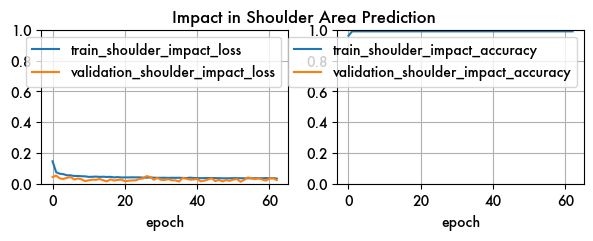

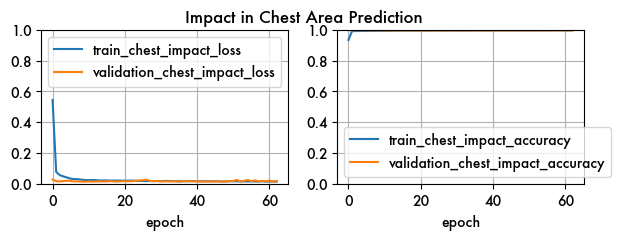

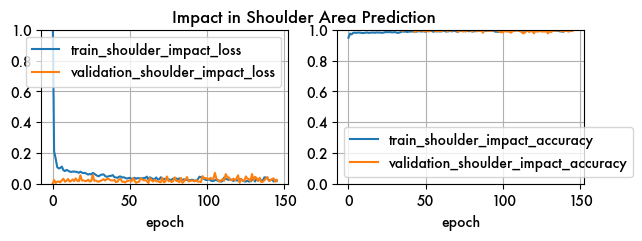

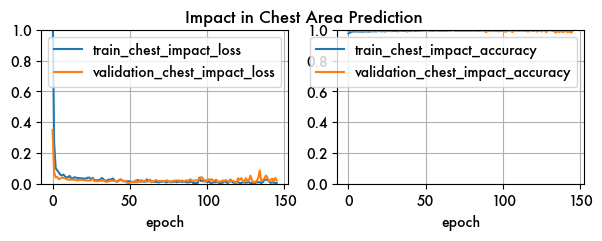

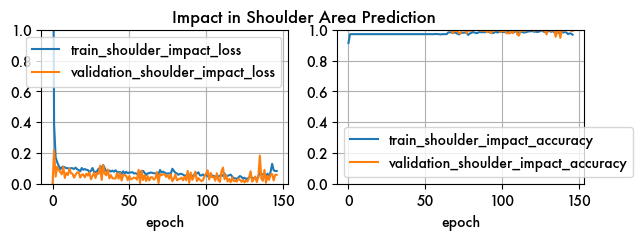

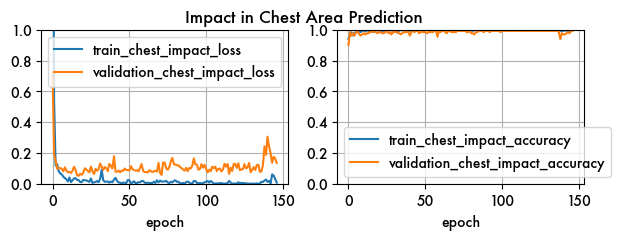

In [13]:
# Plot graphs of loss and accuracy to see the model performance
for model_impact in model_impact_list:

    # Shoulder impact area prediction
    # Train - Validation Loss graph
    fig_shoulder_branch = plt.figure(figsize=(7,2))
    fig_shoulder_branch.suptitle('Impact in Shoulder Area Prediction')
    fig_shoulder_branch.add_subplot(1,2,1)
    plt.plot(model_impact.history['shoulder_impact_loss'], label = 'train_shoulder_impact_loss')
    plt.plot(model_impact.history['val_shoulder_impact_loss'], label = 'validation_shoulder_impact_loss')
    plt.legend()
    plt.grid(True)
    plt.ylim([0,1.0])
    plt.xlabel('epoch')
    # Train - Validation Accuracy graph
    fig_shoulder_branch.add_subplot(1,2,2)
    plt.plot(model_impact.history['shoulder_impact_accuracy'], label = 'train_shoulder_impact_accuracy')
    plt.plot(model_impact.history['val_shoulder_impact_accuracy'], label = 'validation_shoulder_impact_accuracy')
    plt.legend()
    plt.grid(True)
    plt.ylim([0,1.0])
    plt.xlabel('epoch')

    # Chest impact area prediction
    # Train - Validation Loss graph
    fig_chest_branch = plt.figure(figsize=(7,2))
    fig_chest_branch.suptitle('Impact in Chest Area Prediction')
    fig_chest_branch.add_subplot(1,2,1)
    plt.plot(model_impact.history['chest_impact_loss'], label = 'train_chest_impact_loss')
    plt.plot(model_impact.history['val_chest_impact_loss'], label = 'validation_chest_impact_loss')
    plt.legend()
    plt.grid(True)
    plt.ylim([0,1.0])
    plt.xlabel('epoch')
    # Train - Validation Accuracy graph
    fig_chest_branch.add_subplot(1,2,2)
    plt.plot(model_impact.history['chest_impact_accuracy'], label = 'train_chest_impact_accuracy')
    plt.plot(model_impact.history['val_chest_impact_accuracy'], label = 'validation_chest_impact_accuracy')
    plt.legend()
    plt.grid(True)
    plt.ylim([0,1.0])
    plt.xlabel('epoch')


In [14]:
for i in range(len(model_impact_list)):
    
    # Apply the trained model to get validation and test prediction
    pretrained_model_impact = load_model(folder_path + folder_output + 'ml_cnn_impact_detection_shape_' + str(i+1) + '.h5')
    y_validation_prediction_impact = pretrained_model_impact.predict(x_validation_impact[i])
    for j in range(len(y_validation_prediction_impact)):
            y_validation_prediction_impact[j] = (y_validation_prediction_impact[j] > sigmoid_threshold).astype(int)
    y_test_prediction_impact = pretrained_model_impact.predict(x_test_impact[i])
    for k in range(len(y_test_prediction_impact)):
            y_test_prediction_impact[k] = (y_test_prediction_impact[k] > sigmoid_threshold).astype(int)

    # Evaluate model accuracy based on test data
    model_impact_test_evaluation = pretrained_model_impact.evaluate(x_test_impact[i], [y_test_shoulder_impact[i], y_test_chest_impact[i]])
    print("Test Loss:", model_impact_test_evaluation[0])
    print("Test Loss (Shoulder Impact):", model_impact_test_evaluation[1])
    print("Test Loss (Chest Impact):", model_impact_test_evaluation[2])
    print("Test Accuracy (Shoulder Impact):", model_impact_test_evaluation[3])
    print("Test Accuracy (Chest Impact):", model_impact_test_evaluation[4])
    
    # Append the result to data table
    if i == 0:
        x_validation['Shoulder Impact_1'] = y_validation_prediction_impact[0]
        x_validation['Chest Impact_1'] = y_validation_prediction_impact[1]
        x_test['Shoulder Impact_1'] = y_test_prediction_impact[0]
        x_test['Chest Impact_1'] = y_test_prediction_impact[1]
    elif i == 1: # segment of size 12
        for y_i in range(len(y_validation_prediction_impact)):
            segment_size = 12
            start = 0
            end = segment_size
            while start <= len(x_validation):
                if end < len(x_validation):
                    x_validation.loc[start:end, ['Shoulder Impact_2']] = y_validation_prediction_impact[0][y_i]
                    x_validation.loc[start:end, ['Chest Impact_2']] = y_validation_prediction_impact[1][y_i]
                else:
                    x_validation.loc[start:, ['Shoulder Impact_2']] = y_validation_prediction_impact[0][y_i]
                    x_validation.loc[start:, ['Chest Impact_2']] = y_validation_prediction_impact[1][y_i]
                start += segment_size
                end += segment_size
        for y_i in range(len(y_test_prediction_impact)):
            segment_size = 12
            start = 0
            end = segment_size
            while start <= len(x_test):
                if end < len(x_test):
                    x_test.loc[start:end, ['Shoulder Impact_2']] = y_test_prediction_impact[0][y_i]
                    x_test.loc[start:end, ['Chest Impact_2']] = y_test_prediction_impact[1][y_i]
                else:
                    x_test.loc[start:, ['Shoulder Impact_2']] = y_test_prediction_impact[0][y_i]
                    x_test.loc[start:, ['Chest Impact_2']] = y_test_prediction_impact[1][y_i]
                start += segment_size
                end += segment_size
    elif i == 2: # segment of size 24
        for y_i in range(len(y_validation_prediction_impact)):
            segment_size = 24
            start = 0
            end = segment_size
            while start <= len(x_validation):
                if end < len(x_validation):
                    x_validation.loc[start:end, ['Shoulder Impact_3']] = y_validation_prediction_impact[0][y_i]
                    x_validation.loc[start:end, ['Chest Impact_3']] = y_validation_prediction_impact[1][y_i]
                else:
                    x_validation.loc[start:, ['Shoulder Impact_3']] = y_validation_prediction_impact[0][y_i]
                    x_validation.loc[start:, ['Chest Impact_3']] = y_validation_prediction_impact[1][y_i]
                start += segment_size
                end += segment_size
        for y_i in range(len(y_test_prediction_impact)):
            segment_size = 24
            start = 0
            end = segment_size
            while start <= len(x_test):
                if end < len(x_test):
                    x_test.loc[start:end, ['Shoulder Impact_3']] = y_test_prediction_impact[0][y_i]
                    x_test.loc[start:end, ['Chest Impact_3']] = y_test_prediction_impact[1][y_i]
                else:
                    x_test.loc[start:, ['Shoulder Impact_3']] = y_test_prediction_impact[0][y_i]
                    x_test.loc[start:, ['Chest Impact_3']] = y_test_prediction_impact[1][y_i]
                start += segment_size
                end += segment_size


95/95 [==============================] - 0s 699us/step - loss: 0.0643 - shoulder_impact_loss: 0.0238 - chest_impact_loss: 0.0239 - shoulder_impact_accuracy: 0.9963 - chest_impact_accuracy: 0.9944
Test Loss: 0.06425415724515915
Test Loss (Shoulder Impact): 0.02375226467847824
Test Loss (Chest Impact): 0.023926958441734314
Test Accuracy (Shoulder Impact): 0.9963491559028625
Test Accuracy (Chest Impact): 0.9943577647209167
8/8 [==============================] - 0s 1ms/step - loss: 0.2020 - shoulder_impact_loss: 0.0768 - chest_impact_loss: 0.0700 - shoulder_impact_accuracy: 0.9883 - chest_impact_accuracy: 0.9844
Test Loss: 0.2019798308610916
Test Loss (Shoulder Impact): 0.07681624591350555
Test Loss (Chest Impact): 0.07004424929618835
Test Accuracy (Shoulder Impact): 0.98828125
Test Accuracy (Chest Impact): 0.984375
5/5 [==============================] - 0s 3ms/step - loss: 0.5149 - shoulder_impact_loss: 0.1017 - chest_impact_loss: 0.1445 - shoulder_impact_accuracy: 0.9695 - chest_impact_a

#### Machine Learning Algorithm for Detecting Falls

In [15]:
# For detecting falls
model_fall_list = []

# 1st Model (Process line by line)

input_shape = (1, num_features_fall)
input_data = Input(shape = input_shape)
model_fall = Conv1D(16, 3, activation = 'relu', padding = 'causal')(input_data)
model_fall = Conv1D(16, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = Conv1D(32, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Conv1D(32, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = Flatten()(model_fall)

fall_branch = Dense(128, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_fall)
fall_branch = Dense(64, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(fall_branch)
fall_branch = Dense(32, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(fall_branch)
fall_branch = Dense(1, activation = 'sigmoid', name="fall")(fall_branch)  # Output layer for binary classification

# Combine the defined structure into model
final_model_fall = Model(inputs = input_data, outputs = fall_branch)

# Compile model
optimizer = Adam(learning_rate = learning_rate)
final_model_fall.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
final_model_fall.summary() 

# Set up early stopping and learning rate fine tune process to stop when the model performance doesn't improve anymore 
early_stopping_callback = EarlyStopping(monitor = 'val_loss', min_delta = 0.0001, patience = 10, mode = 'min', restore_best_weights = True)
reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 10)
saved_checkpoint = ModelCheckpoint(filepath = folder_path + folder_output + 'ml_cnn_fall_detection_shape_1.h5', save_best_only = True, verbose = 2)

# Model fitting and evaluate model accuracy
model_fall = final_model_fall.fit(x_train_fall[0], y_train_fall[0], batch_size = 256, epochs = max_epoch, validation_data = (x_validation_fall[0], y_validation_fall[0]), callbacks = [early_stopping_callback, reduce_learning_rate, saved_checkpoint])
val_loss, val_accuracy = final_model_fall.evaluate(x_validation_fall[0], y_validation_fall[0])
model_fall_list.append(model_fall)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)


Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 1, 6)]            0         
                                                                 
 conv1d_15 (Conv1D)          (None, 1, 16)             304       
                                                                 
 conv1d_16 (Conv1D)          (None, 1, 16)             784       
                                                                 
 dropout_8 (Dropout)         (None, 1, 16)             0         
                                                                 
 conv1d_17 (Conv1D)          (None, 1, 32)             1568      
                                                                 
 conv1d_18 (Conv1D)          (None, 1, 32)             3104      
                                                                 
 dropout_9 (Dropout)         (None, 1, 32)             0   

Epoch 14/200
52/55 [===========================>..] - ETA: 0s - loss: 0.0422 - accuracy: 0.9854
Epoch 14: val_loss did not improve from 0.04757
55/55 [==============================] - 0s 7ms/step - loss: 0.0433 - accuracy: 0.9848 - val_loss: 0.0479 - val_accuracy: 0.9877 - lr: 0.0010
Epoch 15/200
54/55 [============================>.] - ETA: 0s - loss: 0.0421 - accuracy: 0.9849
Epoch 15: val_loss improved from 0.04757 to 0.04709, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_fall_detection_shape_1.h5
55/55 [==============================] - 0s 7ms/step - loss: 0.0422 - accuracy: 0.9848 - val_loss: 0.0471 - val_accuracy: 0.9877 - lr: 0.0010
Epoch 16/200
53/55 [===========================>..] - ETA: 0s - loss: 0.0416 - accuracy: 0.9847
Epoch 16: val_loss improved from 0.04709 to 0.04498, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/D

Epoch 36/200
55/55 [==============================] - ETA: 0s - loss: 0.0315 - accuracy: 0.9910
Epoch 36: val_loss did not improve from 0.04053
55/55 [==============================] - 0s 8ms/step - loss: 0.0315 - accuracy: 0.9910 - val_loss: 0.0415 - val_accuracy: 0.9870 - lr: 0.0010
Epoch 37/200
54/55 [============================>.] - ETA: 0s - loss: 0.0295 - accuracy: 0.9911
Epoch 37: val_loss did not improve from 0.04053
55/55 [==============================] - 1s 10ms/step - loss: 0.0296 - accuracy: 0.9910 - val_loss: 0.0452 - val_accuracy: 0.9854 - lr: 0.0010
Epoch 38/200
54/55 [============================>.] - ETA: 0s - loss: 0.0285 - accuracy: 0.9916
Epoch 38: val_loss did not improve from 0.04053
55/55 [==============================] - 1s 10ms/step - loss: 0.0284 - accuracy: 0.9916 - val_loss: 0.0438 - val_accuracy: 0.9854 - lr: 0.0010
Epoch 39/200
51/55 [==========================>...] - ETA: 0s - loss: 0.0299 - accuracy: 0.9915
Epoch 39: val_loss did not improve from 0.04

Epoch 63/200
53/55 [===========================>..] - ETA: 0s - loss: 0.0252 - accuracy: 0.9917
Epoch 63: val_loss did not improve from 0.03898
55/55 [==============================] - 0s 8ms/step - loss: 0.0253 - accuracy: 0.9918 - val_loss: 0.0421 - val_accuracy: 0.9847 - lr: 0.0010
Epoch 64/200
53/55 [===========================>..] - ETA: 0s - loss: 0.0248 - accuracy: 0.9922
Epoch 64: val_loss did not improve from 0.03898
55/55 [==============================] - 0s 8ms/step - loss: 0.0251 - accuracy: 0.9921 - val_loss: 0.0429 - val_accuracy: 0.9854 - lr: 0.0010
Epoch 65/200
54/55 [============================>.] - ETA: 0s - loss: 0.0242 - accuracy: 0.9928
Epoch 65: val_loss did not improve from 0.03898
55/55 [==============================] - 0s 8ms/step - loss: 0.0244 - accuracy: 0.9927 - val_loss: 0.0425 - val_accuracy: 0.9850 - lr: 0.0010
Epoch 66/200
55/55 [==============================] - ETA: 0s - loss: 0.0246 - accuracy: 0.9924
Epoch 66: val_loss did not improve from 0.0389

In [16]:
# 2nd Model (Process by fixed-size segment) - 12 rows

input_shape = (12, num_features_fall)
input_data = Input(shape = input_shape)
model_fall = Conv1D(16, 3, activation = 'relu', padding = 'causal')(input_data)
model_fall = Conv1D(16, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = MaxPooling1D(2, strides = 1)(model_fall)
model_fall = Conv1D(32, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Conv1D(32, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = MaxPooling1D(2, strides = 1)(model_fall)
model_fall = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = Flatten()(model_fall)

fall_branch = Dense(128, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_fall)
fall_branch = Dense(64, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(fall_branch)
fall_branch = Dense(32, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(fall_branch)
fall_branch = Dense(1, activation = 'sigmoid', name="fall")(fall_branch)  # Output layer for binary classification

# Combine the defined structure into model
final_model_fall = Model(inputs = input_data, outputs = fall_branch)

# Compile model
optimizer = Adam(learning_rate = learning_rate)
final_model_fall.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
final_model_fall.summary() 

# Set up early stopping and learning rate fine tune process to stop when the model performance doesn't improve anymore 
early_stopping_callback = EarlyStopping(monitor = 'val_loss', min_delta = 0.0001, patience = 10, mode = 'min', restore_best_weights = True)
reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 10)
saved_checkpoint = ModelCheckpoint(filepath = folder_path + folder_output + 'ml_cnn_fall_detection_shape_2.h5', save_best_only = True, verbose = 2)

# Model fitting and evaluate model accuracy
model_fall = final_model_fall.fit(x_train_fall[1], y_train_fall[1], batch_size = 64, epochs = max_epoch, validation_data = (x_validation_fall[1], y_validation_fall[1]), callbacks = [early_stopping_callback, reduce_learning_rate, saved_checkpoint])
val_loss, val_accuracy = final_model_fall.evaluate(x_validation_fall[1], y_validation_fall[1])
model_fall_list.append(model_fall)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)


Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 12, 6)]           0         
                                                                 
 conv1d_21 (Conv1D)          (None, 12, 16)            304       
                                                                 
 conv1d_22 (Conv1D)          (None, 12, 16)            784       
                                                                 
 dropout_11 (Dropout)        (None, 12, 16)            0         
                                                                 
 max_pooling1d (MaxPooling1D  (None, 11, 16)           0         
 )                                                               
                                                                 
 conv1d_23 (Conv1D)          (None, 11, 32)            1568      
                                                           

Epoch 13/200
16/19 [========================>.....] - ETA: 0s - loss: 0.1098 - accuracy: 0.9912
Epoch 13: val_loss did not improve from 0.11895
19/19 [==============================] - 0s 13ms/step - loss: 0.1067 - accuracy: 0.9923 - val_loss: 0.1206 - val_accuracy: 0.9883 - lr: 0.0010
Epoch 14/200
16/19 [========================>.....] - ETA: 0s - loss: 0.0940 - accuracy: 0.9912
Epoch 14: val_loss improved from 0.11895 to 0.10028, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_fall_detection_shape_2.h5
19/19 [==============================] - 0s 14ms/step - loss: 0.0919 - accuracy: 0.9915 - val_loss: 0.1003 - val_accuracy: 0.9883 - lr: 0.0010
Epoch 15/200
18/19 [===========================>..] - ETA: 0s - loss: 0.0800 - accuracy: 0.9939
Epoch 15: val_loss improved from 0.10028 to 0.09683, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor

19/19 [==============================] - ETA: 0s - loss: 0.0580 - accuracy: 0.9915
Epoch 36: val_loss did not improve from 0.03764
19/19 [==============================] - 0s 15ms/step - loss: 0.0580 - accuracy: 0.9915 - val_loss: 0.0700 - val_accuracy: 0.9844 - lr: 0.0010
Epoch 37/200
16/19 [========================>.....] - ETA: 0s - loss: 0.0326 - accuracy: 0.9941
Epoch 37: val_loss improved from 0.03764 to 0.03661, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_fall_detection_shape_2.h5
19/19 [==============================] - 0s 16ms/step - loss: 0.0425 - accuracy: 0.9940 - val_loss: 0.0366 - val_accuracy: 0.9883 - lr: 0.0010
Epoch 38/200
16/19 [========================>.....] - ETA: 0s - loss: 0.0266 - accuracy: 0.9951
Epoch 38: val_loss did not improve from 0.03661
19/19 [==============================] - 0s 14ms/step - loss: 0.0300 - accuracy: 0.9949 - val_loss: 0.0508 - val_accuracy: 0.984

In [17]:
# 3rd Model (Process by fixed-size segment) - 24 rows

input_shape = (24, num_features_fall)
input_data = Input(shape = input_shape)
model_fall = Conv1D(32, 3, activation = 'relu', padding = 'causal')(input_data)
model_fall = Conv1D(32, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = MaxPooling1D(2, strides = 1)(model_fall)
model_fall = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Conv1D(64, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = MaxPooling1D(2, strides = 1)(model_fall)
model_fall = Conv1D(128, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Conv1D(128, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = MaxPooling1D(2, strides = 1)(model_fall)
model_fall = Conv1D(256, 3, activation = 'relu', padding = 'causal')(model_fall)
model_fall = Dropout(0.3)(model_fall)
model_fall = MaxPooling1D(2, strides = 1)(model_fall)
model_fall = Flatten()(model_fall)

fall_branch = Dense(64, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(model_fall)
fall_branch = Dense(32, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(fall_branch)
fall_branch = Dense(16, activation = 'relu', kernel_regularizer = l2(0.01), bias_regularizer = l2(0.01))(fall_branch)
fall_branch = Dense(1, activation = 'sigmoid', name="fall")(fall_branch)  # Output layer for binary classification

# Combine the defined structure into model
final_model_fall = Model(inputs = input_data, outputs = fall_branch)

# Compile model
optimizer = Adam(learning_rate = learning_rate)
final_model_fall.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])
final_model_fall.summary() 

# Set up early stopping and learning rate fine tune process to stop when the model performance doesn't improve anymore 
early_stopping_callback = EarlyStopping(monitor = 'val_loss', min_delta = 0.0001, patience = 10, mode = 'min', restore_best_weights = True)
reduce_learning_rate = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 10)
saved_checkpoint = ModelCheckpoint(filepath = folder_path + folder_output + 'ml_cnn_fall_detection_shape_3.h5', save_best_only = True, verbose = 2)

# Model fitting and evaluate model accuracy
model_fall = final_model_fall.fit(x_train_fall[2], y_train_fall[2], batch_size = 64, epochs = max_epoch, validation_data = (x_validation_fall[2], y_validation_fall[2]), callbacks = [early_stopping_callback, reduce_learning_rate, saved_checkpoint])
val_loss, val_accuracy = final_model_fall.evaluate(x_validation_fall[2], y_validation_fall[2])
model_fall_list.append(model_fall)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)


Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 24, 6)]           0         
                                                                 
 conv1d_27 (Conv1D)          (None, 24, 32)            608       
                                                                 
 conv1d_28 (Conv1D)          (None, 24, 32)            3104      
                                                                 
 dropout_14 (Dropout)        (None, 24, 32)            0         
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 23, 32)           0         
 1D)                                                             
                                                                 
 conv1d_29 (Conv1D)          (None, 23, 64)            6208      
                                                           

10/10 [==============================] - 0s 47ms/step - loss: 0.4415 - accuracy: 0.9847 - val_loss: 0.4727 - val_accuracy: 0.9847 - lr: 0.0010
Epoch 12/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.4078 - accuracy: 0.9861
Epoch 12: val_loss did not improve from 0.47266
10/10 [==============================] - 0s 40ms/step - loss: 0.4071 - accuracy: 0.9864 - val_loss: 0.4879 - val_accuracy: 0.9847 - lr: 0.0010
Epoch 13/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.3641 - accuracy: 0.9878
Epoch 13: val_loss improved from 0.47266 to 0.40291, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_fall_detection_shape_3.h5
10/10 [==============================] - 0s 46ms/step - loss: 0.3636 - accuracy: 0.9881 - val_loss: 0.4029 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 14/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.3441 - accuracy: 0.9896
Epoch 14: val_loss i

10/10 [==============================] - 0s 41ms/step - loss: 0.1237 - accuracy: 0.9898 - val_loss: 0.1443 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 33/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.1256 - accuracy: 0.9896
Epoch 33: val_loss did not improve from 0.13700
10/10 [==============================] - 0s 47ms/step - loss: 0.1250 - accuracy: 0.9898 - val_loss: 0.1602 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 34/200
10/10 [==============================] - ETA: 0s - loss: 0.1093 - accuracy: 0.9983
Epoch 34: val_loss did not improve from 0.13700
10/10 [==============================] - 0s 50ms/step - loss: 0.1093 - accuracy: 0.9983 - val_loss: 0.1457 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 35/200
10/10 [==============================] - ETA: 0s - loss: 0.0999 - accuracy: 0.9966
Epoch 35: val_loss improved from 0.13700 to 0.11116, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cn

10/10 [==============================] - 1s 60ms/step - loss: 0.0535 - accuracy: 0.9983 - val_loss: 0.0735 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 56/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.0541 - accuracy: 0.9983
Epoch 56: val_loss improved from 0.07349 to 0.07256, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_fall_detection_shape_3.h5
10/10 [==============================] - 1s 61ms/step - loss: 0.0540 - accuracy: 0.9983 - val_loss: 0.0726 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 57/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.0491 - accuracy: 0.9983
Epoch 57: val_loss improved from 0.07256 to 0.06849, saving model to /Users/rasitapkr/Documents/MSc Data Science/Dissertation/My dissertation/Project/Demo to Donor/Data/output files/ml_cnn_fall_detection_shape_3.h5
10/10 [==============================] - 1s 53ms/step - loss: 0.0490 - accuracy: 0.9983 - va

Epoch 79/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.0268 - accuracy: 1.0000
Epoch 79: val_loss did not improve from 0.04077
10/10 [==============================] - 0s 41ms/step - loss: 0.0268 - accuracy: 1.0000 - val_loss: 0.0438 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 80/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.0260 - accuracy: 1.0000
Epoch 80: val_loss did not improve from 0.04077
10/10 [==============================] - 0s 41ms/step - loss: 0.0260 - accuracy: 1.0000 - val_loss: 0.0441 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 81/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.0254 - accuracy: 1.0000
Epoch 81: val_loss did not improve from 0.04077
10/10 [==============================] - 0s 41ms/step - loss: 0.0254 - accuracy: 1.0000 - val_loss: 0.0444 - val_accuracy: 0.9924 - lr: 0.0010
Epoch 82/200
 9/10 [==========================>...] - ETA: 0s - loss: 0.0248 - accuracy: 1.0000
Epoch 82: val_loss did not improve from 0.0

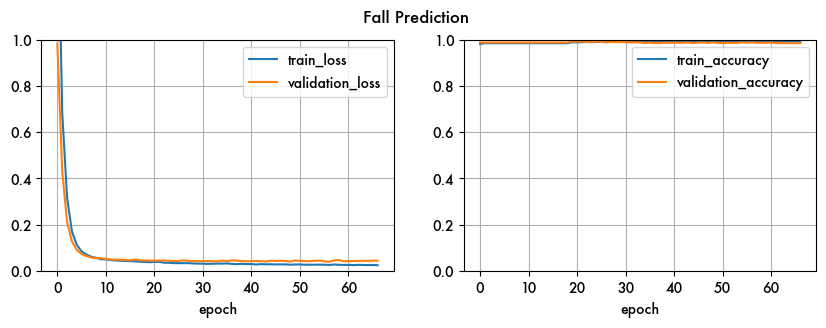

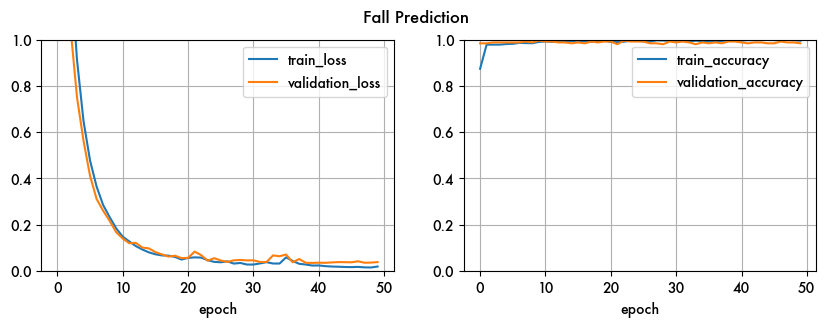

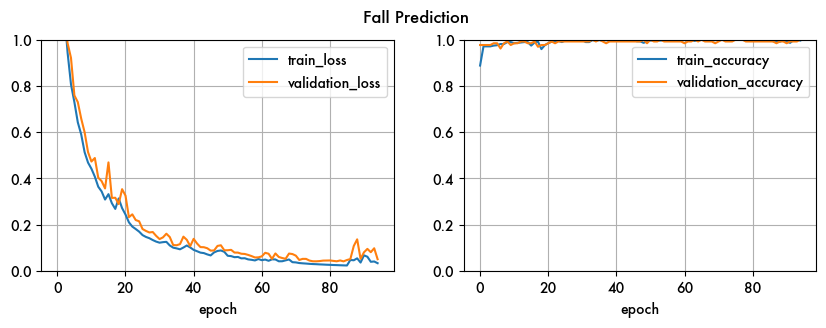

In [18]:
# Plot graphs of loss and accuracy to see the model performance
for model_fall in model_fall_list:
    
    # Train - Validation Loss graph
    fig_fall = plt.figure(figsize=(10,3))
    fig_fall.suptitle('Fall Prediction')
    fig_fall.add_subplot(1,2,1)
    plt.plot(model_fall.history['loss'], label = 'train_loss')
    plt.plot(model_fall.history['val_loss'], label = 'validation_loss')
    plt.legend()
    plt.grid(True)
    plt.ylim([0,1.0])
    plt.xlabel('epoch')
    # Train - Validation Accuracy graph
    fig_fall.add_subplot(1,2,2)
    plt.plot(model_fall.history['accuracy'], label = 'train_accuracy')
    plt.plot(model_fall.history['val_accuracy'], label = 'validation_accuracy')
    plt.legend()
    plt.grid(True)
    plt.ylim([0,1.0])
    plt.xlabel('epoch')

In [19]:
for i in range(len(model_fall_list)):
    
    # Apply the trained model to get validation and test prediction
    pretrained_model_fall = load_model(folder_path + folder_output + 'ml_cnn_fall_detection_shape_' + str(i+1) + '.h5')
    y_validation_prediction_fall = pretrained_model_fall.predict(x_validation_fall[i])
    y_validation_prediction_fall = (y_validation_prediction_fall > sigmoid_threshold).astype(int)
    y_test_prediction_fall = pretrained_model_fall.predict(x_test_fall[i])
    y_test_prediction_fall = (y_test_prediction_fall > sigmoid_threshold).astype(int)   

    # Evaluate model accuracy based on test data
    test_loss, test_accuracy = pretrained_model_fall.evaluate(x_test_fall[i], y_test_fall[i])
    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_accuracy)
    
    # Append the result to data table
    if i == 0:
        x_validation['Fall_1'] = y_validation_prediction_fall
        x_test['Fall_1'] = y_test_prediction_fall
    elif i == 1: # segment of size 12
        for y_i in range(len(y_validation_prediction_fall)):
            segment_size = 12
            start = 0
            end = segment_size
            while start <= len(x_validation):
                if end < len(x_validation):
                    x_validation.loc[start:end, ['Fall_2']] = y_validation_prediction_fall[y_i]
                else:
                    x_validation.loc[start:, ['Fall_2']] = y_validation_prediction_fall[y_i]
                start += segment_size
                end += segment_size
        for y_i in range(len(y_validation_prediction_fall)):
            segment_size = 12
            start = 0
            end = segment_size
            while start <= len(x_test):
                if end < len(x_test):
                    x_test.loc[start:end, ['Fall_2']] = y_test_prediction_fall[y_i]
                else:
                    x_test.loc[start:, ['Fall_2']] = y_test_prediction_fall[y_i]
                start += segment_size
                end += segment_size
    elif i == 2: # segment of size 24
        for y_i in range(len(y_validation_prediction_fall)):
            segment_size = 24
            start = 0
            end = segment_size
            while start <= len(x_validation):
                if end < len(x_validation):
                    x_validation.loc[start:end, ['Fall_3']] = y_validation_prediction_fall[y_i]
                else:
                    x_validation.loc[start:, ['Fall_3']] = y_validation_prediction_fall[y_i]
                start += segment_size
                end += segment_size
        for y_i in range(len(y_validation_prediction_fall)):
            segment_size = 24
            start = 0
            end = segment_size
            while start <= len(x_test):
                if end < len(x_test):
                    x_test.loc[start:end, ['Fall_3']] = y_test_prediction_fall[y_i]
                else:
                    x_test.loc[start:, ['Fall_3']] = y_test_prediction_fall[y_i]
                start += segment_size
                end += segment_size


95/95 [==============================] - 0s 995us/step - loss: 0.1668 - accuracy: 0.9678
Test Loss: 0.16676536202430725
Test Accuracy: 0.9678061604499817
8/8 [==============================] - 0s 3ms/step - loss: 0.1369 - accuracy: 0.9648
Test Loss: 0.13686956465244293
Test Accuracy: 0.96484375
5/5 [==============================] - 0s 3ms/step - loss: 0.3571 - accuracy: 0.9695
Test Loss: 0.3570828437805176
Test Accuracy: 0.9694656729698181


#### Perform majority voting and calculate final accuracy

In [20]:
# Majority voting to find the final validation and test accuracy

# Validation
# Impacts
x_validation['Predicted Shoulder Impact'] = x_validation['Shoulder Impact_1'] + x_validation['Shoulder Impact_2'] + x_validation['Shoulder Impact_3']
x_validation['Predicted Shoulder Impact'] = (x_validation['Predicted Shoulder Impact'] >= 2) # Check if True
x_validation['Predicted Shoulder Impact'] = x_validation['Predicted Shoulder Impact'].astype(int)
x_validation['Predicted Chest Impact'] = x_validation['Chest Impact_1'] + x_validation['Chest Impact_2'] + x_validation['Chest Impact_3']
x_validation['Predicted Chest Impact'] = (x_validation['Predicted Chest Impact'] >= 2) # Check if True
x_validation['Predicted Chest Impact'] = x_validation['Predicted Chest Impact'].astype(int)
x_validation['Predicted Impact'] = (x_validation['Predicted Shoulder Impact'] == 1) | (x_validation['Predicted Chest Impact'] == 1) # Check if True
x_validation['Predicted Impact'] = x_validation['Predicted Impact'].astype(int) # 1 when True
# Falls
x_validation['Predicted Fall'] = x_validation['Fall_1'] + x_validation['Fall_2'] + x_validation['Fall_3']
x_validation['Predicted Fall'] = (x_validation['Predicted Fall'] >= 2) # Check if True
x_validation['Predicted Fall'] = x_validation['Predicted Fall'].astype(int)
# Calculate accuracy
# Impacts
correct_predicted_rows_impact = (x_validation['Impact'] == x_validation['Predicted Impact']).sum()
accuracy_percentage_impact = (correct_predicted_rows_impact / len(x_validation)) * 100
correct_predicted_rows_shoulder_impact = (x_validation['Shoulder Impact'] == x_validation['Predicted Shoulder Impact']).sum()
accuracy_percentage_shoulder_impact = (correct_predicted_rows_shoulder_impact / len(x_validation)) * 100
correct_predicted_rows_chest_impact = (x_validation['Chest Impact'] == x_validation['Predicted Chest Impact']).sum()
accuracy_percentage_chest_impact = (correct_predicted_rows_chest_impact / len(x_validation)) * 100
# Falls
correct_predicted_rows_fall = (x_validation['Fall'] == x_validation['Predicted Fall']).sum()
accuracy_percentage_fall = (correct_predicted_rows_fall / len(x_validation)) * 100

print("Validation Accuracy")
print("Impact:", accuracy_percentage_impact)
print("Shoulder Impact:", accuracy_percentage_shoulder_impact)
print("Chest Impact:", accuracy_percentage_chest_impact)
print("Fall:", accuracy_percentage_fall)

# Test
# Impacts
x_test['Predicted Shoulder Impact'] = x_test['Shoulder Impact_1'] + x_test['Shoulder Impact_2'] + x_test['Shoulder Impact_3']
x_test['Predicted Shoulder Impact'] = (x_test['Predicted Shoulder Impact'] >= 2) # Check if True
x_test['Predicted Shoulder Impact'] = x_test['Predicted Shoulder Impact'].astype(int)
x_test['Predicted Chest Impact'] = x_test['Chest Impact_1'] + x_test['Chest Impact_2'] + x_test['Chest Impact_3']
x_test['Predicted Chest Impact'] = (x_test['Predicted Chest Impact'] >= 2) # Check if True
x_test['Predicted Chest Impact'] = x_test['Predicted Chest Impact'].astype(int)
x_test['Predicted Impact'] = (x_test['Predicted Shoulder Impact'] == 1) | (x_test['Predicted Chest Impact'] == 1) # Check if True
x_test['Predicted Impact'] = x_test['Predicted Impact'].astype(int) # 1 when True
# Falls
x_test['Predicted Fall'] = x_test['Fall_1'] + x_test['Fall_2'] + x_test['Fall_3']
x_test['Predicted Fall'] = (x_test['Predicted Fall'] >= 2) # Check if True
x_test['Predicted Fall'] = x_test['Predicted Fall'].astype(int)
# Calculate accuracy
# Impacts
correct_predicted_rows_impact = (x_test['Impact'] == x_test['Predicted Impact']).sum()
accuracy_percentage_impact = (correct_predicted_rows_impact / len(x_test)) * 100
correct_predicted_rows_shoulder_impact = (x_test['Shoulder Impact'] == x_test['Predicted Shoulder Impact']).sum()
accuracy_percentage_shoulder_impact = (correct_predicted_rows_shoulder_impact / len(x_test)) * 100
correct_predicted_rows_chest_impact = (x_test['Chest Impact'] == x_test['Predicted Chest Impact']).sum()
accuracy_percentage_chest_impact = (correct_predicted_rows_chest_impact / len(x_test)) * 100
# Falls
correct_predicted_rows_fall = (x_test['Fall'] == x_test['Predicted Fall']).sum()
accuracy_percentage_fall = (correct_predicted_rows_fall / len(x_test)) * 100

print("Test Accuracy")
print("Impact:", accuracy_percentage_impact)
print("Shoulder Impact:", accuracy_percentage_shoulder_impact)
print("Chest Impact:", accuracy_percentage_chest_impact)
print("Fall:", accuracy_percentage_fall)

Validation Accuracy
Impact: 99.70069837046891
Shoulder Impact: 100.0
Chest Impact: 99.70069837046891
Fall: 98.76953774526106
Test Accuracy
Impact: 99.4025887819449
Shoulder Impact: 99.63491536674411
Chest Impact: 99.4025887819449
Fall: 96.18320610687023


#### Please continue in part 2 file (Code_2_Production.ipynb).